# Data - Preprocessing


## Load Dataset

In [8]:
import numpy as np
import pandas as pd

In [10]:
dataset = pd.read_excel('SKILICARSLAN_Anemia_DataSet.xlsx')
dataset

,GENDER,WBC,NE#,LY#,MO#,EO#,BA#,RBC,HGB,HCT,...,SDTSD,TSD,FERRITTE,FOLATE,B12,All_Class,HGB_Anemia_Class,Iron_anemia_Class,Folate_anemia_class,B12_Anemia_class
0,1,10.63,6.31,2.79,0.91,0.56,0.06,4.31,12.7,37.6,...,248.90,40.176778,194.00,5.06,178.2,4,0,0,0,1
1,1,5.08,2.50,1.87,0.43,0.26,0.02,4.34,12.8,36.9,...,348.48,33.482553,57.37,9.88,197.7,4,0,0,0,1
2,1,13.68,9.40,2.69,1.55,0.03,0.01,3.18,9.4,27.5,...,357.27,20.144429,114.20,8.37,143.0,4,0,0,0,1
3,1,5.60,3.94,0.83,0.54,0.26,0.03,3.35,10.5,31.4,...,360.60,27.731559,214.20,6.39,139.9,4,0,0,0,1
4,1,3.57,2.03,1.25,0.10,0.18,0.01,1.31,5.1,14.3,...,223.28,78.860623,303.40,4.30,50.0,4,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15295,0,11.99,10.21,1.14,0.62,0.00,0.02,3.58,12.0,35.2,...,300.90,43.203722,45.91,7.58,147.1,0,0,0,0,0
15296,0,9.14,5.38,2.74,0.79,0.18,0.05,4.77,13.1,39.9,...,391.30,23.153591,69.95,5.43,318.6,0,0,0,0,0
15297,0,5.91,2.96,2.09,0.57,0.23,0.06,4.95,13.7,41.2,...,428.53,23.762630,21.38,19.53,390.1,0,0,0,0,0
15298,0,7.65,3.77,3.26,0.45,0.15,0.02,4.48,12.1,38.8,...,391.22,11.609836,30.50,16.18,330.8,0,0,0,0,0


In [143]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15300 entries, 0 to 15299
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GENDER               15300 non-null  int64  
 1   WBC                  15300 non-null  float64
 2   NE#                  15300 non-null  float64
 3   LY#                  15300 non-null  float64
 4   MO#                  15300 non-null  float64
 5   EO#                  15300 non-null  float64
 6   BA#                  15300 non-null  float64
 7   RBC                  15300 non-null  float64
 8   HGB                  15300 non-null  float64
 9   HCT                  15300 non-null  float64
 10  MCV                  15300 non-null  float64
 11  MCH                  15300 non-null  float64
 12  MCHC                 15300 non-null  float64
 13  RDW                  15300 non-null  float64
 14  PLT                  15300 non-null  float64
 15  MPV                  15300 non-null 

## Detect missing values + Data Cleaning + Check Anemia_Class

In [5]:
#detect missing values
df = pd.read_excel('SKILICARSLAN_Anemia_DataSet.xlsx')
if isinstance(df, dict):  # Handle multiple sheets
    sheet_names = df.keys()
    print(f"Available sheets: {sheet_names}")  # Output available sheets
    df = df[list(sheet_names)[0]]  # Default to the first sheet for now

# Recheck missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Create a DataFrame for the report
missing_report = pd.DataFrame({
    'Missing Values Count': missing_values,
    '% of Total Values': missing_percentage
}).sort_values(by='Missing Values Count', ascending=False)

# Filter to show only columns with missing values
missing_report = missing_report[missing_report['Missing Values Count'] > 0]

# Output the report
print(missing_report)
print(df.isnull().sum())  # Check missing values


Empty DataFrame
Columns: [Missing Values Count, % of Total Values]
Index: []
GENDER                 0
WBC                    0
NE#                    0
LY#                    0
MO#                    0
EO#                    0
BA#                    0
RBC                    0
HGB                    0
HCT                    0
MCV                    0
MCH                    0
MCHC                   0
RDW                    0
PLT                    0
MPV                    0
PCT                    0
PDW                    0
SD                     0
SDTSD                  0
TSD                    0
FERRITTE               0
FOLATE                 0
B12                    0
All_Class              0
HGB_Anemia_Class       0
Iron_anemia_Class      0
Folate_anemia_class    0
B12_Anemia_class       0
dtype: int64


In [8]:
#Data cleaning
# Print the number of unique values in each column
for i, column in enumerate(dataset.columns):
    print(f"Column {i} ({column}): {dataset[column].nunique()} unique values")

Column 0 (GENDER): 2 unique values
Column 1 (WBC): 1736 unique values
Column 2 (NE#): 1564 unique values
Column 3 (LY#): 848 unique values
Column 4 (MO#): 987 unique values
Column 5 (EO#): 723 unique values
Column 6 (BA#): 374 unique values
Column 7 (RBC): 675 unique values
Column 8 (HGB): 1226 unique values
Column 9 (HCT): 2513 unique values
Column 10 (MCV): 3015 unique values
Column 11 (MCH): 1648 unique values
Column 12 (MCHC): 1033 unique values
Column 13 (RDW): 1051 unique values
Column 14 (PLT): 3444 unique values
Column 15 (MPV): 1087 unique values
Column 16 (PCT): 538 unique values
Column 17 (PDW): 817 unique values
Column 18 (SD): 5499 unique values
Column 19 (SDTSD): 7741 unique values
Column 20 (TSD): 12551 unique values
Column 21 (FERRITTE): 7573 unique values
Column 22 (FOLATE): 1630 unique values
Column 23 (B12): 5308 unique values
Column 24 (All_Class): 5 unique values
Column 25 (HGB_Anemia_Class): 2 unique values
Column 26 (Iron_anemia_Class): 2 unique values
Column 27 

In [16]:
# Check class distribution in 'Decision_Class'
class_distribution = dataset['B12_Anemia_class'].value_counts()
class_distribution

B12_Anemia_class
0    15101
1      199
Name: count, dtype: int64

## Preprocessing

In [11]:
#Import Librabries
import matplotlib.pyplot as plt
from pandas import read_excel
# load the dataset
def load_dataset(filename):
    dataset = read_excel(filename)
    X = dataset.drop(columns=['All_Class', 'HGB_Anemia_Class', 'Iron_anemia_Class', 'Folate_anemia_class', 'B12_Anemia_class'])
    y = dataset['B12_Anemia_class']
    return X, y
# load the dataset
X, y = load_dataset('SKILICARSLAN_Anemia_DataSet.xlsx')
print(dataset.columns)


Index(['GENDER', 'WBC', 'NE#', 'LY#', 'MO#', 'EO#', 'BA#', 'RBC', 'HGB', 'HCT',
       'MCV', 'MCH', 'MCHC', 'RDW', 'PLT', 'MPV', 'PCT', 'PDW', 'SD', 'SDTSD',
       'TSD', 'FERRITTE', 'FOLATE', 'B12', 'All_Class', 'HGB_Anemia_Class',
       'Iron_anemia_Class', 'Folate_anemia_class', 'B12_Anemia_class'],
      dtype='object')


In [12]:
# split into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [13]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (12240, 24)
X_test shape: (3060, 24)
y_train shape: (12240,)
y_test shape: (3060,)


In [14]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

def prepare_inputs(X_train, X_test):
    # Apply OneHotEncoder to the first column (Gender)
    ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(sparse_output=False), [0])], remainder='passthrough')
    # Fit on the training data and transform both training and test sets
    X_train_enc = np.array(ct.fit_transform(X_train),dtype = float)
    X_test_enc = np.array(ct.transform(X_test), dtype = float)
    return X_train_enc, X_test_enc
# prepare input data
X_train_enc, X_test_enc = prepare_inputs(X_train, X_test)

In [10]:
dataset = pd.DataFrame(X_train_enc)
dataset

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,1.0,0.0,6.56,3.35,2.71,0.400,0.050,0.050,5.08,14.54,...,192.9,11.17,0.220,21.23,79.89,363.49,21.978596,11.10,14.40,282.90
1,1.0,0.0,9.78,5.13,3.73,0.720,0.120,0.090,5.27,14.96,...,213.3,11.18,0.240,20.50,146.00,397.00,36.775819,60.31,9.30,244.00
2,1.0,0.0,8.07,3.79,3.46,0.320,0.480,0.020,4.26,11.10,...,343.0,9.30,0.320,9.90,32.00,391.10,8.182051,13.22,7.46,365.50
3,1.0,0.0,10.77,8.00,1.55,0.960,0.190,0.070,4.76,13.93,...,196.3,8.50,0.170,20.14,59.00,409.00,14.425428,7.39,6.90,331.50
4,1.0,0.0,6.16,3.10,2.60,0.310,0.060,0.080,5.02,13.96,...,373.5,7.96,0.300,19.04,95.81,394.91,24.261224,26.50,6.57,334.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12235,0.0,1.0,5.12,2.66,1.84,0.410,0.140,0.060,4.72,11.96,...,220.2,7.34,0.160,21.47,44.00,383.00,11.488251,13.05,19.24,66.54
12236,1.0,0.0,8.57,5.56,2.25,0.560,0.160,0.040,5.61,11.66,...,160.0,13.42,0.210,22.37,77.13,349.53,22.066775,134.30,6.97,566.50
12237,1.0,0.0,8.49,5.10,2.66,0.490,0.140,0.090,5.25,14.65,...,338.2,6.74,0.230,18.79,47.00,365.10,12.873185,24.31,7.19,202.70
12238,0.0,1.0,7.19,4.70,1.58,0.690,0.140,0.070,3.61,10.52,...,257.3,7.50,0.190,20.34,71.58,245.08,29.206790,94.59,3.01,557.50


In [20]:
from sklearn.preprocessing import LabelEncoder

def prepare_targets(y_train, y_test):
    le = LabelEncoder()
    le.fit(y_train)  # Fit only once on training data
    y_train_enc = le.transform(y_train)
    y_test_enc = le.transform(y_test)
    return y_train_enc, y_test_enc
# prepare output data
y_train_enc, y_test_enc = prepare_targets(y_train, y_test)


In [22]:
from sklearn.preprocessing import StandardScaler
import numpy as np

def Scale_Numerical_Features(X_train_enc, X_test_enc, num_cat_features=2):
    scaler = StandardScaler()
    X_train_category = X_train_enc[:, :num_cat_features]  # Adjust for actual number of categorical columns
    X_train_numeric = X_train_enc[:, num_cat_features:]  # Everything else is numerical
    # scale numerical features only
    X_train_numeric_scaled = scaler.fit_transform(X_train_numeric)

    #Combine categorical and scaled numerical features
    X_train_scaled = np.hstack((X_train_category, X_train_numeric_scaled))

    #Repeat for test set (Use same scaler)
    X_test_category = X_test_enc[:, :num_cat_features]
    X_test_numeric = X_test_enc[:, num_cat_features:]

    X_test_numeric_scaled = scaler.transform(X_test_numeric)  # Use same scaler
    X_test_scaled = np.hstack((X_test_category, X_test_numeric_scaled))

    return X_train_scaled, X_test_scaled, scaler

#Apply Scaling
X_train_scaled, X_test_scaled, scaler = Scale_Numerical_Features(X_train_enc, X_test_enc, num_cat_features=2)


In [24]:
print('X_train_scaled shape:', X_train_scaled.shape)
print('X_test_scaled shape:', X_test_scaled.shape)

X_train_scaled shape: (12240, 25)
X_test_scaled shape: (3060, 25)


In [63]:
#Smote Standard
from imblearn.over_sampling import SMOTE
# Apply SMOTE on the scaled training data
smote_standard = SMOTE(random_state = 42)
X_train_resampled, y_train_resampled = smote_standard.fit_resample(X_train_scaled, y_train_enc)
#Check the shapes of resampled data
print("Original training set shape:", X_train_scaled.shape, y_train_enc.shape)
print("Resampled training set shape:", X_train_resampled.shape, y_train_resampled.shape)
# Check the new class distribution
from collections import Counter
print("Before SMOTE:", Counter(y_train_enc))  # Check original class distribution
print("After SMOTE:", Counter(y_train_resampled))  # Check resampled class distribution

Original training set shape: (12240, 25) (12240,)
Resampled training set shape: (24152, 25) (24152,)
Before SMOTE: Counter({0: 12076, 1: 164})
After SMOTE: Counter({0: 12076, 1: 12076})


C:\Users\HungPhatPC\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [26]:
# Apply SMOTE-Tomek

from imblearn.combine import SMOTETomek
from collections import Counter

smote_tomek = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

# Check the shape of resampled data
print("Original training set shape:", X_train_scaled.shape, y_train_enc.shape)
print("Resampled training set shape:", X_train_resampled.shape, y_train_resampled.shape)

# Check the new class distribution
print("Before SMOTE-Tomek:", Counter(y_train_enc))  
print("After SMOTE-Tomek:", Counter(y_train_resampled))  


C:\Users\HungPhatPC\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Original training set shape: (12240, 25) (12240,)
Resampled training set shape: (24152, 25) (24152,)
Before SMOTE-Tomek: Counter({0: 12076, 1: 164})
After SMOTE-Tomek: Counter({0: 12076, 1: 12076})


Class 0 (no B12 anemia): 98.70%
Class 1 (B12 anemia): 1.30%


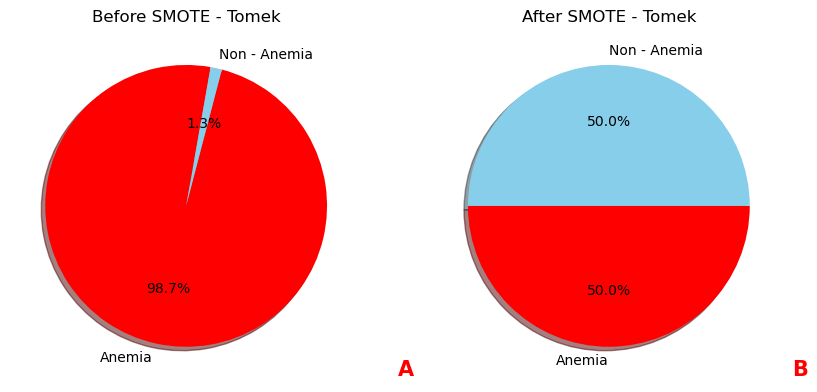

In [2]:
import matplotlib.pyplot as plt
total = 15101 + 199

pct_class_0 = (15101 / total) * 100
pct_class_1 = (199 / total) * 100

print(f"Class 0 (no B12 anemia): {pct_class_0:.2f}%")
print(f"Class 1 (B12 anemia): {pct_class_1:.2f}%")
# Data before SMOTE (A)
labels_A = ['Anemia', 'Non - Anemia']
sizes_A = [98.7, 1.3]  # Imbalanced percentages
colors_A = ['red', 'skyblue']

# Data after SMOTE (B)
labels_B = ['Anemia', 'Non - Anemia']
sizes_B = [50.0, 50.0]  # Balanced after SMOTE
colors_B = ['red', 'skyblue']

# Create figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Pie Chart A (Before SMOTE)
axes[0].pie(sizes_A, labels=labels_A, autopct='%1.1f%%', colors=colors_A, shadow=True, startangle=80)
axes[0].set_title("Before SMOTE - Tomek")

# Pie Chart B (After SMOTE)
axes[1].pie(sizes_B, labels=labels_B, autopct='%1.1f%%', colors=colors_B, shadow=True, startangle=180)
axes[1].set_title("After SMOTE - Tomek")

# Add labels
plt.text(-1.5, -1.2, "A", fontsize=15, color='red', fontweight='bold')
plt.text(1.3, -1.2, "B", fontsize=15, color='red', fontweight='bold')

# Display the charts
plt.show()


In [28]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import numpy as np
import matplotlib.pyplot as plt

def select_features(X_train, y_train, X_test, k='all'):
    fs = SelectKBest(score_func=mutual_info_classif, k=k)  
    fs.fit(X_train, y_train)
    X_train_fs = fs.transform(X_train)
    X_test_fs = fs.transform(X_test)
    return X_train_fs, X_test_fs, fs

#output
X_train_fs, X_test_fs, fs = select_features(X_train_resampled, y_train_resampled, X_test_scaled)

#what are scores for the features
for i, score in enumerate(fs.scores_):
    print(f"Feature {i}: Score={score:.3f}")



Feature 0: Score=0.114
Feature 1: Score=0.113
Feature 2: Score=0.421
Feature 3: Score=0.449
Feature 4: Score=0.539
Feature 5: Score=0.484
Feature 6: Score=0.520
Feature 7: Score=0.475
Feature 8: Score=0.553
Feature 9: Score=0.531
Feature 10: Score=0.425
Feature 11: Score=0.305
Feature 12: Score=0.451
Feature 13: Score=0.499
Feature 14: Score=0.464
Feature 15: Score=0.255
Feature 16: Score=0.473
Feature 17: Score=0.522
Feature 18: Score=0.507
Feature 19: Score=0.256
Feature 20: Score=0.168
Feature 21: Score=0.284
Feature 22: Score=0.164
Feature 23: Score=0.445
Feature 24: Score=0.521


In [30]:
feature_scores = mutual_info_classif(X_train_fs, y_train_resampled)
import numpy as np
sorted_indices = np.argsort(feature_scores)[::-1]  # Sort features by importance
print(" - Feature Importance Ranking:")
for i in sorted_indices:
    print(f"+ Feature {i}: Importance = {feature_scores[i]:.3f}")

 - Feature Importance Ranking:
+ Feature 8: Importance = 0.552
+ Feature 4: Importance = 0.539
+ Feature 9: Importance = 0.530
+ Feature 17: Importance = 0.524
+ Feature 24: Importance = 0.521
+ Feature 6: Importance = 0.517
+ Feature 18: Importance = 0.507
+ Feature 13: Importance = 0.500
+ Feature 5: Importance = 0.483
+ Feature 16: Importance = 0.473
+ Feature 7: Importance = 0.473
+ Feature 14: Importance = 0.464
+ Feature 12: Importance = 0.451
+ Feature 3: Importance = 0.450
+ Feature 23: Importance = 0.446
+ Feature 10: Importance = 0.426
+ Feature 2: Importance = 0.421
+ Feature 11: Importance = 0.305
+ Feature 21: Importance = 0.284
+ Feature 19: Importance = 0.256
+ Feature 15: Importance = 0.254
+ Feature 20: Importance = 0.169
+ Feature 22: Importance = 0.164
+ Feature 0: Importance = 0.117
+ Feature 1: Importance = 0.116


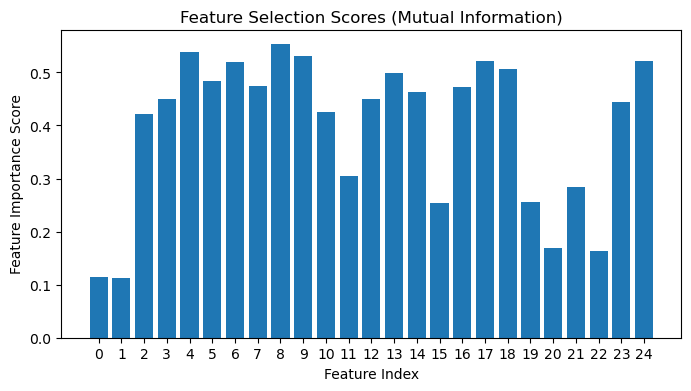

In [31]:
# Plot feature importance
plt.figure(figsize=(8, 4))
plt.bar(range(len(fs.scores_)), fs.scores_)
plt.xticks(range(len(fs.scores_)), labels=range(len(fs.scores_)))
plt.xlabel("Feature Index")
plt.ylabel("Feature Importance Score")
plt.title("Feature Selection Scores (Mutual Information)")
plt.show()


In [34]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.preprocessing import Binarizer

# 1. Binarize the continuous features
binarizer = Binarizer(threshold=0)  # Set threshold (e.g., 0 or median value)
X_train_bin = binarizer.fit_transform(X_train_fs)

# 2. Convert to DataFrame for mlxtend
# You need feature names, let's assume you have them in a list called "feature_names"
feature_names = [f'Feature_{i}' for i in range(X_train_fs.shape[1])]
X_train_df = pd.DataFrame(X_train_bin, columns=feature_names)

# 3. Apply Apriori algorithm to find frequent itemsets
frequent_itemsets = apriori(X_train_df, min_support=0.2, use_colnames=True)

# 4. Generate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

# 5. Display results
print("Frequent Itemsets:")
print(frequent_itemsets)

print("\nAssociation Rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


C:\Users\HungPhatPC\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Frequent Itemsets:
      support                                           itemsets
0    0.680979                                        (Feature_0)
1    0.458968                                        (Feature_1)
2    0.368955                                        (Feature_2)
3    0.359018                                        (Feature_3)
4    0.345561                                        (Feature_4)
..        ...                                                ...
281  0.334010  (Feature_21, Feature_11, Feature_12, Feature_1...
282  0.222839  (Feature_21, Feature_11, Feature_12, Feature_1...
283  0.260061  (Feature_21, Feature_11, Feature_12, Feature_1...
284  0.204331  (Feature_21, Feature_12, Feature_19, Feature_1...
285  0.223750  (Feature_21, Feature_11, Feature_12, Feature_1...

[286 rows x 2 columns]

Association Rules:
                             antecedents  \
0                            (Feature_2)   
1                            (Feature_3)   
2                        

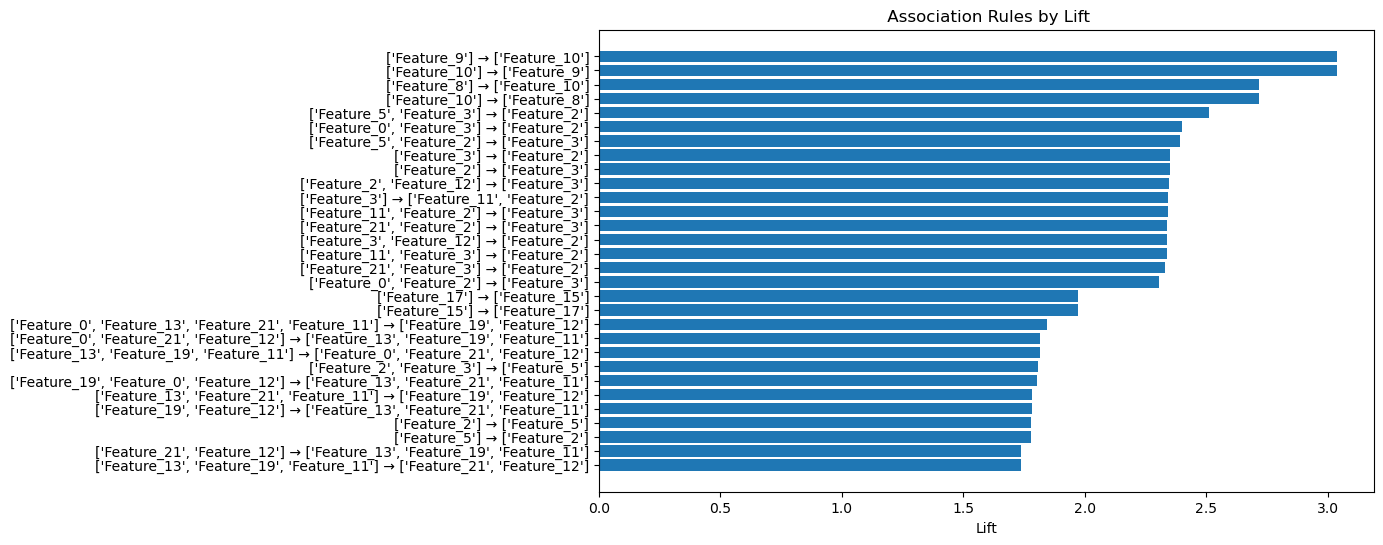

In [99]:
import matplotlib.pyplot as plt

# Sort by Lift
top_rules = rules.sort_values('lift', ascending=False).head(30)

# Plot
plt.figure(figsize=(10,6))
plt.barh(range(len(top_rules)), top_rules['lift'], align='center')
plt.yticks(range(len(top_rules)), [f"{list(a)} → {list(c)}" for a, c in zip(top_rules['antecedents'], top_rules['consequents'])])
plt.xlabel('Lift')
plt.title(' Association Rules by Lift')
plt.gca().invert_yaxis()
plt.show()


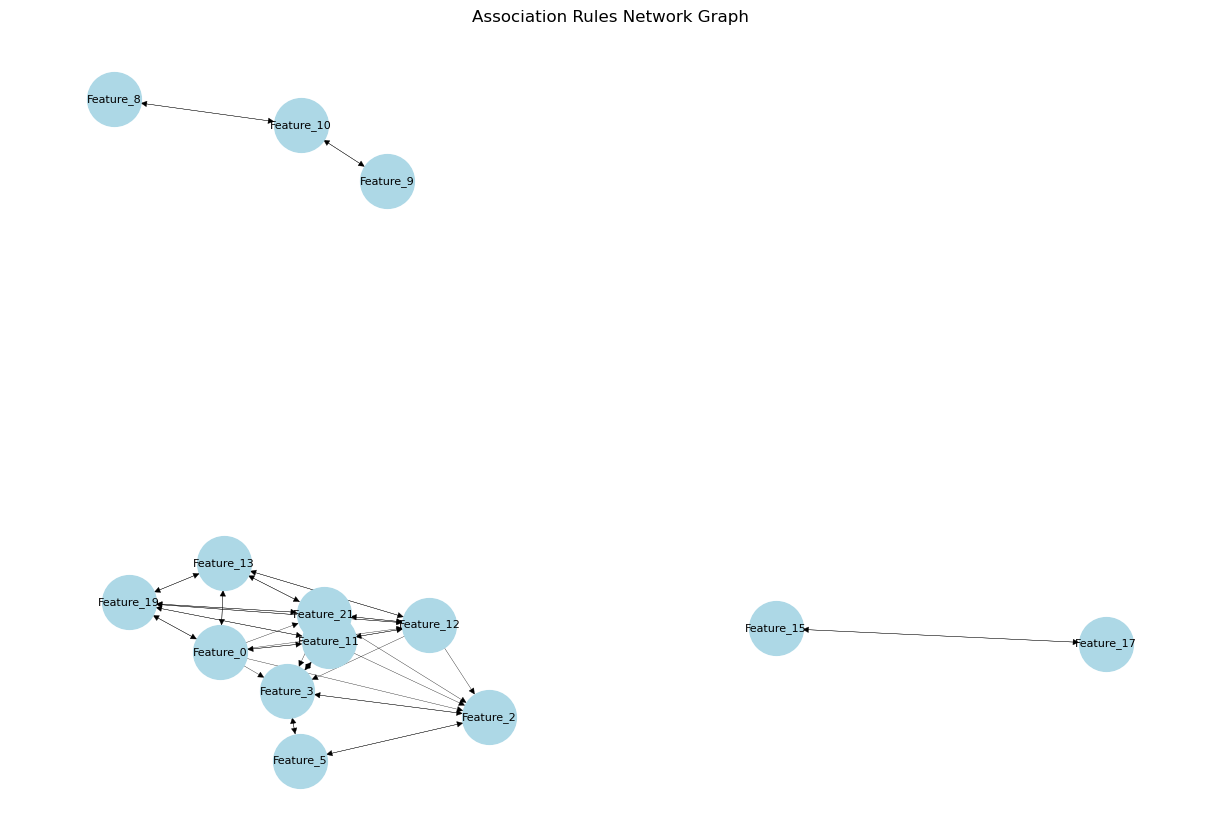

In [91]:
import networkx as nx

# Create Graph
G = nx.DiGraph()

# Add edges
for idx, row in top_rules.iterrows():
    for antecedent in row['antecedents']:
        for consequent in row['consequents']:
            G.add_edge(antecedent, consequent, weight=row['lift'])

# Draw graph
plt.figure(figsize=(12,8))
pos = nx.spring_layout(G, k=0.5)
nx.draw(G, pos, with_labels=True, node_size=1500, node_color="lightblue", font_size=8, width=0.25, arrows=True)
plt.title('Association Rules Network Graph')
plt.show()


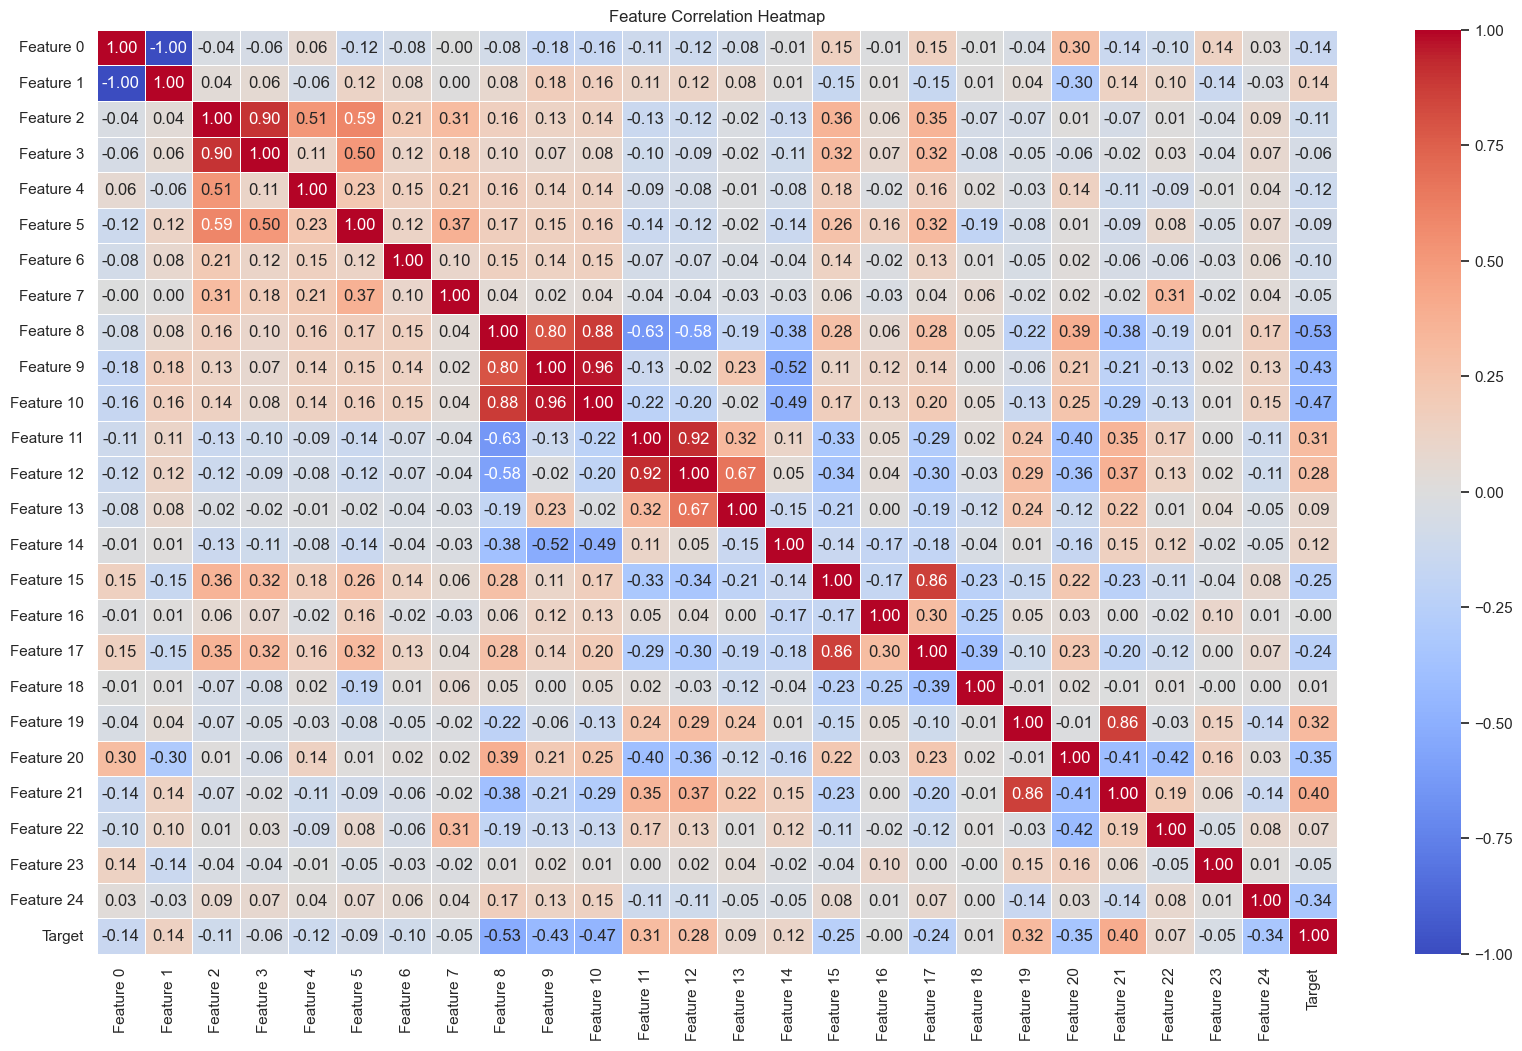

In [76]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert features into a DataFrame (if it's not already)
df_features = pd.DataFrame(X_train_fs, columns=[f"Feature {i}" for i in range(X_train_fs.shape[1])])
df_features['Target'] = y_train_resampled  # Add the target variable

# Compute correlation matrix
correlation_matrix = df_features.corr()

# Plot correlation heatmap
plt.figure(figsize=(20, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()


# Imbalanced Dataset

In [52]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from collections import Counter
import pandas as pd

# Simulating original class distribution
class_distribution = {"- Imbalanced Data": Counter({1: 12076 , 0: 164})}

# ✅ 1. SMOTE - Standard
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_enc)

# ✅ 2. SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

# ✅ 3. SMOTE-ENN
smote_enn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smote_enn.fit_resample(X_train_scaled, y_train_enc)

# ✅ 4. ADASYN
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train_enc)

# Update class distribution
class_distribution["+ SMOTE"] = Counter(y_train_smote)
class_distribution["+ SMOTE-Tomek"] = Counter(y_train_tomek)
class_distribution["+ SMOTE-ENN"] = Counter(y_train_smoteenn)
class_distribution["+ ADASYN"] = Counter(y_train_adasyn)

# Visualize class distributions
df_class_dist = pd.DataFrame.from_dict(class_distribution, orient='index')
df_class_dist.columns = ['Class 0', 'Class 1']
print("Class distribution before and after resampling techniques:")
print(df_class_dist)

# Evaluation Function
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return accuracy, auc, precision, recall, f1

# ✅ Model Training & Evaluation
xgb_results = []
resampled_sets = {
    "+ SMOTE - Standard": (X_train_smote, y_train_smote),
    "+ SMOTE-Tomek": (X_train_tomek, y_train_tomek),
    "+ SMOTE-ENN": (X_train_smoteenn, y_train_smoteenn),
    "+ ADASYN": (X_train_adasyn, y_train_adasyn)
}

for technique, (X_res, y_res) in resampled_sets.items():
    counter = Counter(y_res)
    scale_pos_weight = counter[0] / counter[1]
    
    model = XGBClassifier(
        objective='binary:logistic',
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=0
    )
    
    model.fit(X_res, y_res)
    
    acc, auc, precision, recall, f1 = evaluate_model(model, X_test_scaled, y_test_enc)
    xgb_results.append([technique, acc, auc, precision, recall, f1])

# ✅ Results
xgb_results_df = pd.DataFrame(xgb_results, columns=["Technique", "Accuracy", "AUC", "Precision", "Recall", "F1-Score"])
print("\n✅ Final Results for XGBoost with SMOTE and ADASYN techniques:")
print(xgb_results_df.to_string(index=False))


C:\Users\HungPhatPC\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\sklearn\base.py:474

Class distribution before and after resampling techniques:
                   Class 0  Class 1
- Imbalanced Data    12076      164
+ SMOTE              12076    12076
+ SMOTE-Tomek        12076    12076
+ SMOTE-ENN          12076    11237
+ ADASYN             12101    12076


C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:51:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:51:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:51:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:51:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not use


✅ Final Results for XGBoost with SMOTE and ADASYN techniques:
         Technique  Accuracy      AUC  Precision  Recall  F1-Score
+ SMOTE - Standard  0.999673 0.999991   0.972222     1.0  0.985915
     + SMOTE-Tomek  0.999673 0.999991   0.972222     1.0  0.985915
       + SMOTE-ENN  0.999346 0.999972   0.945946     1.0  0.972222
          + ADASYN  0.999673 0.999991   0.972222     1.0  0.985915


## Imbalanced LR

In [160]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from collections import Counter
import pandas as pd

# Simulating original class distribution
class_distribution = {"- Imbalanced Data": Counter({1: 12076 , 0: 164})}

# ✅ 1. SMOTE - Standard
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_enc)

# ✅ 2. SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

# ✅ 3. SMOTE-ENN
smote_enn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smote_enn.fit_resample(X_train_scaled, y_train_enc)

# ✅ 4. ADASYN (standalone)
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train_enc)

# Update class distribution
class_distribution["+ SMOTE"] = Counter(y_train_smote)
class_distribution["+ SMOTE-Tomek"] = Counter(y_train_tomek)
class_distribution["+ SMOTE-ENN"] = Counter(y_train_smoteenn)
class_distribution["+ ADASYN"] = Counter(y_train_adasyn)

# Visualize class distributions
df_class_dist = pd.DataFrame.from_dict(class_distribution, orient='index')
df_class_dist.columns = ['Class 0', 'Class 1']
print("Class distribution before and after resampling techniques:")
print(df_class_dist)

# Evaluation Function
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return accuracy, auc, precision, recall, f1

# Model Training & Evaluation
results = []
resampled_sets = {
    "+ SMOTE - Standard": (X_train_smote, y_train_smote),
    "+ SMOTE-Tomek": (X_train_tomek, y_train_tomek),
    "+ SMOTE-ENN": (X_train_smoteenn, y_train_smoteenn),
    "+ ADASYN": (X_train_adasyn, y_train_adasyn)
}

for technique, (X_res, y_res) in resampled_sets.items():
    model = LogisticRegression(class_weight='balanced', random_state=0)
    model.fit(X_res, y_res)
    
    acc, auc, precision, recall, f1 = evaluate_model(model, X_test_scaled, y_test_enc)
    results.append([technique, acc, auc, precision, recall, f1])

# Results
results_df = pd.DataFrame(results, columns=["Technique", "Accuracy", "AUC", "Precision", "Recall", "F1-Score"])
print("\n✅ Final Results for Logistic Regression with SMOTE and ADASYN techniques:")
print(results_df.to_string(index=False))


Class distribution before and after resampling techniques:
                   Class 0  Class 1
- Imbalanced Data    12076      164
+ SMOTE              12076    12076
+ SMOTE-Tomek        12076    12076
+ SMOTE-ENN          12076    11237
+ ADASYN             12101    12076

✅ Final Results for Logistic Regression with SMOTE and ADASYN techniques:
         Technique  Accuracy      AUC  Precision  Recall  F1-Score
+ SMOTE - Standard  0.934641 0.988571   0.148936     1.0  0.259259
     + SMOTE-Tomek  0.934641 0.988571   0.148936     1.0  0.259259
       + SMOTE-ENN  0.930065 0.988128   0.140562     1.0  0.246479
          + ADASYN  0.932680 0.988647   0.145228     1.0  0.253623


## Imbalanced GNB

In [137]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from collections import Counter
import pandas as pd

# Simulating original class distribution
class_distribution = {"- Imbalanced Data": Counter({1: 12706, 0: 164})}

# ✅ 1. SMOTE - Standard
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_enc)

# ✅ 2. SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

# ✅ 3. SMOTE-ENN
smote_enn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smote_enn.fit_resample(X_train_scaled, y_train_enc)

# ✅ 4. ADASYN (standalone)
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train_enc)

# Update class distribution
class_distribution["+ SMOTE"] = Counter(y_train_smote)
class_distribution["+ SMOTE-Tomek"] = Counter(y_train_tomek)
class_distribution["+ SMOTE-ENN"] = Counter(y_train_smoteenn)
class_distribution["+ ADASYN"] = Counter(y_train_adasyn)

# Visualize class distributions
df_class_dist = pd.DataFrame.from_dict(class_distribution, orient='index')
df_class_dist.columns = ['Class 0', 'Class 1']
print("Class distribution before and after resampling techniques:")
print(df_class_dist)

# Evaluation Function
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return accuracy, auc, precision, recall, f1

# Model Training & Evaluation
results = []
resampled_sets = {
    "+ SMOTE - Standard": (X_train_smote, y_train_smote),
    "+ SMOTE-Tomek": (X_train_tomek, y_train_tomek),
    "+ SMOTE-ENN": (X_train_smoteenn, y_train_smoteenn),
    "+ ADASYN": (X_train_adasyn, y_train_adasyn)
}

for technique, (X_res, y_res) in resampled_sets.items():
    model = GaussianNB()
    model.fit(X_res, y_res)
    
    acc, auc, precision, recall, f1 = evaluate_model(model, X_test_scaled, y_test_enc)
    results.append([technique, acc, auc, precision, recall, f1])

# Results
results_df = pd.DataFrame(results, columns=["Technique", "Accuracy", "AUC", "Precision", "Recall", "F1-Score"])
print("\n✅ Final Results for GaussianNB with SMOTE and ADASYN techniques:")
print(results_df.to_string(index=False))


Class distribution before and after resampling techniques:
                   Class 0  Class 1
- Imbalanced Data    12706      164
+ SMOTE              12076    12076
+ SMOTE-Tomek        12076    12076
+ SMOTE-ENN          12076    11237
+ ADASYN             12101    12076

✅ Final Results for GaussianNB with SMOTE and ADASYN techniques:
         Technique  Accuracy      AUC  Precision   Recall  F1-Score
+ SMOTE - Standard  0.805229 0.957148   0.052632 0.942857  0.099698
     + SMOTE-Tomek  0.805229 0.957148   0.052632 0.942857  0.099698
       + SMOTE-ENN  0.796732 0.956534   0.050536 0.942857  0.095930
          + ADASYN  0.804248 0.958791   0.050955 0.914286  0.096531


## Imbalanced DT

In [140]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from collections import Counter
import pandas as pd

# Simulating original class distribution
class_distribution = {"Imbalanced": Counter({1: 12706, 0: 164})}

# ✅ 1. SMOTE - Standard
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_enc)

# ✅ 2. SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

# ✅ 3. SMOTE-ENN
smote_enn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smote_enn.fit_resample(X_train_scaled, y_train_enc)

# ✅ 4. ADASYN
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train_enc)

# Update class distribution
class_distribution["SMOTE"] = Counter(y_train_smote)
class_distribution["SMOTE-Tomek"] = Counter(y_train_tomek)
class_distribution["SMOTE-ENN"] = Counter(y_train_smoteenn)
class_distribution["ADASYN"] = Counter(y_train_adasyn)

# Display class distributions
df_class_dist = pd.DataFrame.from_dict(class_distribution, orient='index')
df_class_dist.columns = ['Class 0', 'Class 1']
print("\n📊 Class distribution before and after resampling techniques:")
print(df_class_dist)

# Evaluation Function
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return accuracy, auc, precision, recall, f1

# ✅ Model Training & Evaluation with pruned Decision Tree
results = []
resampled_sets = {
    "SMOTE": (X_train_smote, y_train_smote),
    "SMOTE-Tomek": (X_train_tomek, y_train_tomek),
    "SMOTE-ENN": (X_train_smoteenn, y_train_smoteenn),
    "ADASYN": (X_train_adasyn, y_train_adasyn)
}

for technique, (X_res, y_res) in resampled_sets.items():
    model = DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    )
    
    model.fit(X_res, y_res)
    acc, auc, precision, recall, f1 = evaluate_model(model, X_test_scaled, y_test_enc)
    results.append([technique, acc, auc, precision, recall, f1])

# Format and display results
results_df = pd.DataFrame(results, columns=["Technique", "Accuracy", "AUC", "Precision", "Recall", "F1-Score"])
print("\n✅ Final Results for Pruned Decision Tree with Resampling Techniques:")
print(results_df.to_string(index=False))



📊 Class distribution before and after resampling techniques:
             Class 0  Class 1
Imbalanced     12706      164
SMOTE          12076    12076
SMOTE-Tomek    12076    12076
SMOTE-ENN      12076    11237
ADASYN         12101    12076

✅ Final Results for Pruned Decision Tree with Resampling Techniques:
  Technique  Accuracy      AUC  Precision  Recall  F1-Score
      SMOTE  0.995425 0.997686   0.714286     1.0  0.833333
SMOTE-Tomek  0.995425 0.997686   0.714286     1.0  0.833333
  SMOTE-ENN  0.994771 0.997355   0.686275     1.0  0.813953
     ADASYN  0.995425 0.997686   0.714286     1.0  0.833333


## Imbalanced SVM

In [144]:
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from collections import Counter
import pandas as pd

# Simulating original class distribution
class_distribution = {"- Imbalanced Data": Counter({1: 12706, 0: 164})}

# ✅ 1. SMOTE - Standard
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_enc)

# ✅ 2. SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

# ✅ 3. SMOTE-ENN
smote_enn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smote_enn.fit_resample(X_train_scaled, y_train_enc)

# ✅ 4. ADASYN
adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train_enc)

# Update class distribution
class_distribution["+ SMOTE"] = Counter(y_train_smote)
class_distribution["+ SMOTE-Tomek"] = Counter(y_train_tomek)
class_distribution["+ SMOTE-ENN"] = Counter(y_train_smoteenn)
class_distribution["+ ADASYN"] = Counter(y_train_adasyn)

# Show distributions
df_class_dist = pd.DataFrame.from_dict(class_distribution, orient='index')
df_class_dist.columns = ['Class 0', 'Class 1']
print("Class distribution before and after resampling techniques:")
print(df_class_dist)

# Evaluation Function
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return accuracy, auc, precision, recall, f1

# Model Training & Evaluation
results = []
resampled_sets = {
    "+ SMOTE - Standard": (X_train_smote, y_train_smote),
    "+ SMOTE-Tomek": (X_train_tomek, y_train_tomek),
    "+ SMOTE-ENN": (X_train_smoteenn, y_train_smoteenn),
    "+ ADASYN": (X_train_adasyn, y_train_adasyn)
}

for technique, (X_res, y_res) in resampled_sets.items():
    model = SVC(probability=True, class_weight='balanced', random_state=0)
    model.fit(X_res, y_res)
    
    acc, auc, precision, recall, f1 = evaluate_model(model, X_test_scaled, y_test_enc)
    results.append([technique, acc, auc, precision, recall, f1])

# Results
results_df = pd.DataFrame(results, columns=["Technique", "Accuracy", "AUC", "Precision", "Recall", "F1-Score"])
print("\n✅ Final Results for SVM with SMOTE and ADASYN techniques:")
print(results_df.to_string(index=False))


Class distribution before and after resampling techniques:
                   Class 0  Class 1
- Imbalanced Data    12706      164
+ SMOTE              12076    12076
+ SMOTE-Tomek        12076    12076
+ SMOTE-ENN          12076    11237
+ ADASYN             12101    12076

✅ Final Results for SVM with SMOTE and ADASYN techniques:
         Technique  Accuracy      AUC  Precision   Recall  F1-Score
+ SMOTE - Standard  0.980719 0.978144   0.360465 0.885714  0.512397
     + SMOTE-Tomek  0.980719 0.978144   0.360465 0.885714  0.512397
       + SMOTE-ENN  0.971895 0.976288   0.274336 0.885714  0.418919
          + ADASYN  0.980719 0.977799   0.353659 0.828571  0.495726


## Imbalanced KAN

In [146]:
from kan import *
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
model = KAN(width=[2,5,1], grid=3, k=3, seed=42, device=device)

cpu
checkpoint directory created: ./model
saving model version 0.0


In [158]:
import torch
import numpy as np
import pandas as pd
from collections import Counter
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

# Simulating dataset distribution before balancing
class_distribution = {"Imbalanced Data": Counter({1: 12706, 0: 164})}

# Applying different balancing techniques
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_enc)

smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train_enc)

under_sampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under_sampler.fit_resample(X_train_scaled, y_train_enc)

over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train_scaled, y_train_enc)

# Updating class distribution
class_distribution.update({
    "SMOTE": Counter(y_train_smote),
    "SMOTE-Tomek": Counter(y_train_tomek),
    "ADASYN": Counter(y_train_adasyn),
    "Under-sampling": Counter(y_train_under),
    "Over-sampling": Counter(y_train_over)
})

# Convert to DataFrame for visualization
df_class_dist = pd.DataFrame.from_dict(class_distribution, orient='index')
df_class_dist.columns = ['Class 0', 'Class 1']
print("\nClass distribution before and after SMOTE, SMOTE-Tomek, ADASYN, Under-sampling, and Over-sampling:")
print(df_class_dist)

# Define KAN model (Ensure KAN is properly instantiated)
kan_model = KAN(width=[X_train_scaled.shape[1], 5, 1], grid=3, seed=42, device='cpu')

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(kan_model.parameters(), lr=0.001)

# Function to train KAN model
def train_kan(X_train, y_train):
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    
    epochs = 100
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = kan_model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.2f}")
    print("Training complete!")

# Train and evaluate on different datasets
results = []
for technique, (X_train_bal, y_train_bal) in zip(
    ["Imbalanced", "SMOTE", "SMOTE-Tomek", "ADASYN", "Under-sampling", "Over-sampling"],
    [(X_train_scaled, y_train_enc), (X_train_smote, y_train_smote), (X_train_tomek, y_train_tomek),
     (X_train_adasyn, y_train_adasyn), (X_train_under, y_train_under), (X_train_over, y_train_over)]
):
    print(f"\nTraining KAN with {technique} dataset...")
    train_kan(X_train_bal, y_train_bal)
    
    # Convert test data
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test_enc, dtype=torch.float32).view(-1, 1)
    
    with torch.no_grad():
        y_pred_logits = kan_model(X_test_tensor)
        y_pred_prob = torch.sigmoid(y_pred_logits)
        y_pred_label = (y_pred_prob > 0.5).float()
    
    # Convert to NumPy arrays
    y_pred_np = y_pred_label.numpy()
    y_prob_np = y_pred_prob.numpy()

    # Compute metrics
    acc = accuracy_score(y_test_enc, y_pred_np)
    auc = roc_auc_score(y_test_enc, y_prob_np)
    precision_score(y_test_enc, y_pred_np, zero_division=0)
    recall = recall_score(y_test_enc, y_pred_np)
    f1 = f1_score(y_test_enc, y_pred_np)

    results.append([technique, acc, auc, precision, recall, f1])

# Convert results to DataFrame
results_df = pd.DataFrame(results, columns=["Technique", "Accuracy", "AUC", "Precision", "Recall", "F1-Score"])

# Display results in tabular format
print("\nFinal Results for KAN with different balancing techniques:")
print(results_df.to_string(index=False))



Class distribution before and after SMOTE, SMOTE-Tomek, ADASYN, Under-sampling, and Over-sampling:
                 Class 0  Class 1
Imbalanced Data    12706      164
SMOTE              12076    12076
SMOTE-Tomek        12076    12076
ADASYN             12101    12076
Under-sampling       164      164
Over-sampling      12076    12076
checkpoint directory created: ./model
saving model version 0.0

Training KAN with Imbalanced dataset...
Epoch [10/100], Loss: 0.68
Epoch [20/100], Loss: 0.65
Epoch [30/100], Loss: 0.61
Epoch [40/100], Loss: 0.57
Epoch [50/100], Loss: 0.54
Epoch [60/100], Loss: 0.50
Epoch [70/100], Loss: 0.46
Epoch [80/100], Loss: 0.42
Epoch [90/100], Loss: 0.38
Epoch [100/100], Loss: 0.34
Training complete!

Training KAN with SMOTE dataset...
Epoch [10/100], Loss: 0.81
Epoch [20/100], Loss: 0.78
Epoch [30/100], Loss: 0.75
Epoch [40/100], Loss: 0.72
Epoch [50/100], Loss: 0.69
Epoch [60/100], Loss: 0.66
Epoch [70/100], Loss: 0.64
Epoch [80/100], Loss: 0.61
Epoch [90/100], 

## Imbalanced ANN

In [152]:
import numpy as np
X_train_scaled = np.asarray(X_train_scaled, dtype=np.float32)
X_train_smote = np.asarray(X_train_smote, dtype=np.float32)
X_train_adasyn = np.asarray(X_train_adasyn, dtype=np.float32)
X_train_under = np.asarray(X_train_under, dtype=np.float32)
X_train_over = np.asarray(X_train_over, dtype=np.float32)

y_train_enc = np.asarray(y_train_enc, dtype=np.float32)
y_train_smote = np.asarray(y_train_smote, dtype=np.float32)
y_train_adasyn = np.asarray(y_train_adasyn, dtype=np.float32)
y_train_under = np.asarray(y_train_under, dtype=np.float32)
y_train_over = np.asarray(y_train_over, dtype=np.float32)

X_test_scaled = np.asarray(X_test_scaled, dtype=np.float32)
y_test_enc = np.asarray(y_test_enc, dtype=np.float32)


In [156]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score

# Simulated original class distribution
class_distribution = {"Imbalanced Data": Counter({1: 502, 0: 298})}

# === Apply resampling techniques ===
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_enc)

smote_tomek = SMOTETomek(random_state=42)
X_train_tomek, y_train_tomek = smote_tomek.fit_resample(X_train_scaled, y_train_enc)

adasyn = ADASYN(random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_scaled, y_train_enc)

smote_enn = SMOTEENN(random_state=42)
X_train_smoteenn, y_train_smoteenn = smote_enn.fit_resample(X_train_scaled, y_train_enc)

# === Update class distribution info ===
class_distribution.update({
    "SMOTE": Counter(y_train_smote),
    "SMOTE-Tomek": Counter(y_train_tomek),
    "ADASYN": Counter(y_train_adasyn),
    "SMOTE-ENN": Counter(y_train_smoteenn)
})

# Display class distribution
df_class_dist = pd.DataFrame.from_dict(class_distribution, orient='index')
df_class_dist.columns = ['Class 0', 'Class 1']
print("\n📊 Class distribution before and after balancing:")
print(df_class_dist)

# === Define ANN architecture ===
class ANNModel(nn.Module):
    def __init__(self, input_size):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# === Training function ===
def train_ann(X_train, y_train):
    X_train = np.asarray(X_train, dtype=np.float32)
    y_train = np.asarray(y_train, dtype=np.float32).reshape(-1, 1)

    X_tensor = torch.from_numpy(X_train).float()
    y_tensor = torch.from_numpy(y_train).float()

    model = ANNModel(input_size=X_train.shape[1]).float()
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(100):
        optimizer.zero_grad()
        output = model(X_tensor)
        loss = criterion(output, y_tensor)
        loss.backward()
        optimizer.step()
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/100], Loss: {loss.item():.4f}")
    
    return model

# === Evaluation loop ===
results = []
datasets = {
    "Imbalanced": (X_train_scaled, y_train_enc),
    "SMOTE": (X_train_smote, y_train_smote),
    "SMOTE-Tomek": (X_train_tomek, y_train_tomek),
    "ADASYN": (X_train_adasyn, y_train_adasyn),
    "SMOTE-ENN": (X_train_smoteenn, y_train_smoteenn)
}

for technique, (X_bal, y_bal) in datasets.items():
    print(f"\n🚀 Training ANN with {technique} data...")
    model = train_ann(X_bal, y_bal)

    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    with torch.no_grad():
        y_pred_prob = model(X_test_tensor).numpy()
        y_pred_label = (y_pred_prob > 0.5).astype(float)

    acc = accuracy_score(y_test_enc, y_pred_label)
    auc = roc_auc_score(y_test_enc, y_pred_prob)
    precision_score(y_test_enc, y_pred_np, zero_division=0)
    recall = recall_score(y_test_enc, y_pred_label)
    f1 = f1_score(y_test_enc, y_pred_label)

    results.append([technique, acc, auc, precision, recall, f1])

# === Display final results ===
results_df = pd.DataFrame(results, columns=["Technique", "Accuracy", "AUC", "Precision", "Recall", "F1-Score"])
print("\n✅ Final Results for ANN with SMOTE-based techniques:")
print(results_df.to_string(index=False))



📊 Class distribution before and after balancing:
                 Class 0  Class 1
Imbalanced Data      502      298
SMOTE              12076    12076
SMOTE-Tomek        12076    12076
ADASYN             12101    12076
SMOTE-ENN          12076    11237

🚀 Training ANN with Imbalanced data...
Epoch [10/100], Loss: 0.8049
Epoch [20/100], Loss: 0.7594
Epoch [30/100], Loss: 0.7161
Epoch [40/100], Loss: 0.6743
Epoch [50/100], Loss: 0.6333
Epoch [60/100], Loss: 0.5925
Epoch [70/100], Loss: 0.5518
Epoch [80/100], Loss: 0.5114
Epoch [90/100], Loss: 0.4716
Epoch [100/100], Loss: 0.4329

🚀 Training ANN with SMOTE data...
Epoch [10/100], Loss: 0.6817
Epoch [20/100], Loss: 0.6543
Epoch [30/100], Loss: 0.6301
Epoch [40/100], Loss: 0.6076
Epoch [50/100], Loss: 0.5862
Epoch [60/100], Loss: 0.5655
Epoch [70/100], Loss: 0.5455
Epoch [80/100], Loss: 0.5259
Epoch [90/100], Loss: 0.5065
Epoch [100/100], Loss: 0.4873

🚀 Training ANN with SMOTE-Tomek data...
Epoch [10/100], Loss: 0.7126
Epoch [20/100], Los

# Training Model

## XGBoost

In [37]:
pip install --force-reinstall xgboost==3.0.0


  Using cached xgboost-3.0.0-py3-none-win_amd64.whl.metadata (2.1 kB)
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.8 kB ? eta -:--:--
     ------------------------- ------------ 41.0/60.8 kB 393.8 kB/s eta 0:00:01
     -------------------------------------- 60.8/60.8 kB 544.1 kB/s eta 0:00:00
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ---------------------------------------- 60.8/60.8 kB 3.4 MB/s eta 0:00:00
Using cached xgboost-3.0.0-py3-none-win_amd64.whl (150.0 MB)
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------------------------- 0.1/12.6 MB 1.7 MB/s eta 0:00:08
    --------------------------------------- 0.2/12.6 MB 2.4 MB/s eta 0:00:06
   - -------------------------------------- 0.5/12.6 MB 3.7 MB/s eta 0:00:04
   --- ------------------------------------ 1.0/12.6 MB 6.0 MB/s eta 0:00:02
   ----- -------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.4 which is incompatible.
numba 0.59.1 requires numpy<1.27,>=1.22, but you have numpy 2.2.4 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.2.4 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.2.4 which is incompatible.
tensorflow-intel 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.


In [75]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score
from collections import Counter

# Compute class weight
counter = Counter(y_train_resampled)
scale_pos_weight = counter[0] / counter[1]

# Convert to DMatrix
dtrain = xgb.DMatrix(X_train_fs, label=y_train_resampled)
dtest = xgb.DMatrix(X_test_fs, label=y_test_enc)

# Define params
params = {
    'objective': 'binary:logistic',
    'scale_pos_weight': scale_pos_weight,
    'eval_metric': 'logloss',
    'learning_rate': 0.1,
    'max_depth': 3,
    'seed': 0
}

# Train with early stopping
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=50,
    evals=[(dtest, "Test")],
    early_stopping_rounds=10,
    verbose_eval=True
)

# Predict
y_prob_xgb = bst.predict(dtest)
y_pred_xgb = (y_prob_xgb > 0.5).astype(int)

# Evaluate
print("✅ Accuracy:", accuracy_score(y_test_enc, y_pred_xgb))
print("✅ AUC:", roc_auc_score(y_test_enc, y_prob_xgb))


[0]	Test-logloss:0.60044
[1]	Test-logloss:0.52467
[2]	Test-logloss:0.46165
[3]	Test-logloss:0.40842
[4]	Test-logloss:0.36317
[5]	Test-logloss:0.32424
[6]	Test-logloss:0.29067
[7]	Test-logloss:0.26144
[8]	Test-logloss:0.23586
[9]	Test-logloss:0.21360
[10]	Test-logloss:0.19393
[11]	Test-logloss:0.17661
[12]	Test-logloss:0.16139
[13]	Test-logloss:0.14791
[14]	Test-logloss:0.13559
[15]	Test-logloss:0.12498
[16]	Test-logloss:0.11529
[17]	Test-logloss:0.10688
[18]	Test-logloss:0.09934
[19]	Test-logloss:0.09196
[20]	Test-logloss:0.08590
[21]	Test-logloss:0.08018
[22]	Test-logloss:0.07536
[23]	Test-logloss:0.07067
[24]	Test-logloss:0.06647
[25]	Test-logloss:0.06276
[26]	Test-logloss:0.05921
[27]	Test-logloss:0.05618
[28]	Test-logloss:0.05135
[29]	Test-logloss:0.04680
[30]	Test-logloss:0.04433
[31]	Test-logloss:0.04057
[32]	Test-logloss:0.03694
[33]	Test-logloss:0.03506
[34]	Test-logloss:0.03215
[35]	Test-logloss:0.03064
[36]	Test-logloss:0.02922
[37]	Test-logloss:0.02652
[38]	Test-logloss:0.02

In [77]:
# XGBoost for Anemia Prediction
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from collections import Counter

# Estimate class imbalance ratio
counter = Counter(y_train_resampled)
scale_pos_weight = counter[0] / counter[1]  # majority / minority

# Define the model
classifier_xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight,
    random_state=0
)

# Train
classifier_xgb.fit(X_train_fs, y_train_resampled)

# Predict
y_pred_xgb = classifier_xgb.predict(X_test_fs)

# Report
print("♦ Classification Report of XGBoost")
print(classification_report(y_test_enc, y_pred_xgb))


♦ Classification Report of XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3025
           1       0.97      1.00      0.99        35

    accuracy                           1.00      3060
   macro avg       0.99      1.00      0.99      3060
weighted avg       1.00      1.00      1.00      3060



C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:07:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [79]:
import pandas as pd

# Predict labels and probabilities from XGBoost
y_pred_xgb = classifier_xgb.predict(X_test_fs)
y_prob_xgb = classifier_xgb.predict_proba(X_test_fs)[:, 1]  # Probability of class 1

# Create result DataFrame
results_df_xgb = pd.DataFrame({
    'Predicted': y_pred_xgb,
    'Actual': y_test_enc,
    'Probability': y_prob_xgb
})
results_df_xgb["Probability"] = results_df_xgb["Probability"].round(4)

# Show the result table
print(results_df_xgb)


      Predicted  Actual  Probability
0             0       0       0.0000
1             0       0       0.0001
2             0       0       0.0000
3             0       0       0.0001
4             0       0       0.0013
...         ...     ...          ...
3055          0       0       0.0000
3056          0       0       0.0000
3057          0       0       0.0000
3058          0       0       0.0000
3059          0       0       0.0000

[3060 rows x 3 columns]


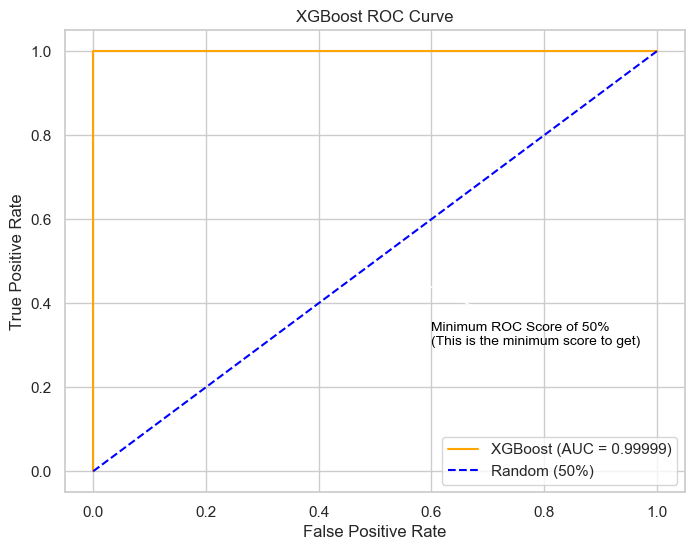

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Compute FPR, TPR and AUC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_enc, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")

# ROC Curve (green)
plt.plot(fpr_xgb, tpr_xgb, color='orange', label=f'XGBoost (AUC = {roc_auc_xgb:.5f})')

# Random baseline
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label='Random (50%)')

# Annotation
plt.annotate("Minimum ROC Score of 50%\n(This is the minimum score to get)",
             xy=(0.5, 0.5), xytext=(0.6, 0.3),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='black')

# Labels and formatting
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend(loc="lower right")
plt.show()


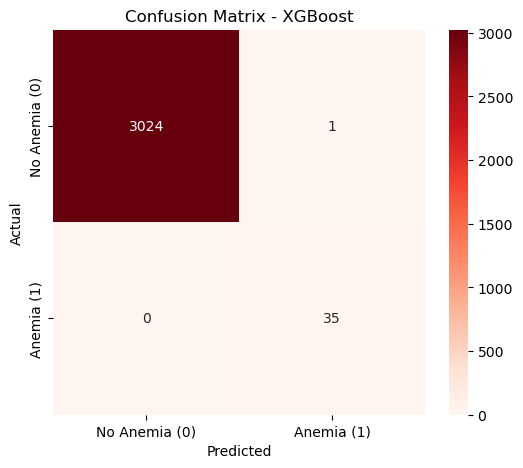


🔹 Final Results for XGBoost Model:
🔹 Accuracy: 0.9997, AUC: 0.99999


In [91]:
# 📊 Confusion Matrix for XGBoost
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

# Compute confusion matrix
cm_xgb = confusion_matrix(y_test_enc, y_pred_xgb)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Anemia (0)', 'Anemia (1)'],
            yticklabels=['No Anemia (0)', 'Anemia (1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

# ✅ Accuracy and AUC
accuracy_xgb = accuracy_score(y_test_enc, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test_enc, y_prob_xgb)  # Probabilities of class 1

# Display results
print(f"\n🔹 Final Results for XGBoost Model:")
print(f"🔹 Accuracy: {accuracy_xgb:.4f}, AUC: {roc_auc_xgb:.5f}")


In [93]:
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from collections import Counter
import numpy as np

# Define K-Fold Cross Validation
k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Store scores
accuracy_scores = []
auc_scores = []
classification_reports = []

# Estimate class imbalance for scale_pos_weight
counter = Counter(y_train_resampled)
scale_pos_weight = counter[0] / counter[1]

for fold, (train_index, test_index) in enumerate(kf.split(X_train_fs, y_train_resampled), 1):
    # Split data into training and validation for this fold
    X_train_fold, X_test_fold = X_train_fs[train_index], X_train_fs[test_index]
    y_train_fold, y_test_fold = y_train_resampled[train_index], y_train_resampled[test_index]

    # Train the model
    classifier_xgb = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        scale_pos_weight=scale_pos_weight,
        random_state=0
    )
    classifier_xgb.fit(X_train_fold, y_train_fold)

    # Predict on the validation fold
    y_pred_fold = classifier_xgb.predict(X_test_fold)
    y_proba_fold = classifier_xgb.predict_proba(X_test_fold)[:, 1]

    # Evaluate performance
    acc = accuracy_score(y_test_fold, y_pred_fold)
    auc = roc_auc_score(y_test_fold, y_proba_fold)

    accuracy_scores.append(acc)
    auc_scores.append(auc)
    classification_reports.append(classification_report(y_test_fold, y_pred_fold, output_dict=True))

    print(f"\n📘 Fold {fold} Accuracy: {acc:.4f}")
    print(f"📈 Fold {fold} AUC: {auc:.4f}")
    print(classification_report(y_test_fold, y_pred_fold))

# Average performance across folds
avg_accuracy = np.mean(accuracy_scores)
avg_auc = np.mean(auc_scores)

print(f"\n✅ Average Accuracy across {k_folds} folds: {avg_accuracy:.4f}")
print(f"✅ Average AUC across {k_folds} folds: {avg_auc:.4f}")


C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:14:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:14:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📘 Fold 1 Accuracy: 0.9996
📈 Fold 1 AUC: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2416
           1       1.00      1.00      1.00      2415

    accuracy                           1.00      4831
   macro avg       1.00      1.00      1.00      4831
weighted avg       1.00      1.00      1.00      4831


📘 Fold 2 Accuracy: 0.9998
📈 Fold 2 AUC: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2415
           1       1.00      1.00      1.00      2416

    accuracy                           1.00      4831
   macro avg       1.00      1.00      1.00      4831
weighted avg       1.00      1.00      1.00      4831



C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:14:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:14:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📘 Fold 3 Accuracy: 0.9998
📈 Fold 3 AUC: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2415
           1       1.00      1.00      1.00      2415

    accuracy                           1.00      4830
   macro avg       1.00      1.00      1.00      4830
weighted avg       1.00      1.00      1.00      4830


📘 Fold 4 Accuracy: 1.0000
📈 Fold 4 AUC: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2415
           1       1.00      1.00      1.00      2415

    accuracy                           1.00      4830
   macro avg       1.00      1.00      1.00      4830
weighted avg       1.00      1.00      1.00      4830


📘 Fold 5 Accuracy: 1.0000
📈 Fold 5 AUC: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2415
           1       1.00      1.00      1.00      2415

    accuracy                          

C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:14:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [75]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score
from scipy.stats import loguniform, randint
import optuna
import numpy as np
from collections import Counter

# Define outer K-Fold
k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Store results
results = {
    'grid': {'acc': [], 'auc': []},
    'random': {'acc': [], 'auc': []},
    'optuna': {'acc': [], 'auc': []}
}

# Class weight for imbalance
counter = Counter(y_train_resampled)
scale_pos_weight = counter[0] / counter[1]

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_fs, y_train_resampled), 1):
    print(f"\n🔁 Fold {fold}/{k_folds} ------------------------")

    X_train_fold = X_train_fs[train_idx]
    y_train_fold = y_train_resampled[train_idx]
    X_val_fold = X_train_fs[val_idx]
    y_val_fold = y_train_resampled[val_idx]

    # ----- GRID SEARCH -----
    param_grid = {
        'max_depth': [3, 5],
        'learning_rate': [0.01, 0.1],
        'n_estimators': [100, 200],
        'scale_pos_weight': [scale_pos_weight]
    }
    grid_search = GridSearchCV(
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=0),
        param_grid,
        scoring='roc_auc',
        cv=3,
        n_jobs=1
    )
    grid_search.fit(X_train_fold, y_train_fold)
    best_grid = grid_search.best_estimator_
    y_pred_grid = best_grid.predict(X_val_fold)
    y_prob_grid = best_grid.predict_proba(X_val_fold)[:, 1]
    results['grid']['acc'].append(accuracy_score(y_val_fold, y_pred_grid))
    results['grid']['auc'].append(roc_auc_score(y_val_fold, y_prob_grid))

    # ----- RANDOM SEARCH -----
    param_dist = {
        'max_depth': randint(3, 10),
        'learning_rate': loguniform(0.01, 0.3),
        'n_estimators': randint(100, 300),
        'scale_pos_weight': [scale_pos_weight]
    }
    random_search = RandomizedSearchCV(
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=0),
        param_distributions=param_dist,
        n_iter=10,
        scoring='roc_auc',
        cv=3,
        n_jobs=1,
        random_state=42
    )
    random_search.fit(X_train_fold, y_train_fold)
    best_random = random_search.best_estimator_
    y_pred_random = best_random.predict(X_val_fold)
    y_prob_random = best_random.predict_proba(X_val_fold)[:, 1]
    results['random']['acc'].append(accuracy_score(y_val_fold, y_pred_random))
    results['random']['auc'].append(roc_auc_score(y_val_fold, y_prob_random))

    # ----- OPTUNA (Bayesian Optimization) -----
    def objective(trial):
     
        params = {
            'objective': 'binary:logistic',
            'eval_metric': 'logloss',
            'max_depth': 3,
            'learning_rate': 0.1,
    # 'use_label_encoder': False,  ❌ not needed here
        }

        model = XGBClassifier(**params)
        return cross_val_score(model, X_train_fold, y_train_fold, cv=3, scoring='roc_auc').mean()

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20, show_progress_bar=False)

    best_params = study.best_params
    best_params['scale_pos_weight'] = scale_pos_weight
    best_params['use_label_encoder'] = False
    best_params['eval_metric'] = 'logloss'
    best_params['random_state'] = 0

    best_bayes = XGBClassifier(**best_params)
    best_bayes.fit(X_train_fold, y_train_fold)
    y_pred_bayes = best_bayes.predict(X_val_fold)
    y_prob_bayes = best_bayes.predict_proba(X_val_fold)[:, 1]
    results['optuna']['acc'].append(accuracy_score(y_val_fold, y_pred_bayes))
    results['optuna']['auc'].append(roc_auc_score(y_val_fold, y_prob_bayes))

# 🔚 Final average scores
print("\n📊 Final Cross-Validated Results (Avg across folds):")
for method in results:
    avg_acc = np.mean(results[method]['acc'])
    avg_auc = np.mean(results[method]['auc'])
    print(f"📌 {method.upper():<10} | Accuracy: {avg_acc:.4f} | AUC: {avg_auc:.4f}")



🔁 Fold 1/5 ------------------------


C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:57:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:57:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:57:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:57:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not use


🔁 Fold 2/5 ------------------------


C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:57:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:57:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:57:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:57:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not use


🔁 Fold 3/5 ------------------------


...

C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:57:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:57:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:57:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:57:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not use


🔁 Fold 5/5 ------------------------


C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:58:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:58:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:58:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:58:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not use


📊 Final Cross-Validated Results (Avg across folds):
📌 GRID       | Accuracy: 0.9998 | AUC: 1.0000
📌 RANDOM     | Accuracy: 0.9998 | AUC: 1.0000
📌 OPTUNA     | Accuracy: 0.9998 | AUC: 1.0000


C:\Users\HungPhatPC\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:58:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Logistic Regression

In [88]:
#logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
classifier_lr = LogisticRegression(class_weight = 'balanced',random_state = 0)
classifier_lr.fit(X_train_fs, y_train_resampled)
y_pred_lr = classifier_lr.predict(X_test_fs)  # Predict with all features

In [90]:
print("🔹 Classification Report of LR")
print(classification_report(y_test_enc, y_pred_lr))

🔹 Classification Report of LR
              precision    recall  f1-score   support

           0       1.00      0.93      0.97      3025
           1       0.15      1.00      0.26        35

    accuracy                           0.93      3060
   macro avg       0.57      0.97      0.61      3060
weighted avg       0.99      0.93      0.96      3060



In [92]:
#Predict
y_pred_lr = classifier_lr.predict(X_test_fs)
results_df = pd.DataFrame({
    'Predicted': y_pred_lr,
    'Actual': y_test_enc
})
#Print
y_prob_lr = classifier_lr.predict_proba(X_test_fs)[:, 1] # Probability of class 1
results_df['Probability'] = y_prob_lr
results_df["Probability"] = results_df["Probability"].round(4)
print(results_df)

      Predicted  Actual  Probability
0             0       0       0.0000
1             0       0       0.0001
2             0       0       0.0000
3             0       0       0.0942
4             1       0       0.9965
...         ...     ...          ...
3055          0       0       0.0000
3056          0       0       0.0000
3057          0       0       0.0000
3058          0       0       0.0001
3059          0       0       0.0002

[3060 rows x 3 columns]


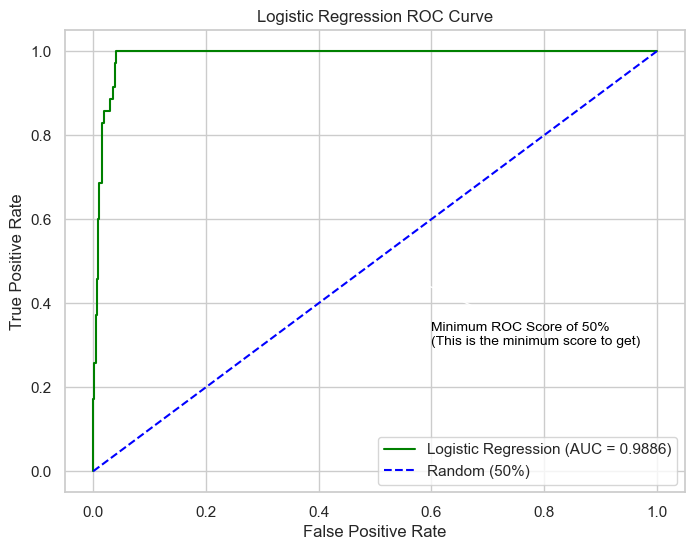

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC score
fpr_lr, tpr_lr, _ = roc_curve(y_test_enc, y_prob_lr)  # False Positive Rate, True Positive Rate
roc_auc = auc(fpr_lr, tpr_lr)  # Compute AUC

#Plot ROC Curve
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")

# ROCcurve(orange line)
plt.plot(fpr_lr, tpr_lr, color='green', label=f'Logistic Regression (AUC = {roc_auc:.4f})')

# Baseline(Random Model) at 50%
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label="Random (50%)")  

# Add annotation
plt.annotate("Minimum ROC Score of 50%\n(This is the minimum score to get)",
             xy=(0.5, 0.5), xytext=(0.6, 0.3),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='black')

# Labels & Title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend(loc="lower right")

# Show the plot
plt.show()

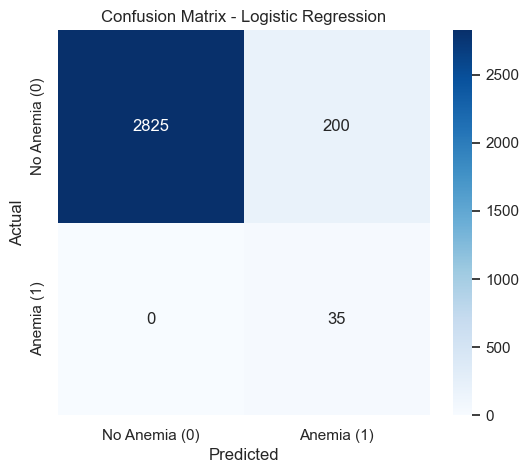


🔹 Final Results for Logistic Regression Model:
🔹 Accuracy: 0.935, AUC: 0.989


In [50]:
#Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score

# Compute confusion matrix
cm_lr = confusion_matrix(y_test_enc, y_pred_lr)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot = True, fmt = 'd', cmap = 'Blues', 
            xticklabels = ['No Anemia (0)', 'Anemia (1)'], 
            yticklabels = ['No Anemia (0)', 'Anemia (1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()
# Compute Accuracy & AUC
accuracy_lr = accuracy_score(y_test_enc, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test_enc, y_prob_lr)  # Using probability predictions

# Display Accuracy & AUC
print(f"\n🔹 Final Results for Logistic Regression Model:")
print(f"🔹 Accuracy: {accuracy_lr:.3f}, AUC: {roc_auc_lr:.3f}")


In [52]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

# Define K-Fold Cross Validation
k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Store scores
accuracy_scores = []
auc_scores = []
classification_reports = []

for fold, (train_index, test_index) in enumerate(kf.split(X_train_fs, y_train_resampled), 1):
    # Split data into training and validation for this fold
    X_train_fold, X_test_fold = X_train_fs[train_index], X_train_fs[test_index]
    y_train_fold, y_test_fold = y_train_resampled[train_index], y_train_resampled[test_index]

    # Train the model
    classifier_lr = LogisticRegression(class_weight='balanced', random_state=0)
    classifier_lr.fit(X_train_fold, y_train_fold)

    # Predict on the validation fold
    y_pred_fold = classifier_lr.predict(X_test_fold)
    y_proba_fold = classifier_lr.predict_proba(X_test_fold)[:, 1]  # probability of class 1

    # Evaluate performance
    acc = accuracy_score(y_test_fold, y_pred_fold)
    auc = roc_auc_score(y_test_fold, y_proba_fold)

    accuracy_scores.append(acc)
    auc_scores.append(auc)
    classification_reports.append(classification_report(y_test_fold, y_pred_fold, output_dict=True))

    print(f"\n📘 Fold {fold} Accuracy: {acc:.4f}")
    print(f"📈 Fold {fold} AUC: {auc:.4f}")
    print(classification_report(y_test_fold, y_pred_fold))

# Average performance across folds
avg_accuracy = np.mean(accuracy_scores)
avg_auc = np.mean(auc_scores)

print(f"\n✅ Average Accuracy across {k_folds} folds: {avg_accuracy:.4f}")
print(f"✅ Average AUC across {k_folds} folds: {avg_auc:.4f}")



📘 Fold 1 Accuracy: 0.9572
📈 Fold 1 AUC: 0.9818
              precision    recall  f1-score   support

           0       0.99      0.92      0.96      2416
           1       0.93      0.99      0.96      2415

    accuracy                           0.96      4831
   macro avg       0.96      0.96      0.96      4831
weighted avg       0.96      0.96      0.96      4831


📘 Fold 2 Accuracy: 0.9629
📈 Fold 2 AUC: 0.9838
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      2415
           1       0.94      0.99      0.96      2416

    accuracy                           0.96      4831
   macro avg       0.96      0.96      0.96      4831
weighted avg       0.96      0.96      0.96      4831


📘 Fold 3 Accuracy: 0.9511
📈 Fold 3 AUC: 0.9804
              precision    recall  f1-score   support

           0       0.98      0.92      0.95      2415
           1       0.93      0.98      0.95      2415

    accuracy                          

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score, accuracy_score
from scipy.stats import loguniform
import optuna

# ---------------- GRID SEARCH ---------------- #
param_grid = [
    {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs']},
    {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
]

grid_search = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=0),
    param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train_fs, y_train_resampled)  # ✅ Required before .best_estimator_
best_grid_lr = grid_search.best_estimator_
print("\n🔹 GridSearch Best Hyperparameters:", grid_search.best_params_)
print("🔹 GridSearch Best AUC:", grid_search.best_score_)
# Predict and evaluate accuracy
y_pred_grid = best_grid_lr.predict(X_test_fs)
grid_acc = accuracy_score(y_test_enc, y_pred_grid)

print("🔹 GridSearch Best AUC:", grid_search.best_score_)
print(f"🔹 GridSearch Test Accuracy: {grid_acc:.4f}")

# ---------------- RANDOM SEARCH ---------------- #
param_dist = {
    'C': loguniform(0.001, 100),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
}

random_search = RandomizedSearchCV(LogisticRegression(class_weight='balanced', random_state=0),
                                   param_distributions=param_dist,
                                   n_iter=15,
                                   cv=3,
                                   scoring='roc_auc',   # ✅ AUC here
                                   random_state=42,
                                   verbose=1,
                                   n_jobs=-1)

random_search.fit(X_train_fs, y_train_resampled)

best_random_lr = random_search.best_estimator_
print("\n🔹 RandomSearch Best Hyperparameters:", random_search.best_params_)
print("🔹 RandomSearch Best AUC:", random_search.best_score_)
y_pred_random = best_random_lr.predict(X_test_fs)
random_acc = accuracy_score(y_test_enc, y_pred_random)

print("🔹 RandomSearch Best AUC:", random_search.best_score_)
print(f"🔹 RandomSearch Test Accuracy: {random_acc:.4f}")

# ---------------- OPTUNA BAYESIAN OPTIMIZATION ---------------- #
def objective(trial):
    C = trial.suggest_float('C', 0.001, 100, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = 'liblinear'

    model = LogisticRegression(C=C, penalty=penalty, solver=solver,
                               class_weight='balanced', random_state=0)
    scores = cross_val_score(model, X_train_fs, y_train_resampled, cv=5, scoring='roc_auc')  # ✅ AUC scoring
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

best_bayes_lr = LogisticRegression(**study.best_params, solver='liblinear',
                                   class_weight='balanced', random_state=0)
best_bayes_lr.fit(X_train_fs, y_train_resampled)

print("\n🔹 Bayesian Optimization Best Hyperparameters:", study.best_params)
print("🔹 Bayesian Optimization Best AUC:", study.best_value)
y_pred_bayes = best_bayes_lr.predict(X_test_fs)
bayes_acc = accuracy_score(y_test_enc, y_pred_bayes)

print("🔹 Bayesian Optimization Best AUC:", study.best_value)
print(f"🔹 Bayesian Optimization Test Accuracy: {bayes_acc:.4f}")


Fitting 3 folds for each of 12 candidates, totalling 36 fits

🔹 GridSearch Best Hyperparameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
🔹 GridSearch Best AUC: 0.9590508746904117
🔹 GridSearch Best AUC: 0.9590508746904117
🔹 GridSearch Test Accuracy: 0.9363
Fitting 3 folds for each of 15 candidates, totalling 45 fits


[I 2025-04-18 17:07:53,100] A new study created in memory with name: no-name-f7a2a2b1-0279-472d-9e80-736509b59da0



🔹 RandomSearch Best Hyperparameters: {'C': 1.1435780278433403, 'penalty': 'l1', 'solver': 'liblinear'}
🔹 RandomSearch Best AUC: 0.9817233229382776
🔹 RandomSearch Best AUC: 0.9817233229382776
🔹 RandomSearch Test Accuracy: 0.9359


[I 2025-04-18 17:07:54,053] Trial 0 finished with value: 0.9813790609288612 and parameters: {'C': 1.3519137663296206, 'penalty': 'l2'}. Best is trial 0 with value: 0.9813790609288612.
[I 2025-04-18 17:07:54,667] Trial 1 finished with value: 0.9782316277888448 and parameters: {'C': 0.011334415705367031, 'penalty': 'l1'}. Best is trial 0 with value: 0.9813790609288612.
[I 2025-04-18 17:07:55,056] Trial 2 finished with value: 0.9569222855890397 and parameters: {'C': 0.004235984708259896, 'penalty': 'l2'}. Best is trial 0 with value: 0.9813790609288612.
[I 2025-04-18 17:07:56,412] Trial 3 finished with value: 0.9817008798369894 and parameters: {'C': 43.37581748989569, 'penalty': 'l2'}. Best is trial 3 with value: 0.9817008798369894.
[I 2025-04-18 17:07:58,137] Trial 4 finished with value: 0.9816787721928282 and parameters: {'C': 8.07250352316245, 'penalty': 'l2'}. Best is trial 3 with value: 0.9817008798369894.
[I 2025-04-18 17:08:23,213] Trial 5 finished with value: 0.9817012553766483 and


🔹 Bayesian Optimization Best Hyperparameters: {'C': 1.5735358920367426, 'penalty': 'l1'}
🔹 Bayesian Optimization Best AUC: 0.9817234743853934
🔹 Bayesian Optimization Best AUC: 0.9817234743853934
🔹 Bayesian Optimization Test Accuracy: 0.9363


In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score
from scipy.stats import loguniform
import optuna
import numpy as np

# Define outer K-Fold
k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Store results
results = {
    'grid': {'acc': [], 'auc': []},
    'random': {'acc': [], 'auc': []},
    'optuna': {'acc': [], 'auc': []}
}

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_fs, y_train_resampled), 1):
    print(f"\n🔁 Fold {fold}/{k_folds} ------------------------")

    X_train_fold = X_train_fs[train_idx]
    y_train_fold = y_train_resampled[train_idx]
    X_val_fold = X_train_fs[val_idx]
    y_val_fold = y_train_resampled[val_idx]

    # ----- GRID SEARCH -----
    param_grid = [
        {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['lbfgs']},
        {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}
    ]
    grid_search = GridSearchCV(
        LogisticRegression(class_weight='balanced', random_state=0),
        param_grid,
        cv=3,
        scoring='roc_auc',
        n_jobs=-1
    )
    grid_search.fit(X_train_fold, y_train_fold)
    best_grid = grid_search.best_estimator_
    y_pred_grid = best_grid.predict(X_val_fold)
    y_prob_grid = best_grid.predict_proba(X_val_fold)[:, 1]
    results['grid']['acc'].append(accuracy_score(y_val_fold, y_pred_grid))
    results['grid']['auc'].append(roc_auc_score(y_val_fold, y_prob_grid))

    # ----- RANDOM SEARCH -----
    param_dist = {
        'C': loguniform(0.001, 100),
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    }
    random_search = RandomizedSearchCV(
        LogisticRegression(class_weight='balanced', random_state=0),
        param_distributions=param_dist,
        n_iter=10,
        cv=3,
        scoring='roc_auc',
        n_jobs=-1,
        random_state=42
    )
    random_search.fit(X_train_fold, y_train_fold)
    best_random = random_search.best_estimator_
    y_pred_random = best_random.predict(X_val_fold)
    y_prob_random = best_random.predict_proba(X_val_fold)[:, 1]
    results['random']['acc'].append(accuracy_score(y_val_fold, y_pred_random))
    results['random']['auc'].append(roc_auc_score(y_val_fold, y_prob_random))

    # ----- OPTUNA (Bayesian Optimization) -----
    def objective(trial):
        C = trial.suggest_float('C', 0.001, 100, log=True)
        penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
        solver = 'liblinear'
        model = LogisticRegression(C=C, penalty=penalty, solver=solver,
                                   class_weight='balanced', random_state=0)
        return cross_val_score(model, X_train_fold, y_train_fold, cv=3, scoring='roc_auc').mean()

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20, show_progress_bar=False)

    best_bayes = LogisticRegression(**study.best_params,
                                    solver='liblinear',
                                    class_weight='balanced',
                                    random_state=0)
    best_bayes.fit(X_train_fold, y_train_fold)
    y_pred_bayes = best_bayes.predict(X_val_fold)
    y_prob_bayes = best_bayes.predict_proba(X_val_fold)[:, 1]
    results['optuna']['acc'].append(accuracy_score(y_val_fold, y_pred_bayes))
    results['optuna']['auc'].append(roc_auc_score(y_val_fold, y_prob_bayes))

# 🔚 Final average scores
print("\n📊 Final Cross-Validated Results (Avg across folds):")
for method in results:
    avg_acc = np.mean(results[method]['acc'])
    avg_auc = np.mean(results[method]['auc'])
    print(f"📌 {method.upper():<10} | Accuracy: {avg_acc:.4f} | AUC: {avg_auc:.4f}")



🔁 Fold 1/5 ------------------------


[I 2025-04-18 17:12:13,598] A new study created in memory with name: no-name-0e5fc7ea-1567-4f77-9e5c-0cc8dc8e40ca
[I 2025-04-18 17:12:13,847] Trial 0 finished with value: 0.9790839645559624 and parameters: {'C': 0.22660037308368736, 'penalty': 'l2'}. Best is trial 0 with value: 0.9790839645559624.
[I 2025-04-18 17:12:14,221] Trial 1 finished with value: 0.9793204028597341 and parameters: {'C': 0.04556502495192055, 'penalty': 'l1'}. Best is trial 1 with value: 0.9793204028597341.
[I 2025-04-18 17:12:21,524] Trial 2 finished with value: 0.9815514688587834 and parameters: {'C': 2.558266877146396, 'penalty': 'l1'}. Best is trial 2 with value: 0.9815514688587834.
[I 2025-04-18 17:12:21,915] Trial 3 finished with value: 0.9810225026369239 and parameters: {'C': 1.5689812341872398, 'penalty': 'l2'}. Best is trial 2 with value: 0.9815514688587834.
[I 2025-04-18 17:12:22,305] Trial 4 finished with value: 0.9810980717795111 and parameters: {'C': 1.8396833300047808, 'penalty': 'l2'}. Best is trial


🔁 Fold 2/5 ------------------------


[I 2025-04-18 17:14:11,879] A new study created in memory with name: no-name-5d6a27b7-ed60-4acb-856a-2b2afcdd1a39
[I 2025-04-18 17:14:11,996] Trial 0 finished with value: 0.9524322325958746 and parameters: {'C': 0.0044151740636681, 'penalty': 'l2'}. Best is trial 0 with value: 0.9524322325958746.
[I 2025-04-18 17:14:17,315] Trial 1 finished with value: 0.9820834955004604 and parameters: {'C': 0.6421823748984359, 'penalty': 'l1'}. Best is trial 1 with value: 0.9820834955004604.
[I 2025-04-18 17:14:17,482] Trial 2 finished with value: 0.9777281264836958 and parameters: {'C': 0.1260877276671023, 'penalty': 'l2'}. Best is trial 1 with value: 0.9820834955004604.
[I 2025-04-18 17:14:17,898] Trial 3 finished with value: 0.9794974916081619 and parameters: {'C': 0.04818909192597535, 'penalty': 'l1'}. Best is trial 1 with value: 0.9820834955004604.
[I 2025-04-18 17:14:17,994] Trial 4 finished with value: 0.9448214460133153 and parameters: {'C': 0.002261439483012186, 'penalty': 'l2'}. Best is tri


🔁 Fold 3/5 ------------------------


...


🔁 Fold 4/5 ------------------------


[I 2025-04-18 17:17:31,977] A new study created in memory with name: no-name-53dc58a8-60e0-42d9-9243-0fe1493f5f7e
[I 2025-04-18 17:17:32,112] Trial 0 finished with value: 0.9670618593565065 and parameters: {'C': 0.017894877977614094, 'penalty': 'l2'}. Best is trial 0 with value: 0.9670618593565065.
[I 2025-04-18 17:17:32,188] Trial 1 finished with value: 0.9101731925054142 and parameters: {'C': 0.0011553462255631905, 'penalty': 'l1'}. Best is trial 0 with value: 0.9670618593565065.
[I 2025-04-18 17:17:32,411] Trial 2 finished with value: 0.9783958135950565 and parameters: {'C': 0.017445283501641047, 'penalty': 'l1'}. Best is trial 2 with value: 0.9783958135950565.
[I 2025-04-18 17:17:32,583] Trial 3 finished with value: 0.9752329068082877 and parameters: {'C': 0.00843826692881705, 'penalty': 'l1'}. Best is trial 2 with value: 0.9783958135950565.
[I 2025-04-18 17:17:40,203] Trial 4 finished with value: 0.9816103555927901 and parameters: {'C': 1.6502164457748538, 'penalty': 'l1'}. Best i


🔁 Fold 5/5 ------------------------


[I 2025-04-18 17:18:55,236] A new study created in memory with name: no-name-233eb3da-1551-4ab0-838d-fd07cc8d6e9e
[I 2025-04-18 17:18:55,375] Trial 0 finished with value: 0.9650190775514211 and parameters: {'C': 0.014129175989013821, 'penalty': 'l2'}. Best is trial 0 with value: 0.9650190775514211.
[I 2025-04-18 17:19:03,244] Trial 1 finished with value: 0.9816389774045094 and parameters: {'C': 9.791130757515674, 'penalty': 'l1'}. Best is trial 1 with value: 0.9816389774045094.
[I 2025-04-18 17:19:03,715] Trial 2 finished with value: 0.9815843360307204 and parameters: {'C': 16.203517789630485, 'penalty': 'l2'}. Best is trial 1 with value: 0.9816389774045094.
[I 2025-04-18 17:19:03,945] Trial 3 finished with value: 0.979888218416442 and parameters: {'C': 0.3546550055057903, 'penalty': 'l2'}. Best is trial 1 with value: 0.9816389774045094.
[I 2025-04-18 17:19:04,160] Trial 4 finished with value: 0.9795368728531831 and parameters: {'C': 0.2749686709375763, 'penalty': 'l2'}. Best is trial 


📊 Final Cross-Validated Results (Avg across folds):
📌 GRID       | Accuracy: 0.9591 | AUC: 0.9819
📌 RANDOM     | Accuracy: 0.9590 | AUC: 0.9819
📌 OPTUNA     | Accuracy: 0.9590 | AUC: 0.9819


## GNB

In [95]:
# Import Gaussian Naïve Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

classifier_gnb = GaussianNB()
classifier_gnb.fit(X_train_fs, y_train_resampled)

# Predict on the test set
y_pred_gnb = classifier_gnb.predict(X_test_fs)

In [97]:
# Compute Accuracy
accuracy_gnb = accuracy_score(y_test_enc, y_pred_gnb)

# Print classification report
print("\n🔹 Classification Report for GNB:")
print(classification_report(y_test_enc, y_pred_gnb))

# Print Accuracy
print(f"\n🔹 GNB Accuracy: {accuracy_gnb:.3f}")



🔹 Classification Report for GNB:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89      3025
           1       0.05      0.94      0.10        35

    accuracy                           0.81      3060
   macro avg       0.53      0.87      0.50      3060
weighted avg       0.99      0.81      0.88      3060


🔹 GNB Accuracy: 0.805


In [99]:
#Predict
y_pred_gnb = classifier_gnb.predict(X_test_fs)
results_df = pd.DataFrame({
    'Predicted': y_pred_gnb,
    'Actual': y_test_enc
})
#Print
y_prob_gnb = classifier_gnb.predict_proba(X_test_fs)[:, 1] # Probability of class 1
results_df['Probability'] = y_prob_gnb
results_df['Probability'] = results_df['Probability'].round(4)
print(results_df.head(20))

    Predicted  Actual  Probability
0           0       0       0.0000
1           0       0       0.0000
2           0       0       0.0000
3           0       0       0.4704
4           1       0       0.9999
5           0       0       0.0000
6           0       0       0.0035
7           0       0       0.0001
8           0       0       0.0000
9           0       0       0.1277
10          0       0       0.0000
11          0       0       0.0000
12          0       0       0.0000
13          0       0       0.0000
14          0       0       0.1597
15          0       0       0.0000
16          1       0       0.8410
17          0       0       0.0000
18          1       0       0.9974
19          1       0       0.9623


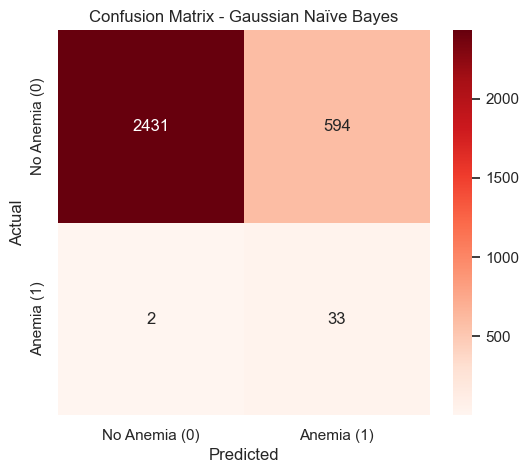


🔹 Final Results for GNB Model:
🔹 Accuracy: 0.805, AUC: 0.957


In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score

# Compute confusion matrix
cm_gnb = confusion_matrix(y_test_enc, y_pred_gnb)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Anemia (0)', 'Anemia (1)'],
            yticklabels=['No Anemia (0)', 'Anemia (1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Gaussian Naïve Bayes")
plt.show()

# Compute Accuracy & AUC
accuracy_gnb = accuracy_score(y_test_enc, y_pred_gnb)
roc_auc_gnb = roc_auc_score(y_test_enc, y_prob_gnb)  # Using probability predictions

# Display Accuracy & AUC
print(f"\n🔹 Final Results for GNB Model:")
print(f"🔹 Accuracy: {accuracy_gnb:.3f}, AUC: {roc_auc_gnb:.3f}")


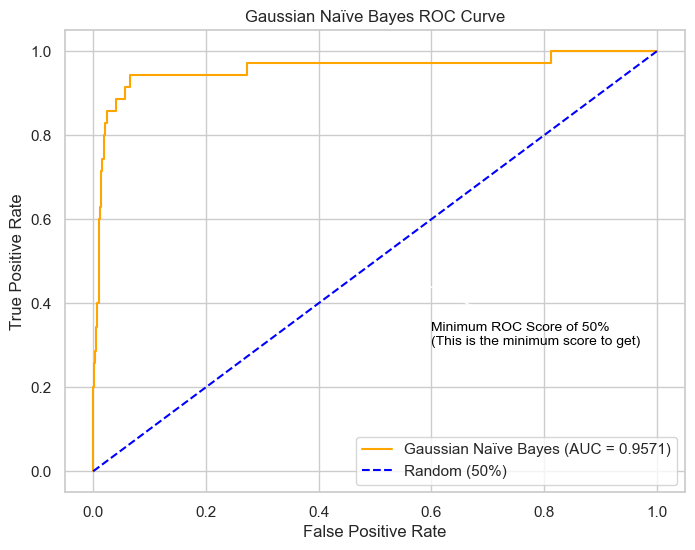

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC score for GNB
fpr_gnb, tpr_gnb, _ = roc_curve(y_test_enc, y_prob_gnb)  # False Positive Rate, True Positive Rate
roc_auc_gnb = auc(fpr_gnb, tpr_gnb)  # Compute AUC

# Plot ROC Curve
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")

# ROC curve (green line for GNB)
plt.plot(fpr_gnb, tpr_gnb, color='orange', label=f'Gaussian Naïve Bayes (AUC = {roc_auc_gnb:.4f})')

# Baseline (Random Model) at 50%
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label="Random (50%)")  

# Add annotation
plt.annotate("Minimum ROC Score of 50%\n(This is the minimum score to get)",
             xy=(0.5, 0.5), xytext=(0.6, 0.3),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='black')

# Labels & Title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gaussian Naïve Bayes ROC Curve")
plt.legend(loc="lower right")

# Show the plot
plt.show()


In [65]:
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

# Define K-Fold Cross Validation
k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Store scores
accuracy_scores = []
auc_scores = []
classification_reports = []

for fold, (train_index, test_index) in enumerate(kf.split(X_train_fs, y_train_resampled), 1):
    # Split data into training and validation for this fold
    X_train_fold, X_test_fold = X_train_fs[train_index], X_train_fs[test_index]
    y_train_fold, y_test_fold = y_train_resampled[train_index], y_train_resampled[test_index]

    # Train the model
    classifier_gnb = GaussianNB()
    classifier_gnb.fit(X_train_fold, y_train_fold)

    # Predict on the validation fold
    y_pred_fold = classifier_gnb.predict(X_test_fold)
    y_proba_fold = classifier_gnb.predict_proba(X_test_fold)[:, 1]  # probability of class 1

    # Evaluate performance
    acc = accuracy_score(y_test_fold, y_pred_fold)
    auc = roc_auc_score(y_test_fold, y_proba_fold)

    accuracy_scores.append(acc)
    auc_scores.append(auc)
    classification_reports.append(classification_report(y_test_fold, y_pred_fold, output_dict=True))

    print(f"\n📘 Fold {fold} Accuracy: {acc:.4f}")
    print(f"📈 Fold {fold} AUC: {auc:.4f}")
    print(classification_report(y_test_fold, y_pred_fold))

# Average performance across folds
avg_accuracy = np.mean(accuracy_scores)
avg_auc = np.mean(auc_scores)

print(f"\n✅ Average Accuracy across {k_folds} folds: {avg_accuracy:.4f}")
print(f"✅ Average AUC across {k_folds} folds: {avg_auc:.4f}")



📘 Fold 1 Accuracy: 0.8897
📈 Fold 1 AUC: 0.9586
              precision    recall  f1-score   support

           0       0.95      0.82      0.88      2416
           1       0.84      0.96      0.90      2415

    accuracy                           0.89      4831
   macro avg       0.90      0.89      0.89      4831
weighted avg       0.90      0.89      0.89      4831


📘 Fold 2 Accuracy: 0.8862
📈 Fold 2 AUC: 0.9647
              precision    recall  f1-score   support

           0       0.96      0.81      0.88      2415
           1       0.83      0.96      0.89      2416

    accuracy                           0.89      4831
   macro avg       0.90      0.89      0.89      4831
weighted avg       0.90      0.89      0.89      4831


📘 Fold 3 Accuracy: 0.8687
📈 Fold 3 AUC: 0.9560
              precision    recall  f1-score   support

           0       0.95      0.78      0.86      2415
           1       0.81      0.96      0.88      2415

    accuracy                          

In [67]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from scipy.stats import loguniform
import optuna

# ---------------- GRID SEARCH ---------------- #
param_grid_gnb = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]}

grid_search_gnb = GridSearchCV(GaussianNB(),
                               param_grid_gnb,
                               cv=5,
                               scoring='accuracy',
                               verbose=1,
                               n_jobs=-1)

grid_search_gnb.fit(X_train_fs, y_train_resampled)

best_grid_gnb = grid_search_gnb.best_estimator_
print("\n🔹 GridSearch Best Hyperparameters (GNB):", grid_search_gnb.best_params_)
print("🔹 GridSearch Best Accuracy:", grid_search_gnb.best_score_)

# ---------------- RANDOM SEARCH ---------------- #
param_dist_gnb = {'var_smoothing': loguniform(1e-9, 1e-1)}

random_search_gnb = RandomizedSearchCV(GaussianNB(),
                                       param_distributions=param_dist_gnb,
                                       n_iter=30,  # Try 30 random combinations
                                       cv=5,
                                       scoring='accuracy',
                                       random_state=42,
                                       verbose=1,
                                       n_jobs=-1)

random_search_gnb.fit(X_train_fs, y_train_resampled)

best_random_gnb = random_search_gnb.best_estimator_
print("\n🔹 RandomSearch Best Hyperparameters (GNB):", random_search_gnb.best_params_)
print("🔹 RandomSearch Best Accuracy:", random_search_gnb.best_score_)

# ---------------- OPTUNA BAYESIAN OPTIMIZATION ---------------- #
def objective_gnb(trial):
    var_smoothing = trial.suggest_float('var_smoothing', 1e-9, 1e-1, log=True)

    model = GaussianNB(var_smoothing=var_smoothing)
    scores = cross_val_score(model, X_train_fs, y_train_resampled, cv=5, scoring='accuracy')
    return scores.mean()

study_gnb = optuna.create_study(direction='maximize')
study_gnb.optimize(objective_gnb, n_trials=50)

best_bayes_gnb = GaussianNB(var_smoothing=study_gnb.best_params['var_smoothing'])
best_bayes_gnb.fit(X_train_fs, y_train_resampled)

print("\n🔹 Bayesian Optimization Best Hyperparameters (GNB):", study_gnb.best_params)
print("🔹 Bayesian Optimization Best Accuracy:", study_gnb.best_value)


Fitting 5 folds for each of 9 candidates, totalling 45 fits

🔹 GridSearch Best Hyperparameters (GNB): {'var_smoothing': 1e-06}
🔹 GridSearch Best Accuracy: 0.8781880650886078
Fitting 5 folds for each of 30 candidates, totalling 150 fits


[I 2025-04-17 16:02:09,857] A new study created in memory with name: no-name-e4b3d03d-97bc-467f-89eb-b963e0b2ab4d
[I 2025-04-17 16:02:09,932] Trial 0 finished with value: 0.8712735426354895 and parameters: {'var_smoothing': 0.0007906227978492844}. Best is trial 0 with value: 0.8712735426354895.
[I 2025-04-17 16:02:10,007] Trial 1 finished with value: 0.8745858634688923 and parameters: {'var_smoothing': 0.0004052212157578303}. Best is trial 1 with value: 0.8745858634688923.



🔹 RandomSearch Best Hyperparameters (GNB): {'var_smoothing': 9.91564456663839e-07}
🔹 RandomSearch Best Accuracy: 0.8781880650886078


[I 2025-04-17 16:02:10,131] Trial 2 finished with value: 0.8725570836724348 and parameters: {'var_smoothing': 0.0006563015106995013}. Best is trial 1 with value: 0.8745858634688923.
[I 2025-04-17 16:02:10,217] Trial 3 finished with value: 0.8766974761429056 and parameters: {'var_smoothing': 0.0001490751611097936}. Best is trial 3 with value: 0.8766974761429056.
[I 2025-04-17 16:02:10,296] Trial 4 finished with value: 0.874130411211581 and parameters: {'var_smoothing': 0.00047451712010787475}. Best is trial 3 with value: 0.8766974761429056.
[I 2025-04-17 16:02:10,406] Trial 5 finished with value: 0.8723500614775264 and parameters: {'var_smoothing': 0.0006732617608900889}. Best is trial 3 with value: 0.8766974761429056.
[I 2025-04-17 16:02:10,512] Trial 6 finished with value: 0.8238652285768284 and parameters: {'var_smoothing': 0.011503764747827126}. Best is trial 3 with value: 0.8766974761429056.
[I 2025-04-17 16:02:10,637] Trial 7 finished with value: 0.7954615142971141 and parameters:


🔹 Bayesian Optimization Best Hyperparameters (GNB): {'var_smoothing': 1.3002475033840823e-06}
🔹 Bayesian Optimization Best Accuracy: 0.8781880650886078


In [78]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score
from scipy.stats import loguniform
import optuna
import numpy as np

k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Storage
results = {
    'grid': {'acc': [], 'auc': []},
    'random': {'acc': [], 'auc': []},
    'optuna': {'acc': [], 'auc': []}
}

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_fs, y_train_resampled), 1):
    print(f"\n🔁 Fold {fold}/{k_folds}")

    X_train_fold = X_train_fs[train_idx]
    y_train_fold = y_train_resampled[train_idx]
    X_val_fold = X_train_fs[val_idx]
    y_val_fold = y_train_resampled[val_idx]

    # ---------------- GRID SEARCH ---------------- #
    param_grid_gnb = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]}
    grid_search_gnb = GridSearchCV(GaussianNB(),
                                   param_grid_gnb,
                                   cv=3,
                                   scoring='roc_auc',
                                   verbose=0,
                                   n_jobs=-1)
    grid_search_gnb.fit(X_train_fold, y_train_fold)
    best_grid = grid_search_gnb.best_estimator_
    y_pred_grid = best_grid.predict(X_val_fold)
    y_prob_grid = best_grid.predict_proba(X_val_fold)[:, 1]
    results['grid']['acc'].append(accuracy_score(y_val_fold, y_pred_grid))
    results['grid']['auc'].append(roc_auc_score(y_val_fold, y_prob_grid))

    # ---------------- RANDOM SEARCH ---------------- #
    param_dist_gnb = {'var_smoothing': loguniform(1e-9, 1e-1)}
    random_search_gnb = RandomizedSearchCV(GaussianNB(),
                                           param_distributions=param_dist_gnb,
                                           n_iter=15,
                                           cv=3,
                                           scoring='roc_auc',
                                           random_state=42,
                                           verbose=0,
                                           n_jobs=-1)
    random_search_gnb.fit(X_train_fold, y_train_fold)
    best_random = random_search_gnb.best_estimator_
    y_pred_rand = best_random.predict(X_val_fold)
    y_prob_rand = best_random.predict_proba(X_val_fold)[:, 1]
    results['random']['acc'].append(accuracy_score(y_val_fold, y_pred_rand))
    results['random']['auc'].append(roc_auc_score(y_val_fold, y_prob_rand))

    # ---------------- OPTUNA BAYESIAN OPTIMIZATION ---------------- #
    def objective_gnb(trial):
        var_smoothing = trial.suggest_float('var_smoothing', 1e-9, 1e-1, log=True)
        model = GaussianNB(var_smoothing=var_smoothing)
        return cross_val_score(model, X_train_fold, y_train_fold, cv=3, scoring='roc_auc').mean()

    study = optuna.create_study(direction='maximize')
    study.optimize(objective_gnb, n_trials=20, show_progress_bar=False)

    best_bayes = GaussianNB(var_smoothing=study.best_params['var_smoothing'])
    best_bayes.fit(X_train_fold, y_train_fold)
    y_pred_bayes = best_bayes.predict(X_val_fold)
    y_prob_bayes = best_bayes.predict_proba(X_val_fold)[:, 1]
    results['optuna']['acc'].append(accuracy_score(y_val_fold, y_pred_bayes))
    results['optuna']['auc'].append(roc_auc_score(y_val_fold, y_prob_bayes))

# 📊 Final Average Performance
print("\n✅ Final Average Results (Nested CV):")
for method in results:
    avg_acc = np.mean(results[method]['acc'])
    avg_auc = np.mean(results[method]['auc'])
    print(f"📌 {method.upper():<10} | Accuracy: {avg_acc:.4f} | AUC: {avg_auc:.4f}")



🔁 Fold 1/5


[I 2025-04-18 17:30:01,168] A new study created in memory with name: no-name-91182723-541e-4c64-a2ad-7b7d03f8b45a
[I 2025-04-18 17:30:01,221] Trial 0 finished with value: 0.9592714536593991 and parameters: {'var_smoothing': 9.718944336415303e-06}. Best is trial 0 with value: 0.9592714536593991.
[I 2025-04-18 17:30:01,267] Trial 1 finished with value: 0.9592652496177229 and parameters: {'var_smoothing': 1.1522515310829053e-05}. Best is trial 0 with value: 0.9592714536593991.
[I 2025-04-18 17:30:01,310] Trial 2 finished with value: 0.9592344868605709 and parameters: {'var_smoothing': 2.212186917097459e-05}. Best is trial 0 with value: 0.9592714536593991.
[I 2025-04-18 17:30:01,353] Trial 3 finished with value: 0.9593024415491386 and parameters: {'var_smoothing': 4.139052676779057e-07}. Best is trial 3 with value: 0.9593024415491386.
[I 2025-04-18 17:30:01,396] Trial 4 finished with value: 0.9402295440025474 and parameters: {'var_smoothing': 0.01083434856317226}. Best is trial 3 with valu


🔁 Fold 2/5


[I 2025-04-18 17:30:03,173] A new study created in memory with name: no-name-2905a342-19d9-4daa-abbb-fb82f3ff1ae4
[I 2025-04-18 17:30:03,216] Trial 0 finished with value: 0.9589755741492821 and parameters: {'var_smoothing': 1.8102437768233958e-07}. Best is trial 0 with value: 0.9589755741492821.
[I 2025-04-18 17:30:03,258] Trial 1 finished with value: 0.9589761528007169 and parameters: {'var_smoothing': 4.221000352871972e-09}. Best is trial 1 with value: 0.9589761528007169.
[I 2025-04-18 17:30:03,305] Trial 2 finished with value: 0.9405939684855819 and parameters: {'var_smoothing': 0.010447208905502528}. Best is trial 1 with value: 0.9589761528007169.
[I 2025-04-18 17:30:03,351] Trial 3 finished with value: 0.9589544866637049 and parameters: {'var_smoothing': 7.211927663553959e-06}. Best is trial 1 with value: 0.9589761528007169.
[I 2025-04-18 17:30:03,397] Trial 4 finished with value: 0.9266436406912967 and parameters: {'var_smoothing': 0.03337294724330852}. Best is trial 1 with value


🔁 Fold 3/5


...


🔁 Fold 4/5


[I 2025-04-18 17:30:06,757] A new study created in memory with name: no-name-2dbcc392-a77d-4ace-b23d-69014ce449b4
[I 2025-04-18 17:30:06,814] Trial 0 finished with value: 0.9560764577136424 and parameters: {'var_smoothing': 0.0006404110732234359}. Best is trial 0 with value: 0.9560764577136424.
[I 2025-04-18 17:30:06,857] Trial 1 finished with value: 0.9565412291487908 and parameters: {'var_smoothing': 0.0004896488282822637}. Best is trial 1 with value: 0.9565412291487908.
[I 2025-04-18 17:30:06,902] Trial 2 finished with value: 0.9580903438269672 and parameters: {'var_smoothing': 1.0408881933739832e-05}. Best is trial 2 with value: 0.9580903438269672.
[I 2025-04-18 17:30:06,949] Trial 3 finished with value: 0.915964445767426 and parameters: {'var_smoothing': 0.07875121648033843}. Best is trial 2 with value: 0.9580903438269672.
[I 2025-04-18 17:30:06,992] Trial 4 finished with value: 0.9229128913690389 and parameters: {'var_smoothing': 0.03915861813332767}. Best is trial 2 with value: 


🔁 Fold 5/5


[I 2025-04-18 17:30:08,667] A new study created in memory with name: no-name-de50eff9-7973-4209-aec9-d4a463fa582f
[I 2025-04-18 17:30:08,715] Trial 0 finished with value: 0.9590985779625267 and parameters: {'var_smoothing': 1.2857123119151653e-08}. Best is trial 0 with value: 0.9590985779625267.
[I 2025-04-18 17:30:08,762] Trial 1 finished with value: 0.9590986101015111 and parameters: {'var_smoothing': 2.9039968418297085e-09}. Best is trial 1 with value: 0.9590986101015111.
[I 2025-04-18 17:30:08,813] Trial 2 finished with value: 0.9585926594148421 and parameters: {'var_smoothing': 0.000162693650005978}. Best is trial 1 with value: 0.9590986101015111.
[I 2025-04-18 17:30:08,859] Trial 3 finished with value: 0.9590813818492103 and parameters: {'var_smoothing': 5.242019020777641e-06}. Best is trial 1 with value: 0.9590986101015111.
[I 2025-04-18 17:30:08,903] Trial 4 finished with value: 0.9590985458235424 and parameters: {'var_smoothing': 1.961728212863816e-08}. Best is trial 1 with va


✅ Final Average Results (Nested CV):
📌 GRID       | Accuracy: 0.8784 | AUC: 0.9584
📌 RANDOM     | Accuracy: 0.8784 | AUC: 0.9584
📌 OPTUNA     | Accuracy: 0.8784 | AUC: 0.9584


## DT

In [96]:
# Import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize Decision Tree model
classifier_dt = DecisionTreeClassifier(
    max_depth=5,          # Set maximum depth of the tree
    min_samples_split=10, # Minimum samples needed to split a node
    random_state=0        # Ensures reproducibility
)

# Train the model on training data
classifier_dt.fit(X_train_fs, y_train_resampled)

# Predict on the test set
y_pred_dt = classifier_dt.predict(X_test_fs)

# Print Accuracy & Classification Report
print(f"DT Accuracy: {accuracy_score(y_test_enc, y_pred_dt):.4f}")
print(classification_report(y_test_enc, y_pred_dt))


DT Accuracy: 0.9954
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3025
           1       0.71      1.00      0.83        35

    accuracy                           1.00      3060
   macro avg       0.86      1.00      0.92      3060
weighted avg       1.00      1.00      1.00      3060



In [98]:
# Predict labels
y_pred_dt = classifier_dt.predict(X_test_fs)

# Create DataFrame to store predictions
results_dt = pd.DataFrame({
    'Predicted': y_pred_dt,
    'Actual': y_test_enc
})

# Get probability predictions for Class 1
y_prob_dt = classifier_dt.predict_proba(X_test_fs)[:, 1]
results_dt['Probability'] = y_prob_dt

print(results_dt.head(20))  

    Predicted  Actual  Probability
0           0       0     0.000000
1           0       0     0.000000
2           0       0     0.000000
3           0       0     0.000000
4           0       0     0.000000
5           0       0     0.000000
6           0       0     0.000000
7           0       0     0.000000
8           0       0     0.000000
9           0       0     0.000000
10          0       0     0.000000
11          0       0     0.000000
12          0       0     0.000000
13          0       0     0.000000
14          0       0     0.000000
15          0       0     0.000000
16          0       0     0.000000
17          0       0     0.000000
18          1       0     0.994154
19          0       0     0.000000


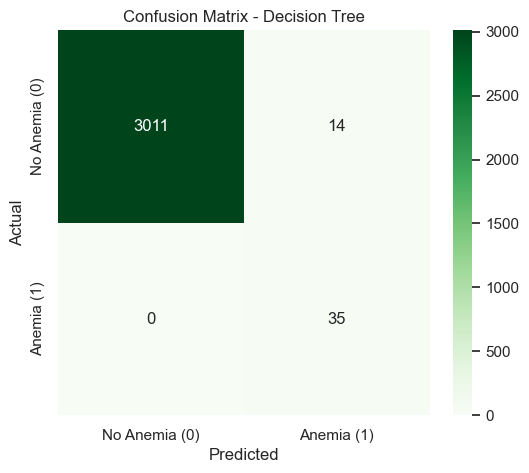


🔹 Final Results for Decision Tree Model:
🔹 Accuracy: 0.995, AUC: 0.998


In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

# Compute confusion matrix for Decision Tree
cm_dt = confusion_matrix(y_test_enc, y_pred_dt)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Anemia (0)', 'Anemia (1)'], 
            yticklabels=['No Anemia (0)', 'Anemia (1)'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

# Show the plot
plt.show()

# Compute Accuracy & AUC
accuracy_dt = accuracy_score(y_test_enc, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test_enc, y_prob_dt)  # Using probability predictions

# Display Accuracy & AUC
print(f"\n🔹 Final Results for Decision Tree Model:")
print(f"🔹 Accuracy: {accuracy_dt:.3f}, AUC: {roc_auc_dt:.3f}")


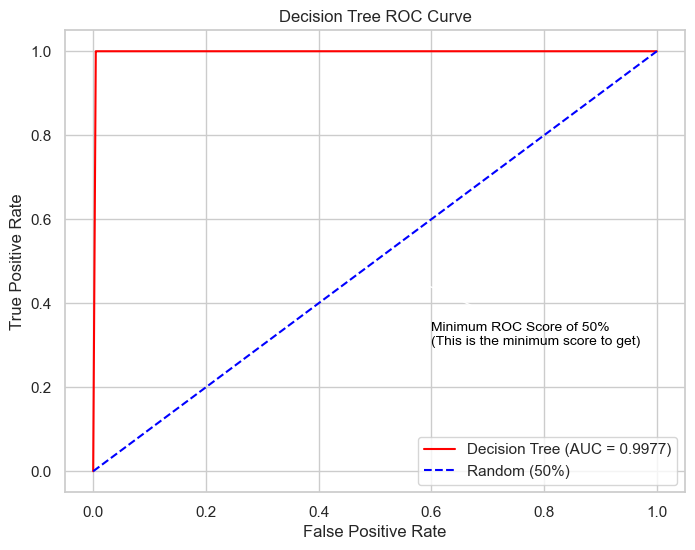

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC score for Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test_enc, y_prob_dt)  # False Positive Rate, True Positive Rate
roc_auc_dt = auc(fpr_dt, tpr_dt)  # Compute AUC

# Plot ROC Curve
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")

# ROC curve (green line for DT)
plt.plot(fpr_dt, tpr_dt, color='red', label=f'Decision Tree (AUC = {roc_auc_dt:.4f})')

# Baseline (Random Model) at 50%
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label="Random (50%)")

# Add annotation
plt.annotate("Minimum ROC Score of 50%\n(This is the minimum score to get)",
             xy=(0.5, 0.5), xytext=(0.6, 0.3),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='black')

# Labels & Title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend(loc="lower right")

# Show the plot
plt.show()


In [88]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

# Define Stratified K-Fold
k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Storage
accuracy_scores = []
auc_scores = []
classification_reports = []

for fold, (train_index, test_index) in enumerate(kf.split(X_train_fs, y_train_resampled), 1):
    # Split for this fold
    X_train_fold, X_test_fold = X_train_fs[train_index], X_train_fs[test_index]
    y_train_fold, y_test_fold = y_train_resampled[train_index], y_train_resampled[test_index]

    # Initialize and train model
    classifier_dt = DecisionTreeClassifier(class_weight='balanced', random_state=0)
    classifier_dt.fit(X_train_fold, y_train_fold)

    # Predict
    y_pred_fold = classifier_dt.predict(X_test_fold)
    y_proba_fold = classifier_dt.predict_proba(X_test_fold)[:, 1]  # Probability for class 1

    # Evaluate
    acc = accuracy_score(y_test_fold, y_pred_fold)
    auc = roc_auc_score(y_test_fold, y_proba_fold)

    accuracy_scores.append(acc)
    auc_scores.append(auc)
    classification_reports.append(classification_report(y_test_fold, y_pred_fold, output_dict=True))

    print(f"\n🌿 Fold {fold} Accuracy: {acc:.4f}")
    print(f"📈 Fold {fold} AUC: {auc:.4f}")
    print(classification_report(y_test_fold, y_pred_fold))

# Final average scores
avg_accuracy = np.mean(accuracy_scores)
avg_auc = np.mean(auc_scores)

print(f"\n✅ Average Accuracy (DT) across {k_folds} folds: {avg_accuracy:.4f}")
print(f"✅ Average AUC (DT) across {k_folds} folds: {avg_auc:.4f}")



🌿 Fold 1 Accuracy: 0.9998
📈 Fold 1 AUC: 0.9998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2416
           1       1.00      1.00      1.00      2415

    accuracy                           1.00      4831
   macro avg       1.00      1.00      1.00      4831
weighted avg       1.00      1.00      1.00      4831


🌿 Fold 2 Accuracy: 1.0000
📈 Fold 2 AUC: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2415
           1       1.00      1.00      1.00      2416

    accuracy                           1.00      4831
   macro avg       1.00      1.00      1.00      4831
weighted avg       1.00      1.00      1.00      4831


🌿 Fold 3 Accuracy: 1.0000
📈 Fold 3 AUC: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2415
           1       1.00      1.00      1.00      2415

    accuracy                          

In [81]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from scipy.stats import randint
import optuna

# ---------------- GRID SEARCH ---------------- #
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=0),
                              param_grid_dt,
                              cv=5,
                              scoring='accuracy',
                              verbose=1,
                              n_jobs=-1)

grid_search_dt.fit(X_train_fs, y_train_resampled)

best_grid_dt = grid_search_dt.best_estimator_
print("\n🔹 GridSearch Best Hyperparameters (DT):", grid_search_dt.best_params_)
print("🔹 GridSearch Best Accuracy:", grid_search_dt.best_score_)

# ---------------- RANDOM SEARCH ---------------- #
param_dist_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': randint(5, 50),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}

random_search_dt = RandomizedSearchCV(DecisionTreeClassifier(random_state=0),
                                      param_distributions=param_dist_dt,
                                      n_iter=30,  # Try 30 random combinations
                                      cv=5,
                                      scoring='accuracy',
                                      random_state=42,
                                      verbose=1,
                                      n_jobs=-1)

random_search_dt.fit(X_train_fs, y_train_resampled)

best_random_dt = random_search_dt.best_estimator_
print("\n🔹 RandomSearch Best Hyperparameters (DT):", random_search_dt.best_params_)
print("🔹 RandomSearch Best Accuracy:", random_search_dt.best_score_)

# ---------------- OPTUNA BAYESIAN OPTIMIZATION ---------------- #
def objective_dt(trial):
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    max_depth = trial.suggest_int('max_depth', 5, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    model = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, 
                                   min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, 
                                   random_state=0)

    scores = cross_val_score(model, X_train_fs, y_train_resampled, cv=5, scoring='accuracy')
    return scores.mean()

study_dt = optuna.create_study(direction='maximize')
study_dt.optimize(objective_dt, n_trials=50)

best_bayes_dt = DecisionTreeClassifier(**study_dt.best_params, random_state=0)
best_bayes_dt.fit(X_train_fs, y_train_resampled)

print("\n🔹 Bayesian Optimization Best Hyperparameters (DT):", study_dt.best_params)
print("🔹 Bayesian Optimization Best Accuracy:", study_dt.best_value)


Fitting 5 folds for each of 90 candidates, totalling 450 fits

🔹 GridSearch Best Hyperparameters (DT): {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
🔹 GridSearch Best Accuracy: 0.9998758021113641
Fitting 5 folds for each of 30 candidates, totalling 150 fits


[I 2025-04-17 16:03:32,671] A new study created in memory with name: no-name-7f992865-c907-404e-8608-82fe9d383421



🔹 RandomSearch Best Hyperparameters (DT): {'criterion': 'gini', 'max_depth': 33, 'min_samples_leaf': 8, 'min_samples_split': 8}
🔹 RandomSearch Best Accuracy: 0.9998758021113641


[I 2025-04-17 16:03:33,966] Trial 0 finished with value: 0.9997929949476573 and parameters: {'criterion': 'gini', 'max_depth': 48, 'min_samples_split': 17, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.9997929949476573.
[I 2025-04-17 16:03:34,977] Trial 1 finished with value: 0.9998758021113641 and parameters: {'criterion': 'gini', 'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 10}. Best is trial 1 with value: 0.9998758021113641.
[I 2025-04-17 16:03:35,996] Trial 2 finished with value: 0.9998758021113641 and parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 10, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.9998758021113641.
[I 2025-04-17 16:03:37,360] Trial 3 finished with value: 0.9995860070378804 and parameters: {'criterion': 'entropy', 'max_depth': 41, 'min_samples_split': 19, 'min_samples_leaf': 9}. Best is trial 1 with value: 0.9998758021113641.
[I 2025-04-17 16:03:38,708] Trial 4 finished with value: 0.9997516042227282 and param


🔹 Bayesian Optimization Best Hyperparameters (DT): {'criterion': 'gini', 'max_depth': 11, 'min_samples_split': 7, 'min_samples_leaf': 10}
🔹 Bayesian Optimization Best Accuracy: 0.9998758021113641


In [90]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score
from scipy.stats import randint
import optuna
import numpy as np

# Define outer CV
k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

results = {
    'grid': {'acc': [], 'auc': []},
    'random': {'acc': [], 'auc': []},
    'optuna': {'acc': [], 'auc': []}
}

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_fs, y_train_resampled), 1):
    print(f"\n🔁 Fold {fold}/{k_folds}")

    X_train_fold = X_train_fs[train_idx]
    y_train_fold = y_train_resampled[train_idx]
    X_val_fold = X_train_fs[val_idx]
    y_val_fold = y_train_resampled[val_idx]

    # ---------------- GRID SEARCH ---------------- #
    param_grid_dt = {
        'criterion': ['gini', 'entropy'],
        'max_depth': [3, 5, 10, 15, 20],
        'min_samples_split': [2, 5, 10]
    }

    grid_search_dt = GridSearchCV(
        DecisionTreeClassifier(class_weight='balanced', random_state=0),
        param_grid=param_grid_dt,
        cv=3,
        scoring='roc_auc',
        n_jobs=-1
    )
    grid_search_dt.fit(X_train_fold, y_train_fold)
    best_grid = grid_search_dt.best_estimator_
    y_pred_grid = best_grid.predict(X_val_fold)
    y_prob_grid = best_grid.predict_proba(X_val_fold)[:, 1]
    results['grid']['acc'].append(accuracy_score(y_val_fold, y_pred_grid))
    results['grid']['auc'].append(roc_auc_score(y_val_fold, y_prob_grid))

    # ---------------- RANDOM SEARCH ---------------- #
    param_dist_dt = {
        'criterion': ['gini', 'entropy'],
        'max_depth': randint(3, 20),
        'min_samples_split': randint(2, 20)
    }

    random_search_dt = RandomizedSearchCV(
        DecisionTreeClassifier(class_weight='balanced', random_state=0),
        param_distributions=param_dist_dt,
        n_iter=15,
        cv=3,
        scoring='roc_auc',
        n_jobs=-1,
        random_state=42
    )
    random_search_dt.fit(X_train_fold, y_train_fold)
    best_random = random_search_dt.best_estimator_
    y_pred_rand = best_random.predict(X_val_fold)
    y_prob_rand = best_random.predict_proba(X_val_fold)[:, 1]
    results['random']['acc'].append(accuracy_score(y_val_fold, y_pred_rand))
    results['random']['auc'].append(roc_auc_score(y_val_fold, y_prob_rand))

    # ---------------- OPTUNA BAYESIAN OPTIMIZATION ---------------- #
    def objective_dt(trial):
        criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])
        max_depth = trial.suggest_int("max_depth", 3, 20)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)

        model = DecisionTreeClassifier(
            criterion=criterion,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            class_weight='balanced',
            random_state=0
        )
        return cross_val_score(model, X_train_fold, y_train_fold, cv=3, scoring='roc_auc').mean()

    study_dt = optuna.create_study(direction='maximize')
    study_dt.optimize(objective_dt, n_trials=20, show_progress_bar=False)

    best_bayes = DecisionTreeClassifier(
        **study_dt.best_params,
        class_weight='balanced',
        random_state=0
    )
    best_bayes.fit(X_train_fold, y_train_fold)
    y_pred_bayes = best_bayes.predict(X_val_fold)
    y_prob_bayes = best_bayes.predict_proba(X_val_fold)[:, 1]
    results['optuna']['acc'].append(accuracy_score(y_val_fold, y_pred_bayes))
    results['optuna']['auc'].append(roc_auc_score(y_val_fold, y_prob_bayes))

# ---------------- SUMMARY ---------------- #
print("\n✅ Final Cross-Validated Results (Decision Tree):")
for method in results:
    avg_acc = np.mean(results[method]['acc'])
    avg_auc = np.mean(results[method]['auc'])
    print(f"📌 {method.upper():<10} | Accuracy: {avg_acc:.4f} | AUC: {avg_auc:.4f}")



🔁 Fold 1/5


[I 2025-04-18 17:31:42,396] A new study created in memory with name: no-name-7736f5d3-b6ec-44ea-85a2-75d4e02cd55e
[I 2025-04-18 17:31:42,740] Trial 0 finished with value: 0.9941511708553405 and parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 4}. Best is trial 0 with value: 0.9941511708553405.
[I 2025-04-18 17:31:43,347] Trial 1 finished with value: 0.9998965124702472 and parameters: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 17}. Best is trial 1 with value: 0.9998965124702472.
[I 2025-04-18 17:31:43,934] Trial 2 finished with value: 0.9998964963957646 and parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 19}. Best is trial 1 with value: 0.9998965124702472.
[I 2025-04-18 17:31:44,555] Trial 3 finished with value: 0.9998965124702472 and parameters: {'criterion': 'entropy', 'max_depth': 19, 'min_samples_split': 4}. Best is trial 1 with value: 0.9998965124702472.
[I 2025-04-18 17:31:45,119] Trial 4 finished with value: 0.99


🔁 Fold 2/5


[I 2025-04-18 17:31:58,746] A new study created in memory with name: no-name-db2fe290-6b0f-4961-bb94-9deffd5b06a9
[I 2025-04-18 17:31:59,406] Trial 0 finished with value: 0.9998956929261453 and parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_split': 19}. Best is trial 0 with value: 0.9998956929261453.
[I 2025-04-18 17:32:00,063] Trial 1 finished with value: 0.9996894409937888 and parameters: {'criterion': 'entropy', 'max_depth': 19, 'min_samples_split': 8}. Best is trial 0 with value: 0.9998956929261453.
[I 2025-04-18 17:32:00,578] Trial 2 finished with value: 0.996737121748258 and parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 7}. Best is trial 0 with value: 0.9998956929261453.
[I 2025-04-18 17:32:01,241] Trial 3 finished with value: 0.9996894409937888 and parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_split': 17}. Best is trial 0 with value: 0.9998956929261453.
[I 2025-04-18 17:32:01,759] Trial 4 finished with value: 0.9


🔁 Fold 3/5


...


🔁 Fold 4/5


[I 2025-04-18 17:32:34,761] A new study created in memory with name: no-name-4e5788b4-a2dc-4553-822a-a3fd28bef34b
[I 2025-04-18 17:32:35,414] Trial 0 finished with value: 0.9997930088710024 and parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 10}. Best is trial 0 with value: 0.9997930088710024.
[I 2025-04-18 17:32:36,074] Trial 1 finished with value: 0.9997928963795667 and parameters: {'criterion': 'gini', 'max_depth': 13, 'min_samples_split': 12}. Best is trial 0 with value: 0.9997930088710024.
[I 2025-04-18 17:32:36,746] Trial 2 finished with value: 0.9997930088710024 and parameters: {'criterion': 'entropy', 'max_depth': 11, 'min_samples_split': 9}. Best is trial 0 with value: 0.9997930088710024.
[I 2025-04-18 17:32:37,388] Trial 3 finished with value: 0.9997930088710024 and parameters: {'criterion': 'entropy', 'max_depth': 15, 'min_samples_split': 3}. Best is trial 0 with value: 0.9997930088710024.
[I 2025-04-18 17:32:37,668] Trial 4 finished with value: 0.


🔁 Fold 5/5


[I 2025-04-18 17:32:52,233] A new study created in memory with name: no-name-570b55f9-92a2-42a3-aa84-7ec6ed759e2b
[I 2025-04-18 17:32:52,797] Trial 0 finished with value: 0.9971148673013474 and parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 18}. Best is trial 0 with value: 0.9971148673013474.
[I 2025-04-18 17:32:53,466] Trial 1 finished with value: 0.9998447365663866 and parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 20}. Best is trial 1 with value: 0.9998447365663866.
[I 2025-04-18 17:32:54,079] Trial 2 finished with value: 0.999352678225211 and parameters: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_split': 4}. Best is trial 1 with value: 0.9998447365663866.
[I 2025-04-18 17:32:54,752] Trial 3 finished with value: 0.9997929445830526 and parameters: {'criterion': 'gini', 'max_depth': 19, 'min_samples_split': 9}. Best is trial 1 with value: 0.9998447365663866.
[I 2025-04-18 17:32:55,433] Trial 4 finished with value: 0.999


✅ Final Cross-Validated Results (Decision Tree):
📌 GRID       | Accuracy: 0.9999 | AUC: 0.9999
📌 RANDOM     | Accuracy: 0.9999 | AUC: 1.0000
📌 OPTUNA     | Accuracy: 1.0000 | AUC: 1.0000


## SVM

In [104]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
classifier_svm = SVC(kernel='rbf', class_weight="balanced", probability=True, random_state=0)
classifier_svm.fit(X_train_fs, y_train_resampled)
y_pred_svm = classifier_svm.predict(X_test_fs)
print("🔹 Classification Report of SVM:")
print(classification_report(y_test_enc, y_pred_svm))

🔹 Classification Report of SVM:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3025
           1       0.36      0.89      0.51        35

    accuracy                           0.98      3060
   macro avg       0.68      0.93      0.75      3060
weighted avg       0.99      0.98      0.98      3060



In [105]:
#Predict
y_pred_svm = classifier_svm.predict(X_test_fs)
results_df = pd.DataFrame({
    'Predicted': y_pred_svm,
    'Actual': y_test_enc
})
#Print
y_prob_svm = classifier_svm.predict_proba(X_test_fs)[:, 1] # Probability of class 1
results_df['Probability'] = y_prob_svm
results_df['Probability'] = results_df['Probability'].round(4)
print(results_df)

      Predicted  Actual  Probability
0             0       0          0.0
1             0       0          0.0
2             0       0          0.0
3             0       0          0.0
4             0       0          0.0
...         ...     ...          ...
3055          0       0          0.0
3056          0       0          0.0
3057          0       0          0.0
3058          0       0          0.0
3059          0       0          0.0

[3060 rows x 3 columns]


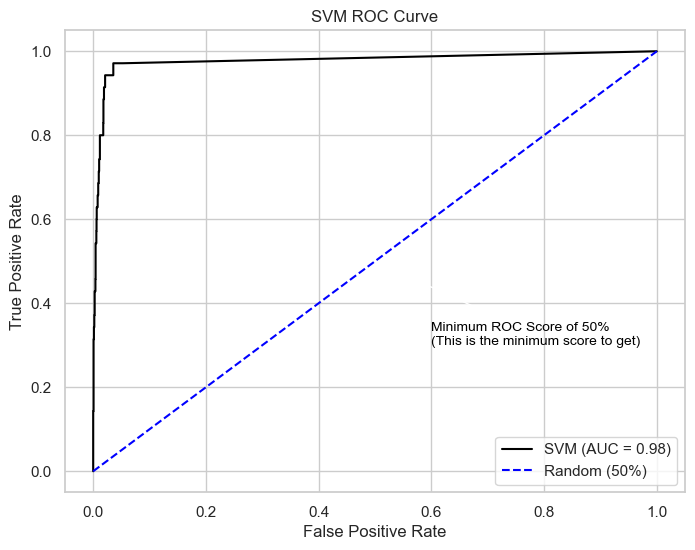

In [106]:
from sklearn.metrics import auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Compute ROC curve and AUC score
fpr_svm, tpr_svm, _ = roc_curve(y_test_enc, y_prob_svm)  # False Positive Rate, True Positive Rate
roc_auc = auc(fpr_svm, tpr_svm)  # Compute AUC

#Plot ROC Curve
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")

# ROCcurve(orange line)
plt.plot(fpr_svm, tpr_svm, color='black', label=f'SVM (AUC = {roc_auc:.2f})')

# Baseline(Random Model) at 50%
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label="Random (50%)")  

# Add annotation
plt.annotate("Minimum ROC Score of 50%\n(This is the minimum score to get)",
             xy=(0.5, 0.5), xytext=(0.6, 0.3),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='black')

# Labels & Title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend(loc="lower right")

# Show the plot
plt.show()

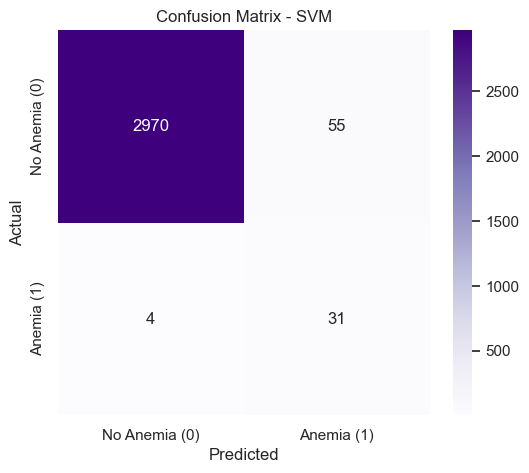


🔹 Final Results for Support Vector Machine Model:
🔹 Accuracy: 0.981, AUC: 0.978


In [106]:
#Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test_enc, y_pred_svm)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Purples', 
            xticklabels = ['No Anemia (0)', 'Anemia (1)'], 
            yticklabels = ['No Anemia (0)', 'Anemia (1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()
# Compute Accuracy & AUC
accuracy_svm = accuracy_score(y_test_enc, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test_enc, y_prob_svm)  # Using probability predictions

# Display Accuracy & AUC
print(f"\n🔹 Final Results for Support Vector Machine Model:")
print(f"🔹 Accuracy: {accuracy_svm:.3f}, AUC: {roc_auc_svm:.3f}")

In [108]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

# Stratified K-Fold setup
k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Storage for metrics
accuracy_scores = []
auc_scores = []
classification_reports = []

for fold, (train_index, test_index) in enumerate(kf.split(X_train_fs, y_train_resampled), 1):
    # Split data
    X_train_fold, X_test_fold = X_train_fs[train_index], X_train_fs[test_index]
    y_train_fold, y_test_fold = y_train_resampled[train_index], y_train_resampled[test_index]

    # Initialize and train model
    classifier_svm = SVC(probability=True, kernel='rbf', class_weight='balanced', random_state=0)
    classifier_svm.fit(X_train_fold, y_train_fold)

    # Predict
    y_pred_fold = classifier_svm.predict(X_test_fold)
    y_proba_fold = classifier_svm.predict_proba(X_test_fold)[:, 1]  # Probability for class 1

    # Evaluate
    acc = accuracy_score(y_test_fold, y_pred_fold)
    auc = roc_auc_score(y_test_fold, y_proba_fold)

    accuracy_scores.append(acc)
    auc_scores.append(auc)
    classification_reports.append(classification_report(y_test_fold, y_pred_fold, output_dict=True))

    print(f"\n🌀 Fold {fold} Accuracy: {acc:.4f}")
    print(f"📈 Fold {fold} AUC: {auc:.4f}")
    print(classification_report(y_test_fold, y_pred_fold))

# Final averaged results
avg_accuracy = np.mean(accuracy_scores)
avg_auc = np.mean(auc_scores)

print(f"\n✅ Average Accuracy (SVM) across {k_folds} folds: {avg_accuracy:.4f}")
print(f"✅ Average AUC (SVM) across {k_folds} folds: {avg_auc:.4f}")



🌀 Fold 1 Accuracy: 0.9880
📈 Fold 1 AUC: 0.9992
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2416
           1       0.98      1.00      0.99      2415

    accuracy                           0.99      4831
   macro avg       0.99      0.99      0.99      4831
weighted avg       0.99      0.99      0.99      4831


🌀 Fold 2 Accuracy: 0.9899
📈 Fold 2 AUC: 0.9994
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2415
           1       0.98      1.00      0.99      2416

    accuracy                           0.99      4831
   macro avg       0.99      0.99      0.99      4831
weighted avg       0.99      0.99      0.99      4831


🌀 Fold 3 Accuracy: 0.9892
📈 Fold 3 AUC: 0.9993
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2415
           1       0.98      1.00      0.99      2415

    accuracy                          

In [104]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from scipy.stats import loguniform
import optuna

# ---------------- GRID SEARCH ---------------- #
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale']
}

grid_search_svm = GridSearchCV(
    SVC(class_weight='balanced', random_state=0),
    param_grid=param_grid_svm,
    cv=3,  # faster
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid_search_svm.fit(X_train_fs, y_train_resampled)

best_grid_svm = grid_search_svm.best_estimator_
print("\n🔹 GridSearch Best Hyperparameters (SVM):", grid_search_svm.best_params_)
print("🔹 GridSearch Best Accuracy:", grid_search_svm.best_score_)

# ---------------- RANDOM SEARCH ---------------- #
param_dist_svm = {
    'C': loguniform(0.001, 100),
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale']
}

random_search_svm = RandomizedSearchCV(
    SVC(class_weight='balanced', random_state=0),
    param_distributions=param_dist_svm,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    verbose=1,
    n_jobs=-1
)
random_search_svm.fit(X_train_fs, y_train_resampled)

best_random_svm = random_search_svm.best_estimator_
print("\n🔹 RandomSearch Best Hyperparameters (SVM):", random_search_svm.best_params_)
print("🔹 RandomSearch Best Accuracy:", random_search_svm.best_score_)

# ---------------- OPTUNA BAYESIAN OPTIMIZATION ---------------- #
def objective_svm(trial):
    C = trial.suggest_float('C', 0.001, 100, log=True)
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf'])
    gamma = trial.suggest_categorical('gamma', ['scale'])

    model = SVC(C=C, kernel=kernel, gamma=gamma, class_weight='balanced', random_state=0)
    scores = cross_val_score(model, X_train_fs, y_train_resampled, cv=3, scoring='accuracy')
    return scores.mean()

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=20)

best_bayes_svm = SVC(**study_svm.best_params, class_weight='balanced', random_state=0)
best_bayes_svm.fit(X_train_fs, y_train_resampled)

print("\n🔹 Bayesian Optimization Best Hyperparameters (SVM):", study_svm.best_params)
print("🔹 Bayesian Optimization Best Accuracy:", study_svm.best_value)


Fitting 3 folds for each of 6 candidates, totalling 18 fits

🔹 GridSearch Best Hyperparameters (SVM): {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
🔹 GridSearch Best Accuracy: 0.9943276570455479
Fitting 3 folds for each of 10 candidates, totalling 30 fits


[I 2025-04-17 16:21:24,059] A new study created in memory with name: no-name-ba6857d5-7a73-440c-a55d-6b876e055d08



🔹 RandomSearch Best Hyperparameters (SVM): {'C': 14.528246637516036, 'gamma': 'scale', 'kernel': 'rbf'}
🔹 RandomSearch Best Accuracy: 0.9952385375529138


[I 2025-04-17 16:21:37,969] Trial 0 finished with value: 0.9758199089500089 and parameters: {'C': 0.23675421062448793, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.9758199089500089.
[I 2025-04-17 16:21:51,196] Trial 1 finished with value: 0.9277906914846424 and parameters: {'C': 0.0057763411128306874, 'kernel': 'linear', 'gamma': 'scale'}. Best is trial 0 with value: 0.9758199089500089.
[I 2025-04-17 16:21:55,374] Trial 2 finished with value: 0.9936651928839776 and parameters: {'C': 6.675136890661223, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 2 with value: 0.9936651928839776.
[I 2025-04-17 16:22:31,824] Trial 3 finished with value: 0.9264244375851359 and parameters: {'C': 0.011714164160481055, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 2 with value: 0.9936651928839776.
[I 2025-04-17 16:22:36,996] Trial 4 finished with value: 0.9920090067640737 and parameters: {'C': 3.26846086471671, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 2 with value: 0.99


🔹 Bayesian Optimization Best Hyperparameters (SVM): {'C': 74.95187378600276, 'kernel': 'rbf', 'gamma': 'scale'}
🔹 Bayesian Optimization Best Accuracy: 0.9963564522545583


In [129]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score
from scipy.stats import uniform
import optuna
import numpy as np

# Outer CV
k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

results = {
    'grid': {'acc': [], 'auc': []},
    'random': {'acc': [], 'auc': []},
    'optuna': {'acc': [], 'auc': []}
}

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_fs, y_train_resampled), 1):
    print(f"\n🔁 Fold {fold}/{k_folds}")

    X_train_fold = X_train_fs[train_idx]
    y_train_fold = y_train_resampled[train_idx]
    X_val_fold = X_train_fs[val_idx]
    y_val_fold = y_train_resampled[val_idx]

    # ---------------- GRID SEARCH ---------------- #
param_grid_svm = {
    'C': [0.1, 1],           # Fewer values
    'kernel': ['rbf'],       # Best-performing kernel
    'gamma': ['scale']       # Fixed gamma
}

grid_search_svm = GridSearchCV(
    estimator=SVC(probability=True, random_state=0),
    param_grid=param_grid_svm,
    cv=2,                      # Faster CV
    scoring='roc_auc',
    refit=True,
    n_jobs=-1,
    verbose=0
)
grid_search_svm.fit(X_train_fold, y_train_fold)
best_grid = grid_search_svm.best_estimator_
y_pred_grid = best_grid.predict(X_val_fold)
y_prob_grid = best_grid.predict_proba(X_val_fold)[:, 1]
results['grid']['acc'].append(accuracy_score(y_val_fold, y_pred_grid))
results['grid']['auc'].append(roc_auc_score(y_val_fold, y_prob_grid))

    # ---------------- RANDOM SEARCH ---------------- #
param_dist_svm = {
    'C': uniform(0.1, 10),       # Narrower range
    'kernel': ['rbf'],           # Drop 'linear', 'poly'
    'gamma': ['scale']
}

random_search_svm = RandomizedSearchCV(
    estimator=SVC(probability=True, random_state=0),
    param_distributions=param_dist_svm,
    n_iter=3,                   # 🔻 Down from 5
    cv=2,                       # 🔻 CV folds
    scoring='roc_auc',
    refit=True,
    random_state=42,
    n_jobs=-1
)
random_search_svm.fit(X_train_fold, y_train_fold)
best_random = random_search_svm.best_estimator_
y_pred_rand = best_random.predict(X_val_fold)
y_prob_rand = best_random.predict_proba(X_val_fold)[:, 1]
results['random']['acc'].append(accuracy_score(y_val_fold, y_pred_rand))
results['random']['auc'].append(roc_auc_score(y_val_fold, y_prob_rand))

    # ---------------- OPTUNA (Bayesian Optimization) ---------------- #
def objective_svm(trial):
    C = trial.suggest_float('C', 0.1, 10, log=True)
    kernel = 'rbf'  # Fixed to reduce time
    gamma = 'scale'

    model = SVC(C=C, kernel=kernel, gamma=gamma, probability=True, random_state=0)
    return cross_val_score(model, X_train_fold, y_train_fold, cv=2, scoring='roc_auc').mean()

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10, show_progress_bar=False)

best_bayes = SVC(**study_svm.best_params, probability=True, random_state=0)
best_bayes.fit(X_train_fold, y_train_fold)
y_pred_bayes = best_bayes.predict(X_val_fold)
y_prob_bayes = best_bayes.predict_proba(X_val_fold)[:, 1]
results['optuna']['acc'].append(accuracy_score(y_val_fold, y_pred_bayes))
results['optuna']['auc'].append(roc_auc_score(y_val_fold, y_prob_bayes))


# ---------------- SUMMARY ---------------- #
print("\n✅ Final Cross-Validated Results (SVM):")
for method in results:
    avg_acc = np.mean(results[method]['acc'])
    avg_auc = np.mean(results[method]['auc'])
    print(f"📌 {method.upper():<10} | Accuracy: {avg_acc:.4f} | AUC: {avg_auc:.4f}")



🔁 Fold 1/5

🔁 Fold 2/5

🔁 Fold 3/5

🔁 Fold 4/5

🔁 Fold 5/5


[I 2025-04-18 17:52:23,899] A new study created in memory with name: no-name-0d31b2a7-c398-42e9-bd4d-c8edd67620c6
[I 2025-04-18 17:52:33,211] Trial 0 finished with value: 0.9982793578223457 and parameters: {'C': 0.8958118143199448}. Best is trial 0 with value: 0.9982793578223457.
[I 2025-04-18 17:52:52,569] Trial 1 finished with value: 0.9901678385753157 and parameters: {'C': 0.11576565150179222}. Best is trial 0 with value: 0.9982793578223457.
[I 2025-04-18 17:53:03,533] Trial 2 finished with value: 0.9975208207174764 and parameters: {'C': 0.6081389567713543}. Best is trial 0 with value: 0.9982793578223457.
[I 2025-04-18 17:53:10,239] Trial 3 finished with value: 0.9990828941622278 and parameters: {'C': 2.7515220304427683}. Best is trial 3 with value: 0.9990828941622278.
[I 2025-04-18 17:53:16,831] Trial 4 finished with value: 0.999103486669298 and parameters: {'C': 3.040780095468982}. Best is trial 4 with value: 0.999103486669298.
[I 2025-04-18 17:53:30,530] Trial 5 finished with val


✅ Final Cross-Validated Results (SVM):
📌 GRID       | Accuracy: 0.9880 | AUC: 0.9979
📌 RANDOM     | Accuracy: 0.9917 | AUC: 0.9987
📌 OPTUNA     | Accuracy: 0.9913 | AUC: 0.9987


## ANN


In [107]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Convert selected features into PyTorch tensors
X_train_tensor = torch.tensor(X_train_fs, dtype=torch.double)
y_train_tensor = torch.tensor(y_train_resampled, dtype=torch.double).view(-1, 1)
X_test_tensor = torch.tensor(X_test_fs, dtype=torch.double)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.double).view(-1, 1)


In [108]:
# Define ANN architecture
class ANNModel(nn.Module):
    def __init__(self, input_size):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 16, dtype=torch.double)  # Hidden layer with 16 neurons
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1, dtype=torch.double)  # Output layer (binary classification)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# Initialize the model
input_size = X_train_fs.shape[1]
model = ANNModel(input_size)

# Define loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

print("Training complete!")


Epoch [10/100], Loss: 0.6975
Epoch [20/100], Loss: 0.6687
Epoch [30/100], Loss: 0.6430
Epoch [40/100], Loss: 0.6190
Epoch [50/100], Loss: 0.5960
Epoch [60/100], Loss: 0.5735
Epoch [70/100], Loss: 0.5510
Epoch [80/100], Loss: 0.5285
Epoch [90/100], Loss: 0.5061
Epoch [100/100], Loss: 0.4840
Training complete!


In [109]:
# Evaluate the model
with torch.no_grad():
    y_test_pred = model(X_test_tensor)
    y_test_pred_label = (y_test_pred > 0.5).float()

# Convert to numpy for sklearn metrics (ensure on CPU!)
y_test_pred_label_np = y_test_pred_label.cpu().numpy()
y_test_pred_prob_np = y_test_pred.cpu().numpy()
y_test_np = y_test_tensor.cpu().numpy()

# Calculate accuracy and AUC
acc = accuracy_score(y_test_np, y_test_pred_label_np)
auc = roc_auc_score(y_test_np, y_test_pred_prob_np)
# Display classification report
print("\n🔹Classification Report of ANN:")
print(classification_report(y_test_np, y_test_pred_label_np))

# Display final accuracy and AUC
print("\n🔹Final Results for ANN Model:")
print(f"Accuracy: {acc:.3f}, AUC: {auc:.3f}")




🔹Classification Report of ANN:
              precision    recall  f1-score   support

         0.0       1.00      0.75      0.86      3025
         1.0       0.04      0.94      0.08        35

    accuracy                           0.75      3060
   macro avg       0.52      0.85      0.47      3060
weighted avg       0.99      0.75      0.85      3060


🔹Final Results for ANN Model:
Accuracy: 0.752, AUC: 0.922


In [110]:
# Predict with ANN
with torch.no_grad():
    y_pred_ann_tensor = model(X_test_tensor)  # Get raw output (logits)
    y_pred_ann_label = (y_pred_ann_tensor > 0.5).float()  # Convert to binary (0 or 1)

# Convert to NumPy for DataFrame output
y_pred_ann_np = y_pred_ann_label.numpy()
y_prob_ann_np = y_pred_ann_tensor.numpy()  # Probabilities

# Store predictions in a DataFrame like LR
results_ann_df = pd.DataFrame({
    'Predicted': y_pred_ann_np.flatten(),
    'Actual': y_test_enc.flatten(),
    'Probability': y_prob_ann_np.flatten()
})

# Round probability values like LR
results_ann_df['Probability'] = results_ann_df['Probability'].round(4)

# Print first 20 rows
print(results_ann_df.head(20))


    Predicted  Actual  Probability
0         0.0       0       0.3533
1         0.0       0       0.0118
2         0.0       0       0.1990
3         0.0       0       0.4056
4         1.0       0       0.7131
5         0.0       0       0.2361
6         0.0       0       0.3216
7         0.0       0       0.3606
8         0.0       0       0.3000
9         0.0       0       0.4926
10        0.0       0       0.4099
11        0.0       0       0.3553
12        1.0       0       0.6498
13        0.0       0       0.2956
14        0.0       0       0.3179
15        0.0       0       0.3762
16        0.0       0       0.4828
17        0.0       0       0.4768
18        1.0       0       0.5749
19        0.0       0       0.4074


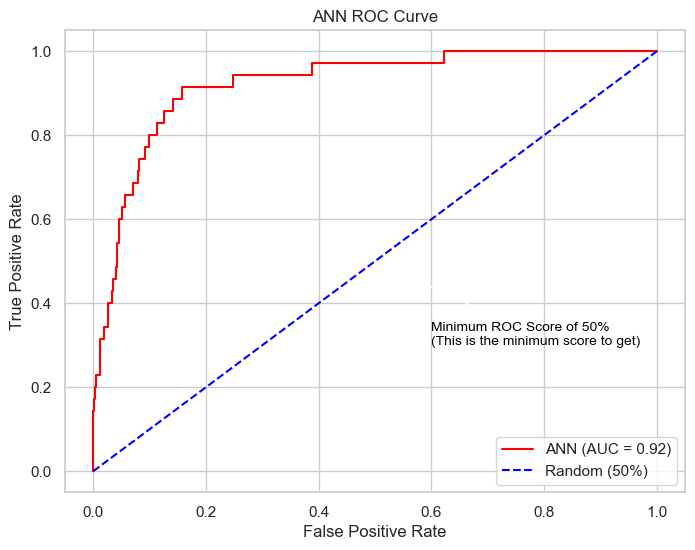

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
# Compute ROC curve and AUC score
fpr_ann, tpr_ann, _ = roc_curve(y_test_np, y_test_pred_prob_np)
roc_auc = auc(fpr_ann, tpr_ann)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")

# ROC curve
plt.plot(fpr_ann, tpr_ann, color='Red', label=f'ANN (AUC = {roc_auc:.2f})')

# Baseline (Random Model) at 50%
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label="Random (50%)")  

# Add annotation
plt.annotate("Minimum ROC Score of 50%\n(This is the minimum score to get)",
             xy=(0.5, 0.5), xytext=(0.6, 0.3),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='black')

# Labels & Title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ANN ROC Curve")
plt.legend(loc="lower right")

# Show the plot
plt.show()


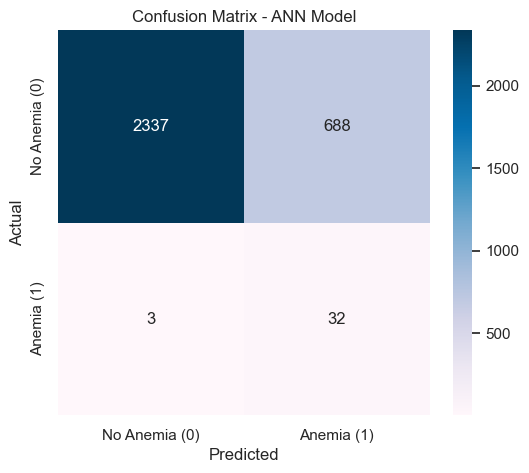


🔹Final Results for ANN Model:
Accuracy: 0.774, AUC: 0.908


In [172]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
# Compute confusion matrix
cm_ann = confusion_matrix(y_test_np, y_test_pred_label_np)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='PuBu',
            xticklabels=['No Anemia (0)', 'Anemia (1)'],
            yticklabels=['No Anemia (0)', 'Anemia (1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ANN Model")
plt.show()

# Calculate accuracy and AUC
acc = accuracy_score(y_test_np, y_test_pred_label_np)
auc = roc_auc_score(y_test_np, y_test_pred_prob_np)

# Display final accuracy and AUC
print("\n🔹Final Results for ANN Model:")
print(f"Accuracy: {acc:.3f}, AUC: {auc:.3f}")

In [79]:
from sklearn.metrics import roc_auc_score

# Additional score list
auc_scores = []

for train_index, test_index in kf.split(X_train_fs, y_train_resampled):
    # Split data
    X_train_fold, X_test_fold = X_train_fs[train_index], X_train_fs[test_index]
    y_train_fold, y_test_fold = y_train_resampled[train_index], y_train_resampled[test_index]

    # Tensors
    X_train_tensor = torch.tensor(X_train_fold, dtype=torch.double)
    y_train_tensor = torch.tensor(y_train_fold, dtype=torch.double).view(-1, 1)
    X_test_tensor = torch.tensor(X_test_fold, dtype=torch.double)
    y_test_tensor = torch.tensor(y_test_fold, dtype=torch.double).view(-1, 1)

    # Model
    input_size = X_train_tensor.shape[1]
    model = ANNModel(input_size)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Train
    for epoch in range(100):
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

    # Predict
    with torch.no_grad():
        y_pred_probs = model(X_test_tensor)               # 💡 Keep as raw sigmoid output
        y_pred_labels = (y_pred_probs > 0.5).float()

    # Convert to NumPy
    y_true = y_test_tensor.numpy()
    y_labels = y_pred_labels.numpy()
    y_probs = y_pred_probs.numpy()

    # Metrics
    acc = accuracy_score(y_true, y_labels)
    auc = roc_auc_score(y_true, y_probs)

    accuracy_scores.append(acc)
    auc_scores.append(auc)
    classification_reports.append(classification_report(y_true, y_labels, output_dict=True))

    print(f"📘 Fold Accuracy: {acc:.4f}")
    print(f"📈 Fold AUC: {auc:.4f}")
    print(classification_report(y_true, y_labels))

# Final results
avg_accuracy = np.mean(accuracy_scores)
avg_auc = np.mean(auc_scores)

print(f"\n✅ Average Accuracy (ANN) across {k_folds} folds: {avg_accuracy:.4f}")
print(f"✅ Average AUC (ANN) across {k_folds} folds: {avg_auc:.4f}")


📘 Fold Accuracy: 0.8402
📈 Fold AUC: 0.9107
              precision    recall  f1-score   support

         0.0       0.92      0.74      0.82      2416
         1.0       0.78      0.94      0.85      2415

    accuracy                           0.84      4831
   macro avg       0.85      0.84      0.84      4831
weighted avg       0.85      0.84      0.84      4831

📘 Fold Accuracy: 0.8416
📈 Fold AUC: 0.9126
              precision    recall  f1-score   support

         0.0       0.92      0.75      0.83      2415
         1.0       0.79      0.93      0.85      2416

    accuracy                           0.84      4831
   macro avg       0.85      0.84      0.84      4831
weighted avg       0.85      0.84      0.84      4831

📘 Fold Accuracy: 0.8391
📈 Fold AUC: 0.9137
              precision    recall  f1-score   support

         0.0       0.89      0.77      0.83      2415
         1.0       0.80      0.90      0.85      2415

    accuracy                           0.84      4830

In [176]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, KFold
from scipy.stats import randint, uniform
import optuna
from sklearn.metrics import roc_auc_score, accuracy_score

# ---------------- DEFINE ANN MODEL ---------------- #
def evaluate_model_with_kfold(model_class, input_size, hidden_size, activation_fn, lr, X, y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    aucs = []
    accs = []

    for train_index, val_index in kf.split(X):
        X_train_fold = torch.tensor(X[train_index], dtype=torch.double)
        y_train_fold = torch.tensor(y[train_index], dtype=torch.double).view(-1, 1)
        X_val_fold = torch.tensor(X[val_index], dtype=torch.double)
        y_val_fold = torch.tensor(y[val_index], dtype=torch.double).view(-1, 1)

        model = model_class(input_size, hidden_size, activation_fn)
        criterion = nn.BCELoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        for epoch in range(50):
            model.train()
            optimizer.zero_grad()
            output = model(X_train_fold)
            loss = criterion(output, y_train_fold)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            preds = model(X_val_fold)
            pred_labels = (preds > 0.5).float()

            auc = roc_auc_score(y_val_fold.numpy(), preds.numpy())
            acc = accuracy_score(y_val_fold.numpy(), pred_labels.numpy())

        aucs.append(auc)
        accs.append(acc)

    return np.mean(accs), np.mean(aucs)

class ANNModel(nn.Module):
    def __init__(self, input_size, hidden_size, activation_fn):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size, dtype=torch.double)
        self.activation = activation_fn
        self.fc2 = nn.Linear(hidden_size, 1, dtype=torch.double)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# Convert dataset to PyTorch tensors
X_train_tensor = torch.tensor(X_train_fs, dtype=torch.double)
y_train_tensor = torch.tensor(y_train_resampled, dtype=torch.double).view(-1, 1)
X_test_tensor = torch.tensor(X_test_fs, dtype=torch.double)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.double).view(-1, 1)

input_size = X_train_fs.shape[1]  # Number of features

# ---------------- GRID SEARCH ---------------- #
grid_params = {
    'hidden_size': [8, 16, 32, 64],
    'activation_fn': [nn.ReLU(), nn.Tanh(), nn.Sigmoid()],
    'learning_rate': [0.001, 0.01, 0.1],
}

best_acc = 0
best_grid_model = None
best_grid_params = {}

for hidden_size in grid_params['hidden_size']:
    for activation_fn in grid_params['activation_fn']:
        for lr in grid_params['learning_rate']:
            model = ANNModel(input_size, hidden_size, activation_fn)
            criterion = nn.BCELoss()
            optimizer = optim.Adam(model.parameters(), lr=lr)
            
            # Train model
            epochs = 50
            for epoch in range(epochs):
                optimizer.zero_grad()
                outputs = model(X_train_tensor)
                loss = criterion(outputs, y_train_tensor)
                loss.backward()
                optimizer.step()

            # Evaluate
            with torch.no_grad():
                y_test_pred = model(X_test_tensor)
                y_test_pred_label = (y_test_pred > 0.5).float()
            acc = accuracy_score(y_test_tensor.numpy(), y_test_pred_label.numpy())
            
            if acc > best_acc:
                best_acc = acc
                best_grid_model = model
                best_grid_params = {'hidden_size': hidden_size, 'activation_fn': activation_fn, 'learning_rate': lr}

print("\n🔹 Grid Search Best Hyperparameters (ANN):", best_grid_params)
print("🔹 Grid Search Best Accuracy:", best_acc)
best_acc = 0
best_auc = 0
for hidden_size in grid_params['hidden_size']:
    for activation_fn in grid_params['activation_fn']:
        for lr in grid_params['learning_rate']:
            acc, auc = evaluate_model_with_kfold(ANNModel, input_size, hidden_size, activation_fn, lr, X_train_fs, y_train_resampled)
            if acc > best_acc:
                best_acc = acc
                best_auc = auc
                best_grid_params = {'hidden_size': hidden_size, 'activation_fn': activation_fn, 'learning_rate': lr}

print("\n🔹 Grid Search Best Hyperparameters:", best_grid_params)
print("🔹 Grid Search Best Accuracy:", best_acc)
print("🔹 Grid Search Best AUC:", best_auc)
# ---------------- RANDOMIZED SEARCH ---------------- #
random_params = {
    'hidden_size': randint(8, 128),
    'activation_fn': [nn.ReLU(), nn.Tanh(), nn.Sigmoid()],
    'learning_rate': uniform(0.0001, 0.1),
}

best_random_acc = 0
best_random_model = None
best_random_params = {}

for _ in range(20):  # 20 random trials
    hidden_size = random_params['hidden_size'].rvs()
    activation_fn = np.random.choice(random_params['activation_fn'])
    lr = random_params['learning_rate'].rvs()
    
    model = ANNModel(input_size, hidden_size, activation_fn)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train model
    for epoch in range(50):
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

    # Evaluate
    with torch.no_grad():
        y_test_pred = model(X_test_tensor)
        y_test_pred_label = (y_test_pred > 0.5).float()
    acc = accuracy_score(y_test_tensor.numpy(), y_test_pred_label.numpy())

    if acc > best_random_acc:
        best_random_acc = acc
        best_random_model = model
        best_random_params = {'hidden_size': hidden_size, 'activation_fn': activation_fn, 'learning_rate': lr}

print("\n🔹 Random Search Best Hyperparameters (ANN):", best_random_params)
print("🔹 Random Search Best Accuracy:", best_random_acc)
for _ in range(20):
    hidden_size = random_params['hidden_size'].rvs()
    activation_fn = np.random.choice(random_params['activation_fn'])
    lr = random_params['learning_rate'].rvs()

    acc, auc = evaluate_model_with_kfold(ANNModel, input_size, hidden_size, activation_fn, lr, X_train_fs, y_train_resampled)
    if acc > best_random_acc:
        best_random_acc = acc
        best_random_auc = auc
        best_random_params = {'hidden_size': hidden_size, 'activation_fn': activation_fn, 'learning_rate': lr}

print("\n🔹 Random Search Best Hyperparameters:", best_random_params)
print("🔹 Random Search Best Accuracy:", best_random_acc)
print("🔹 Random Search Best AUC:", best_random_auc)

# ---------------- OPTUNA BAYESIAN OPTIMIZATION ---------------- #
def objective_ann(trial):
    hidden_size = trial.suggest_int('hidden_size', 8, 128)
    activation_fn_name = trial.suggest_categorical('activation_fn', ['ReLU', 'Tanh', 'Sigmoid'])
    lr = trial.suggest_float('learning_rate', 0.0001, 0.1, log=True)
    
    # Map string to PyTorch activation function
    activation_fn = {
        'ReLU': nn.ReLU(),
        'Tanh': nn.Tanh(),
        'Sigmoid': nn.Sigmoid()
    }[activation_fn_name]

    acc, auc = evaluate_model_with_kfold(
        ANNModel, input_size, hidden_size, activation_fn, lr,
        X_train_fs, y_train_resampled
    )
    
    trial.set_user_attr("auc", auc)
    return acc  # or return auc if optimizing for AUC instead

# Start the study
study_ann = optuna.create_study(direction='maximize')
study_ann.optimize(objective_ann, n_trials=30)

# Results
print("\n🔹 Bayesian Optimization Best Hyperparameters:", study_ann.best_params)
print("🔹 Bayesian Optimization Best Accuracy:", study_ann.best_value)
print("🔹 Bayesian Optimization Best AUC:", study_ann.best_trial.user_attrs['auc'])


🔹 Grid Search Best Hyperparameters (ANN): {'hidden_size': 32, 'activation_fn': Tanh(), 'learning_rate': 0.1}
🔹 Grid Search Best Accuracy: 0.9790849673202614

🔹 Grid Search Best Hyperparameters: {'hidden_size': 32, 'activation_fn': ReLU(), 'learning_rate': 0.1}
🔹 Grid Search Best Accuracy: 0.9918018765109565
🔹 Grid Search Best AUC: 0.9979700562165522

🔹 Random Search Best Hyperparameters (ANN): {'hidden_size': 64, 'activation_fn': ReLU(), 'learning_rate': 0.06059198264592131}
🔹 Random Search Best Accuracy: 0.9866013071895425


[I 2025-04-18 20:01:54,873] A new study created in memory with name: no-name-c6246d06-e599-4930-a217-90453f859b36



🔹 Random Search Best Hyperparameters: {'hidden_size': 82, 'activation_fn': ReLU(), 'learning_rate': 0.03552944773262005}
🔹 Random Search Best Accuracy: 0.9920089329909964
🔹 Random Search Best AUC: 0.9986402149112934


[I 2025-04-18 20:02:00,067] Trial 0 finished with value: 0.9609558951783533 and parameters: {'hidden_size': 106, 'activation_fn': 'Sigmoid', 'learning_rate': 0.03464897665820566}. Best is trial 0 with value: 0.9609558951783533.
[I 2025-04-18 20:02:04,467] Trial 1 finished with value: 0.7991471144990536 and parameters: {'hidden_size': 85, 'activation_fn': 'Sigmoid', 'learning_rate': 0.000893766940066473}. Best is trial 0 with value: 0.9609558951783533.
[I 2025-04-18 20:02:10,163] Trial 2 finished with value: 0.9671662010317252 and parameters: {'hidden_size': 113, 'activation_fn': 'Sigmoid', 'learning_rate': 0.0510298578550843}. Best is trial 2 with value: 0.9671662010317252.
[I 2025-04-18 20:02:14,580] Trial 3 finished with value: 0.9677876361816136 and parameters: {'hidden_size': 70, 'activation_fn': 'Sigmoid', 'learning_rate': 0.048642104768266754}. Best is trial 3 with value: 0.9677876361816136.
[I 2025-04-18 20:02:20,344] Trial 4 finished with value: 0.6787877206087496 and parameter


🔹 Bayesian Optimization Best Hyperparameters: {'hidden_size': 79, 'activation_fn': 'ReLU', 'learning_rate': 0.05785993586643865}
🔹 Bayesian Optimization Best Accuracy: 0.9924230030946617
🔹 Bayesian Optimization Best AUC: 0.9984391213291985


## KAN


In [120]:
from kan import *
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
model = KAN(width=[2,5,1], grid=3, k=3, seed=42, device=device)

cpu
checkpoint directory created: ./model
saving model version 0.0


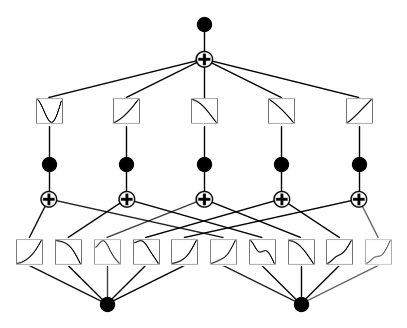

In [122]:
from kan.utils import create_dataset
# create dataset f(x,y) = exp(sin(pi*x)+y^2)
f = lambda x: torch.exp(torch.sin(torch.pi*x[:,[0]]) + x[:,[1]]**2)
dataset = create_dataset(f, n_var=2, device=device)
dataset['train_input'].shape, dataset['train_label'].shape

# plot KAN at initialization
model(dataset['train_input']);
model.plot()

In [123]:
# Convert selected features into PyTorch tensors (Ensure float64)
X_train_tensor_kan = torch.tensor(X_train_fs, dtype=torch.float64)
y_train_tensor_kan = torch.tensor(y_train_resampled, dtype=torch.float64).view(-1, 1)

X_test_tensor_kan = torch.tensor(X_test_fs, dtype=torch.float64)
y_test_tensor_kan = torch.tensor(y_test_enc, dtype=torch.float64).view(-1, 1)
# Check tensor shapes'
print("Train Tensor Shape:", X_train_tensor_kan.shape, y_train_tensor_kan.shape)
print("Test Tensor Shape:", X_test_tensor_kan.shape, y_test_tensor_kan.shape)


Train Tensor Shape: torch.Size([24152, 25]) torch.Size([24152, 1])
Test Tensor Shape: torch.Size([3060, 25]) torch.Size([3060, 1])


In [124]:
# Set device (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Define the KAN model
kan_model = KAN(
    width=[X_train_tensor_kan.shape[1], 5, 1],  # Input → 5 hidden neurons → Output
    grid=5,  # Grid intervals
    k=3,     # Spline order
    seed=42,
    device=device
)

# Move model to the correct device
kan_model.to(device)

# Print model summary
print(kan_model)


Using device: cpu
checkpoint directory created: ./model
saving model version 0.0
MultKAN(
  (act_fun): ModuleList(
    (0-1): 2 x KANLayer(
      (base_fun): SiLU()
    )
  )
  (base_fun): SiLU()
  (symbolic_fun): ModuleList(
    (0-1): 2 x Symbolic_KANLayer()
  )
)


In [128]:
import torch.optim as optim

# Define Loss function and optimizer
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(kan_model.parameters(), lr=1e-4)  # your final learning rate

#define scheduler after the final optimizer
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)  

# Add LR scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)  
from sklearn.metrics import roc_curve, auc
# Move tensors to the correct device
X_train_tensor_kan, y_train_tensor_kan = X_train_tensor_kan.to(device), y_train_tensor_kan.to(device)
X_test_tensor_kan, y_test_tensor_kan = X_test_tensor_kan.to(device), y_test_tensor_kan.to(device)
criterion = torch.nn.BCEWithLogitsLoss()  # Use BCEWithLogitsLoss to handle raw logits
optimizer = torch.optim.Adam(kan_model.parameters(), lr=0.001)
# Training loop (fixed order)
epochs = 100
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = kan_model(X_train_tensor_kan)
    loss = criterion(outputs, y_train_tensor_kan)
    loss.backward()
    optimizer.step()
    scheduler.step()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

print("Training complete!")



C:\Users\HungPhatPC\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:227: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch [10/100], Loss: 0.6885
Epoch [20/100], Loss: 0.6749
Epoch [30/100], Loss: 0.6616
Epoch [40/100], Loss: 0.6470
Epoch [50/100], Loss: 0.6301
Epoch [60/100], Loss: 0.6103
Epoch [70/100], Loss: 0.5876
Epoch [80/100], Loss: 0.5622
Epoch [90/100], Loss: 0.5345
Epoch [100/100], Loss: 0.5049
Training complete!


In [58]:
# Ensure KAN model is in evaluation mode
kan_model.eval()

# Get predictions using the full feature set
with torch.no_grad():
    y_test_kan = kan_model(X_test_tensor_kan)  # Raw logits
    y_pred_prob_kan = torch.sigmoid(y_test_kan).cpu().numpy()  # Convert to probabilities
    y_pred_label_kan = (y_pred_prob_kan > 0.5).astype(int) # Threshold at 0.5

# Convert tensors to NumPy for evaluation
y_test_enc_np = y_test_tensor_kan.cpu().numpy()  # Ensure test labels are also in NumPy
from sklearn.metrics import classification_report, accuracy_score
# Compute classification report
report = classification_report(y_test_enc_np, (y_pred_label_kan))
print("\n- KAN Model Classification Report ⭐")
print(report)



- KAN Model Classification Report ⭐
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97      3025
         1.0       0.17      0.89      0.28        35

    accuracy                           0.95      3060
   macro avg       0.58      0.92      0.63      3060
weighted avg       0.99      0.95      0.97      3060



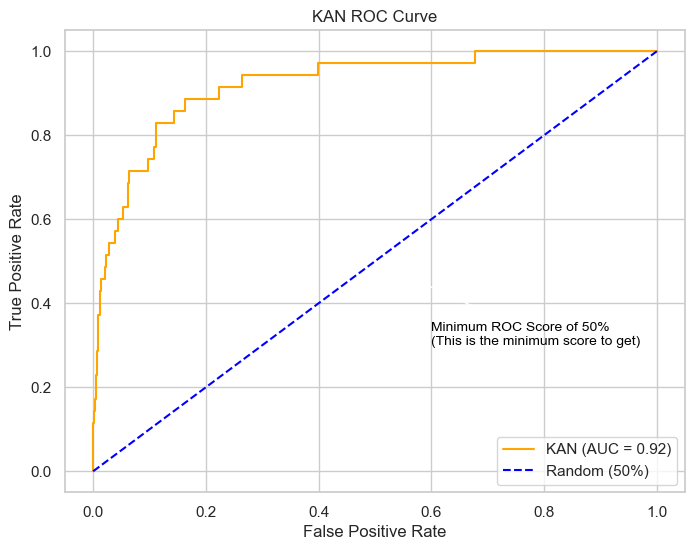

In [129]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure test data is in tensor format
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# Get probability predictions from KAN
with torch.no_grad():
    y_pred_logits_kan = kan_model(X_test_tensor)  # Raw outputs (logits)
    y_pred_prob_kan = torch.sigmoid(y_pred_logits_kan)  # Convert logits to probabilities

# Convert to numpy array for sklearn metrics
y_pred_prob_kan_np = y_pred_prob_kan.cpu().numpy().squeeze()  # Ensure correct shape
y_test_enc_np = y_test_tensor_kan.cpu().numpy().astype(int)
# Compute ROC curve and AUC score for KAN
fpr_kan, tpr_kan, _ = roc_curve(y_test_enc, y_pred_prob_kan_np)  # False Positive Rate, True Positive Rate
roc_auc = auc(fpr_kan, tpr_kan)  # Compute AUC

# Plot ROC Curve
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")

# ROC curve (black line)
plt.plot(fpr_kan, tpr_kan, color='orange', label=f'KAN (AUC = {roc_auc:.2f})')

# Baseline (Random Model) at 50%
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label="Random (50%)")  

# Add annotation
plt.annotate("Minimum ROC Score of 50%\n(This is the minimum score to get)",
             xy=(0.5, 0.5), xytext=(0.6, 0.3),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10, color='black')

# Labels & Title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KAN ROC Curve")
plt.legend(loc="lower right")

# Show the plot
plt.show()


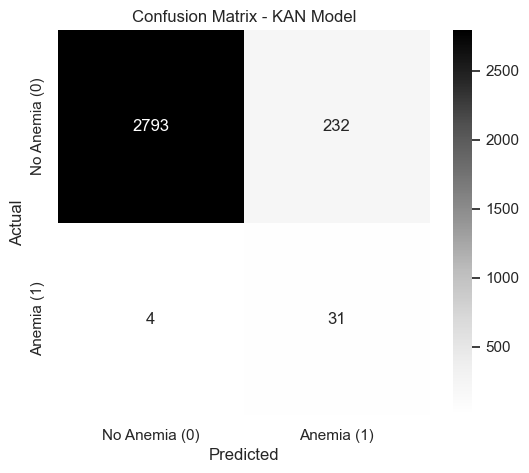


Final Results for KAN Model:
Accuracy: 0.923, AUC: 0.977


In [110]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

kan_model.eval()

# Get predictions from KAN
with torch.no_grad():
    y_pred_logits_kan = kan_model(X_test_tensor)  #Get raw logits
    y_pred_prob_kan = torch.sigmoid(y_pred_logits_kan)  # Convert to probabilities
    y_pred_label_kan = (y_pred_prob_kan > 0.5).float()  # Convert probabilities to binary labels

# Convert tensors to NumPy for evaluation
y_pred_label_kan_np = y_pred_label_kan.cpu().numpy()
y_test_np = y_test_tensor_kan.cpu().numpy()

# Compute confusion matrix
cm_kan = confusion_matrix(y_test_np, y_pred_label_kan_np)
# Compute accuracy & AUC score
acc = accuracy_score(y_test_np, y_pred_label_kan_np)
roc_auc = roc_auc_score(y_test_np, y_pred_prob_kan.cpu().numpy())  # Use probabilities for AUC

#Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_kan, annot=True, fmt='d', cmap='Greys',
            xticklabels=['No Anemia (0)', 'Anemia (1)'],
            yticklabels=['No Anemia (0)', 'Anemia (1)'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KAN Model")
plt.show()
# Display accuracy and AUC
print("\nFinal Results for KAN Model:")
print(f"Accuracy: {acc:.3f}, AUC: {roc_auc:.3f}")


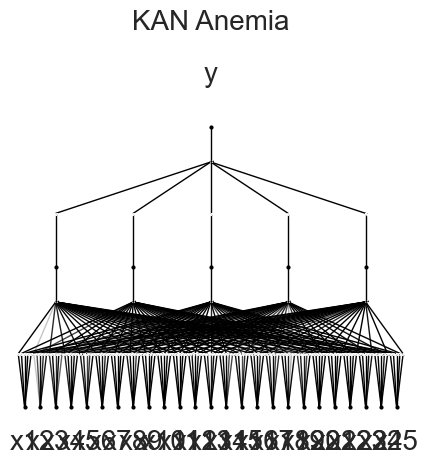

In [116]:
input_dim = kan_model.width_in[0]
kan_model.plot(
    beta=100,
    in_vars=[f'x{i+1}' for i in range(input_dim)],
    out_vars=['y'],
    title="KAN Anemia"
)


In [118]:
import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold

# Define K-Fold Cross Validation
k_folds = 5
kf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Store performance metrics
accuracy_scores = []
auc_scores = []
classification_reports = []


for fold, (train_index, test_index) in enumerate(kf.split(X_train_fs, y_train_resampled)):
    print(f"\n🔹 Fold {fold+1}/{k_folds}")

    # Split data into training and validation for this fold
    X_train_fold, X_test_fold = X_train_fs[train_index], X_train_fs[test_index]
    y_train_fold, y_test_fold = y_train_resampled[train_index], y_train_resampled[test_index]

    # Convert to PyTorch tensors
    X_train_fold_tensor = torch.tensor(X_train_fold, dtype=torch.float64)
    y_train_fold_tensor = torch.tensor(y_train_fold, dtype=torch.float64).view(-1, 1)
    X_test_fold_tensor = torch.tensor(X_test_fold, dtype=torch.float64)
    y_test_fold_tensor = torch.tensor(y_test_fold, dtype=torch.float64).view(-1, 1)
    
    # Move tensors to the correct device (CPU/GPU)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_train_fold_tensor, y_train_fold_tensor = X_train_fold_tensor.to(device), y_train_fold_tensor.to(device)
    X_test_fold_tensor, y_test_fold_tensor = X_test_fold_tensor.to(device), y_test_fold_tensor.to(device)

    # Initialize the KAN model for this fold
    kan_model = KAN(
        width=[X_train_fold_tensor.shape[1], 5, 1],  # Input → Hidden → Output
        grid=5,  # Grid intervals
        k=3,  # Spline order
        seed=42,
        device=device
    ).to(device)

    # Define loss function and optimizer
    criterion = torch.nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(kan_model.parameters(), lr=0.001)

    # Training loop
    epochs = 100
    for epoch in range(epochs):
        kan_model.train()
        optimizer.zero_grad()
        outputs = kan_model(X_train_fold_tensor)
        loss = criterion(outputs, y_train_fold_tensor)
        loss.backward()
        optimizer.step()
        
        # Print loss every 20 epochs
        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

    # Evaluate the model
    kan_model.eval()
    with torch.no_grad():
        y_test_logits_fold = kan_model(X_test_fold_tensor)  # Raw logits
        y_test_prob_fold = torch.sigmoid(y_test_logits_fold).cpu().numpy()  # Convert logits to probabilities
        y_test_pred_label_fold = (y_test_prob_fold > 0.5).astype(int)  # Convert probabilities to binary labels

    # Convert to NumPy for sklearn metrics
    y_test_fold_np = y_test_fold_tensor.cpu().numpy()

    # Compute performance metrics
    acc = accuracy_score(y_test_fold_np, y_test_pred_label_fold)
    auc = roc_auc_score(y_test_fold_np, y_test_prob_fold)

    accuracy_scores.append(acc)
    auc_scores.append(auc)
    classification_reports.append(classification_report(y_test_fold_np, y_test_pred_label_fold, output_dict=True))

    print(f"Fold Accuracy: {acc:.4f}, AUC: {auc:.4f}")
 
# Average performance across folds
avg_accuracy_kan = np.mean(accuracy_scores)
print(f"\nAverage Accuracy across {k_folds} folds: {avg_accuracy_kan:.4f}")


🔹 Fold 1/5
checkpoint directory created: ./model
saving model version 0.0
Epoch [20/100], Loss: 0.6747
Epoch [40/100], Loss: 0.6468
Epoch [60/100], Loss: 0.6101
Epoch [80/100], Loss: 0.5621
Epoch [100/100], Loss: 0.5047
Fold Accuracy: 0.8274, AUC: 0.9203

🔹 Fold 2/5
checkpoint directory created: ./model
saving model version 0.0
Epoch [20/100], Loss: 0.6748
Epoch [40/100], Loss: 0.6468
Epoch [60/100], Loss: 0.6100
Epoch [80/100], Loss: 0.5619
Epoch [100/100], Loss: 0.5045
Fold Accuracy: 0.8334, AUC: 0.9239

🔹 Fold 3/5
checkpoint directory created: ./model
saving model version 0.0
Epoch [20/100], Loss: 0.6752
Epoch [40/100], Loss: 0.6472
Epoch [60/100], Loss: 0.6106
Epoch [80/100], Loss: 0.5625
Epoch [100/100], Loss: 0.5050
Fold Accuracy: 0.8277, AUC: 0.9195

🔹 Fold 4/5
checkpoint directory created: ./model
saving model version 0.0
Epoch [20/100], Loss: 0.6749
Epoch [40/100], Loss: 0.6467
Epoch [60/100], Loss: 0.6098
Epoch [80/100], Loss: 0.5616
Epoch [100/100], Loss: 0.5041
Fold Accura

In [95]:
import torch
import torch.optim as optim
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from scipy.stats import randint, uniform
import optuna

# ---------------- DEFINE KAN MODEL ---------------- #
class KANModel(torch.nn.Module):
    def __init__(self, input_size, hidden_size, grid, k):
        super(KANModel, self).__init__()
        self.fc1 = torch.nn.Linear(input_size, hidden_size, dtype=torch.double)
        self.fc2 = torch.nn.Linear(hidden_size, 1, dtype=torch.double)
        self.sigmoid = torch.nn.Sigmoid()
    
    def forward(self, x):
        x = self.fc1(x)
        x = torch.relu(x)  # Activation function
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# Convert dataset to PyTorch tensors
X_train_tensor = torch.tensor(X_train_fs, dtype=torch.float64)
y_train_tensor = torch.tensor(y_train_resampled, dtype=torch.float64).view(-1, 1)
X_test_tensor = torch.tensor(X_test_fs, dtype=torch.float64)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.float64).view(-1, 1)

input_size = X_train_fs.shape[1]  # Number of features

# ---------------- GRID SEARCH ---------------- #
grid_params = {
    'hidden_size': [4, 8, 16, 32],
    'grid': [3, 5, 7],
    'k': [2, 3, 4],
    'learning_rate': [0.001, 0.01, 0.1]
}

best_acc = 0
best_grid_model = None
best_grid_params = {}

best_acc = 0
best_auc = 0
best_grid_model = None
best_grid_params = {}

for hidden_size in grid_params['hidden_size']:
    for grid in grid_params['grid']:
        for k in grid_params['k']:
            for lr in grid_params['learning_rate']:
                model = KANModel(input_size, hidden_size, grid, k)
                criterion = torch.nn.BCELoss()
                optimizer = optim.Adam(model.parameters(), lr=lr)

                # Train model
                for epoch in range(50):
                    optimizer.zero_grad()
                    outputs = model(X_train_tensor)
                    loss = criterion(outputs, y_train_tensor)
                    loss.backward()
                    optimizer.step()

                # Evaluate
                with torch.no_grad():
                    y_pred = model(X_test_tensor)
                    y_label = (y_pred > 0.5).float()
                    y_true = y_test_tensor.numpy()
                    y_proba = y_pred.numpy()

                    acc = accuracy_score(y_true, y_label.numpy())
                    auc = roc_auc_score(y_true, y_proba)

                if auc > best_auc:  # 🔥 AUC-based selection
                    best_acc = acc
                    best_auc = auc
                    best_grid_model = model
                    best_grid_params = {
                        'hidden_size': hidden_size,
                        'grid': grid,
                        'k': k,
                        'learning_rate': lr
                    }

print("\n🔹 Grid Search Best Hyperparameters (KAN):", best_grid_params)
print("🔹 Grid Search Best Accuracy:", best_acc)
print("🔹 Grid Search Best AUC:", best_auc)


# ---------------- RANDOMIZED SEARCH ---------------- #
random_params = {
    'hidden_size': randint(4, 32),
    'grid': randint(3, 7),
    'k': randint(2, 5),
    'learning_rate': uniform(0.0001, 0.1)
}

best_random_acc = 0
best_random_auc = 0
best_random_model = None
best_random_params = {}

for _ in range(20):  # 20 random trials
    hidden_size = random_params['hidden_size'].rvs()
    grid = random_params['grid'].rvs()
    k = random_params['k'].rvs()
    lr = random_params['learning_rate'].rvs()

    model = KANModel(input_size, hidden_size, grid, k)
    criterion = torch.nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train model
    for epoch in range(50):
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

    # Evaluate
    with torch.no_grad():
        y_pred = model(X_test_tensor)
        y_label = (y_pred > 0.5).float()
        y_true = y_test_tensor.numpy()
        y_proba = y_pred.numpy()

        acc = accuracy_score(y_true, y_label.numpy())
        auc = roc_auc_score(y_true, y_proba)

    if auc > best_random_auc:  # AUC is the main metric
        best_random_acc = acc
        best_random_auc = auc
        best_random_model = model
        best_random_params = {
            'hidden_size': hidden_size,
            'grid': grid,
            'k': k,
            'learning_rate': lr
        }

print("\n🔹 Random Search Best Hyperparameters (KAN):", best_random_params)
print("🔹 Random Search Best Accuracy:", best_random_acc)
print("🔹 Random Search Best AUC:", best_random_auc)

# ---------------- OPTUNA BAYESIAN OPTIMIZATION ---------------- #
def objective_kan(trial):
    hidden_size = trial.suggest_int('hidden_size', 4, 32)
    grid = trial.suggest_int('grid', 3, 7)
    k = trial.suggest_int('k', 2, 4)
    lr = trial.suggest_float('learning_rate', 0.0001, 0.1, log=True)

    model = KANModel(input_size, hidden_size, grid, k)
    criterion = torch.nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Train model
    for epoch in range(50):
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()

    # Evaluate
    with torch.no_grad():
        y_test_pred = model(X_test_tensor)
        y_test_pred_label = (y_test_pred > 0.5).float()
    acc = accuracy_score(y_test_tensor.numpy(), y_test_pred_label.numpy())
    auc = roc_auc_score(y_true_np, y_test_pred_np)

    return acc

study_kan = optuna.create_study(direction='maximize')
study_kan.optimize(objective_kan, n_trials=30)

best_bayes_kan_params = study_kan.best_params
best_bayes_kan = KANModel(input_size, best_bayes_kan_params['hidden_size'], best_bayes_kan_params['grid'], best_bayes_kan_params['k'])
best_bayes_kan.eval()

print("\n🔹 Bayesian Optimization Best Hyperparameters (KAN):", best_bayes_kan_params)
print("🔹 Bayesian Optimization Best Accuracy:", study_kan.best_value)
print(f"🔹 Best AUC: {study_kan.best_value:.4f}")


🔹 Grid Search Best Hyperparameters (KAN): {'hidden_size': 4, 'grid': 7, 'k': 4, 'learning_rate': 0.1}
🔹 Grid Search Best Accuracy: 0.9532679738562092
🔹 Grid Search Best AUC: 0.9947201889020071


[I 2025-04-22 15:44:50,688] A new study created in memory with name: no-name-d2528034-c0cb-42be-9def-432823c1f586



🔹 Random Search Best Hyperparameters (KAN): {'hidden_size': 9, 'grid': 3, 'k': 2, 'learning_rate': 0.09736374147160538}
🔹 Random Search Best Accuracy: 0.9669934640522876
🔹 Random Search Best AUC: 0.9917449822904368


[W 2025-04-22 15:44:50,949] Trial 0 failed with parameters: {'hidden_size': 14, 'grid': 6, 'k': 2, 'learning_rate': 0.004919549042218768} because of the following error: NameError("name 'y_true_np' is not defined").
Traceback (most recent call last):
  File "C:\Users\HungPhatPC\anaconda3\Lib\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\HungPhatPC\AppData\Local\Temp\ipykernel_13156\40036968.py", line 170, in objective_kan
    auc = roc_auc_score(y_true_np, y_test_pred_np)
                        ^^^^^^^^^
NameError: name 'y_true_np' is not defined. Did you mean: 'y_true'?
[W 2025-04-22 15:44:50,955] Trial 0 failed with value None.


NameError: name 'y_true_np' is not defined

# Comparision

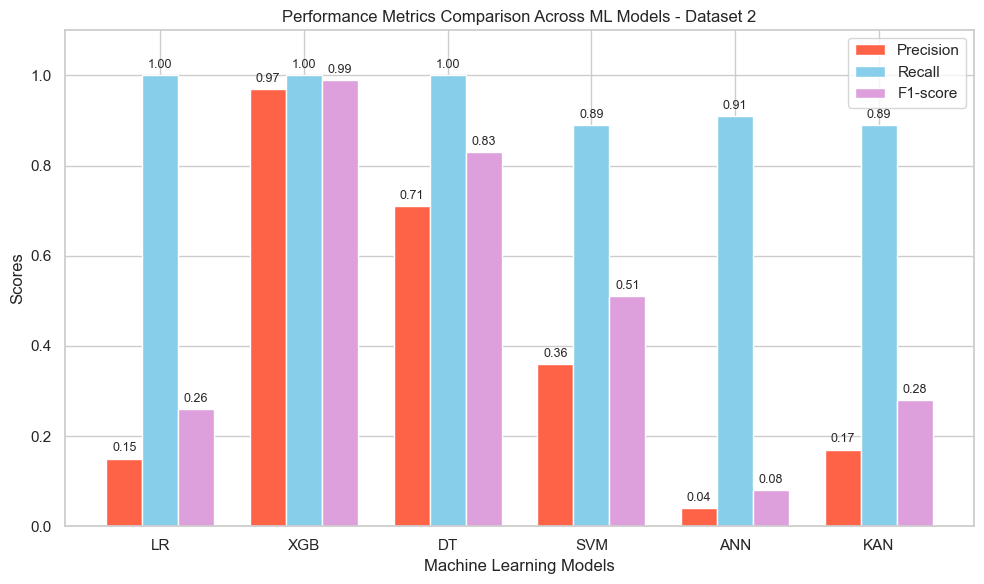

In [81]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
model_names = ['LR', 'XGB', 'DT', 'SVM', 'ANN', 'KAN']

# Corrected weighted average metrics from screenshots
precision = [0.15, 0.97, 0.71, 0.36, 0.04, 0.17]
recall    = [1.00, 1.00, 1.00, 0.89, 0.91, 0.89]
f1_score  = [0.26, 0.99, 0.83, 0.51, 0.08, 0.28]


x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, precision, width, label='Precision', color='tomato')
bars2 = ax.bar(x, recall, width, label='Recall', color='skyblue')
bars3 = ax.bar(x + width, f1_score, width, label='F1-score', color='plum')

ax.set_xlabel('Machine Learning Models')
ax.set_ylabel('Scores')
ax.set_title('Performance Metrics Comparison Across ML Models - Dataset 2')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim([0, 1.1])
ax.legend()

# Add values on top of bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


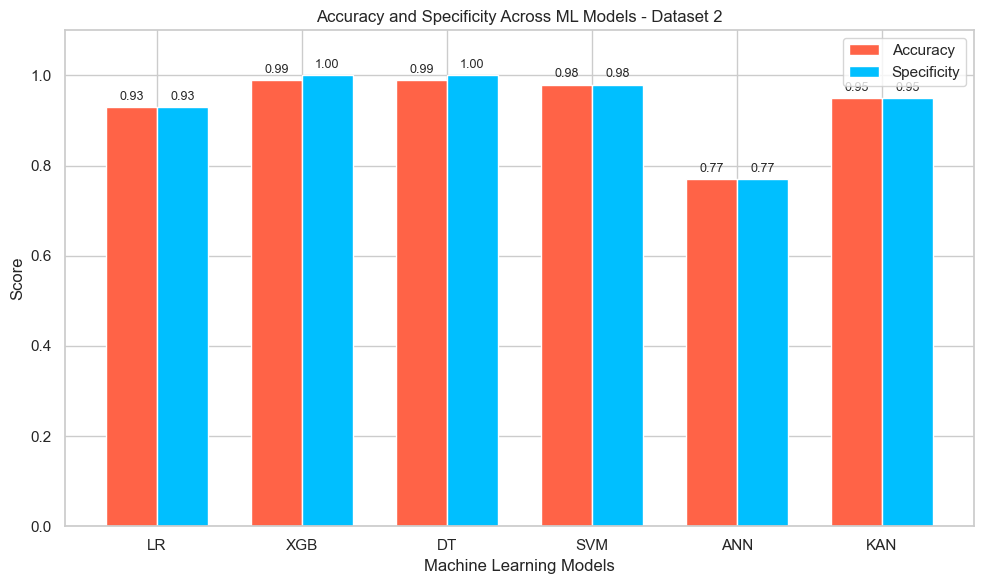

In [85]:
import matplotlib.pyplot as plt
import numpy as np

model_names = ['LR', 'XGB', 'DT', 'SVM', 'ANN', 'KAN']
accuracy =    [0.93, 0.99, 0.99, 0.98, 0.77, 0.95]
specificity = [0.93, 1.00, 1.00, 0.98, 0.77, 0.95]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, accuracy, width, label='Accuracy', color='tomato')
bars2 = ax.bar(x + width/2, specificity, width, label='Specificity', color='deepskyblue')

ax.set_xlabel('Machine Learning Models')
ax.set_ylabel('Score')
ax.set_title('Accuracy and Specificity Across ML Models - Dataset 2')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim([0, 1.1])
ax.legend()

# Annotate bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


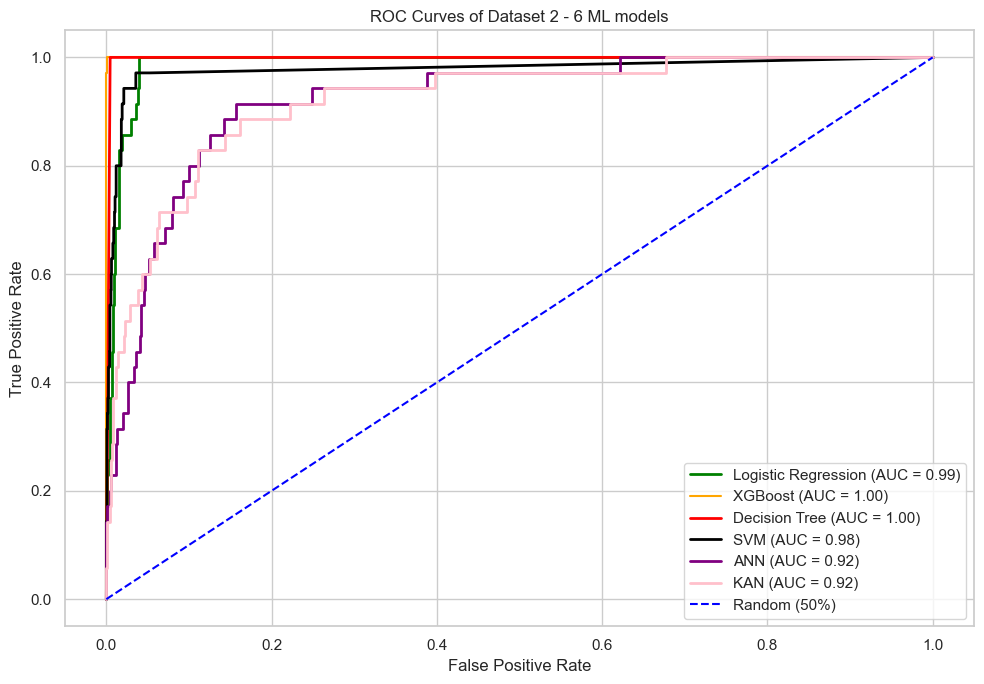

In [134]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import seaborn as sns

# Set style
sns.set(style='whitegrid')

# Compute ROC curve and AUC for LR
fpr_lr, tpr_lr, _ = roc_curve(y_test_enc, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Compute ROC curve and AUC for XGB
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_enc, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Compute ROC curve and AUC for Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test_enc, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Compute ROC curve and AUC for SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test_enc, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

#Comput ROC curve and AUC for ANN
fpr_ann, tpr_ann, _ = roc_curve(y_test_np, y_test_pred_prob_np)
roc_auc_ann = auc(fpr_ann, tpr_ann)

# Compute ROC curve and AUC score for KAN
fpr_kan, tpr_kan, _ = roc_curve(y_test_enc, y_pred_prob_kan_np)  # False Positive Rate, True Positive Rate
roc_auc_kan = auc(fpr_kan, tpr_kan)  # Compute AUC

# 📈 Plot ROC curves
plt.figure(figsize=(10, 7))
#Plot LR
plt.plot(fpr_lr, tpr_lr, color='green', linestyle='-', linewidth=2,
         label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
#Plot XGB
plt.plot(fpr_xgb, tpr_xgb, color='orange', 
         label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
# 🎯 Plot for Decision Tree
plt.plot(fpr_dt, tpr_dt, color='red', linestyle='-', linewidth=2,
         label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')

# 🎯 Plot for SVM
plt.plot(fpr_svm, tpr_svm, color='black', linestyle='-', linewidth=2,
         label=f'SVM (AUC = {roc_auc_svm:.2f})')

#Plot for ANN
plt.plot(fpr_ann, tpr_ann, color='purple', linestyle='-', linewidth=2,
         label=f'ANN (AUC = {roc_auc_ann:.2f})')
#Plot for KAN
plt.plot(fpr_kan, tpr_kan, color = 'pink', linestyle = '-', linewidth = 2,
        label = f'KAN (AUC = {roc_auc_kan:.2f})')
# Add random baseline
plt.plot([0, 1], [0, 1], color='blue', linestyle='--', label='Random (50%)')



# Labels and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves of Dataset 2 - 6 ML models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


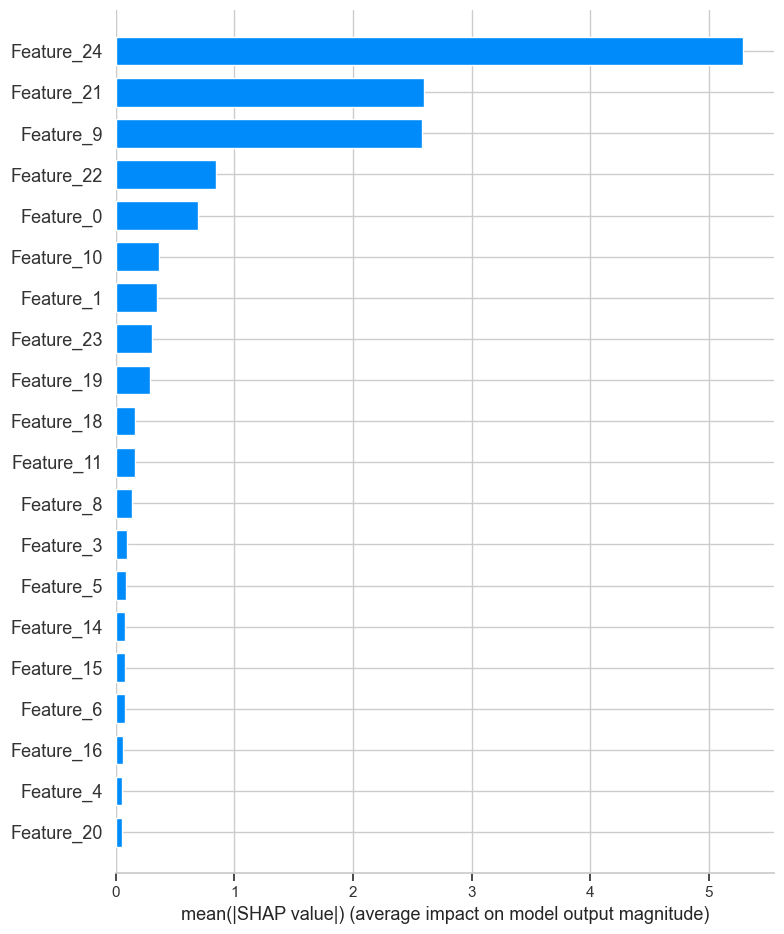

In [130]:
import pandas as pd
import shap

# Convert to DataFrame with correct feature names

X_test_shap = pd.DataFrame(X_test_fs, columns=[f'Feature_{i}' for i in range(X_test_fs.shape[1])])

# Plot SHAP summary
shap.summary_plot(shap_values, X_test_shap, plot_type='bar')



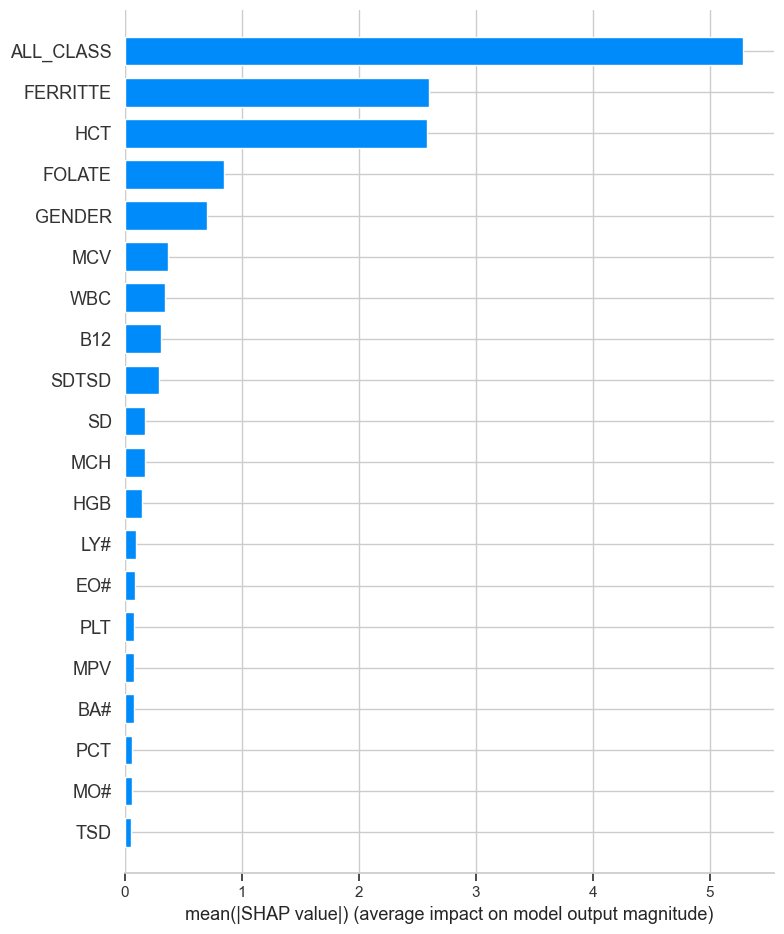

In [144]:
import pandas as pd
import shap

# 🧾 List of all original features (based on your image)
feature_names_all = [
    'GENDER', 'WBC', 'NE#', 'LY#', 'MO#', 'EO#', 'BA#',
    'RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC', 'RDW', 'PLT',
    'MPV', 'PCT', 'PDW', 'SD', 'SDTSD', 'TSD', 'FERRITTE',
    'FOLATE', 'B12', 'HGB_ANEMIA',
    'IRON_ANEMIA_CLASS', 'FOLATE_ANEMIA', 'B12_ANEMIA_CLASS'
]

# 🧠 Now map `X_test_fs` with selected feature names after feature selection
selected_indices = fs.get_support(indices=True)
selected_feature_names = [feature_names_all[i] for i in selected_indices]

# ✅ Build the DataFrame for SHAP
X_test_shap = pd.DataFrame(X_test_fs, columns=selected_feature_names)

# 📊 Create the SHAP bar plot
shap.summary_plot(shap_values, X_test_shap, plot_type='bar')


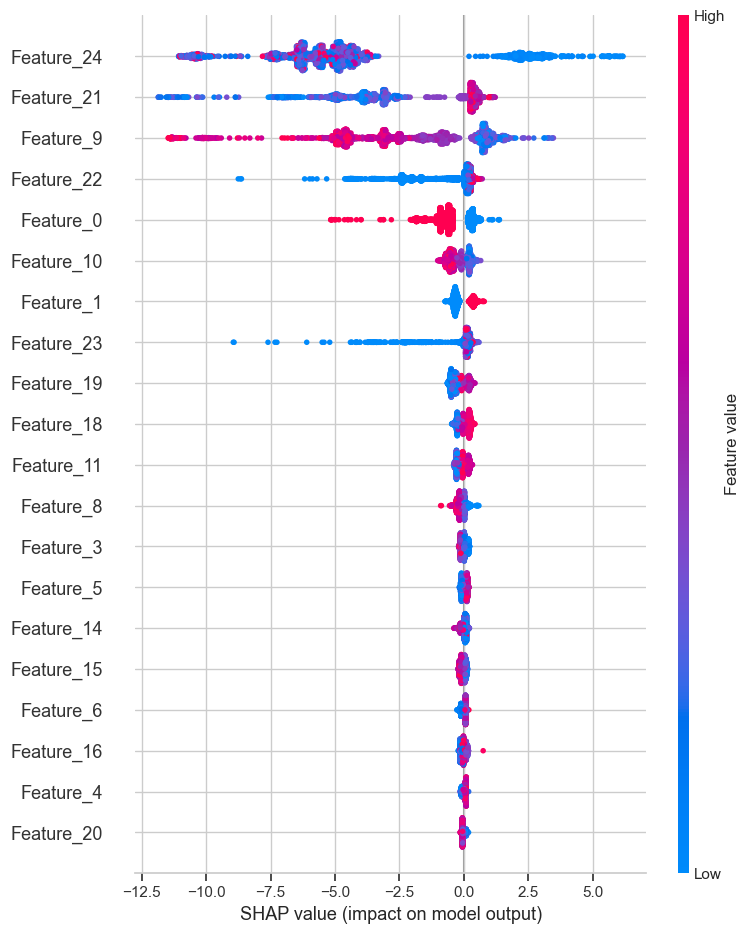

In [138]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

# 🧠 Train your model (e.g., XGBoost classifier)
# clf = XGBClassifier(...).fit(X_train, y_train)

# ✅ SHAP explainer and values
explainer = shap.Explainer(clf)
shap_values = explainer(X_test_fs)  # shap.Explanation object

# 🏷 Rename features for clarity if needed
feature_names = [
    "Status", "Complaints", "Frequency of use", "Seconds of Use",
    "Customer Value", "Subscription Length", "Call Failure",
    "Distinct Called Numbers", "Frequency of SMS", "Charge Amount",
    "Age Group", "Age", "Tariff Plan"
]

# 📊 SHAP dot (beeswarm) summary plot
shap.summary_plot(shap_values.values, X_test_shap, plot_type="dot")
